# PART7_Select_useful_RILs

select useful RILs that have beneficial genotype for starting materials in breeding plan by interpreting genomic prediction model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.patches as mpatches
import seaborn as sns
import pickle
import ast
from numpy import random as rnd
import random
import copy
import itertools
from tqdm import tqdm
from scipy.stats import zscore
sns.set()
%matplotlib inline
%config InlineBackend.figure_formats = {'png', 'retina'}

from sklearn.linear_model import ElasticNet

from modules.make_data_for_prediction import make_data
from modules.tuning import tuning_ElasticNet
from modules.training import train_Enet_for_app
from modules.breeding import make_regional_info, get_top_regions, plot_regional_info_with_target, target_effect_summary

# basic variables
family_list = pd.read_csv("../data/family_list.csv")
family = family_list.family.unique()
phenotype = "../data/phenotype_data/mean_phenotypes.csv"
traits = ["GN_mean", "PN_mean", "Area.size.AS..mm2."]
CV=5
optuna_seed=1024
model = "Enet"

# Build genomic prediction model for 3 economical traits (Grain number, Panicle number, Grain size)
## merge important haplotype block set of 3 economical traits 

In [ ]:
genotype = pd.read_csv("../data/PART1_make_Haplotype_block/Haplotype_all_LD90.csv")

with open('../data/PART5_Build_application_model/Compare_models_by_all_RILs_selected_HBs.pic.bin', 'rb') as p:
    summary = pickle.load(p)
summary = pd.DataFrame(summary)

merge_index = []
for trait_name in ["GN_mean", "PN_mean", "Area.size.AS..mm2."]:
    # select best HB_num and model
    trait_summary = summary[summary.iloc[:, 0] == trait_name]
    trait_summary = trait_summary.iloc[:, [1,2,3,5]]
    trait_summary.columns = ["HB_num", "model", "CV", "r"]
    trait_summary = trait_summary.groupby(["HB_num", "model"]).mean().reset_index()
    HB_num = trait_summary.sort_values(by="r", ascending=False).iloc[0, 0]
    
    with open('../data/PART4_Model_comparison/Compare_models_by_all_RILs_HBs_{}.pic.bin'.format(trait_name), 'rb') as p:
        summary_all_HB = pickle.load(p)
    summary_all_HB = pd.DataFrame(summary_all_HB)
    
    imp = np.mean(summary_all_HB.loc[(summary_all_HB.iloc[:, 0] == trait_name) & (summary_all_HB.iloc[:, 2] == model), 6].values, axis=0)
    merge_index.extend(np.argsort(np.abs(imp))[::-1][:HB_num])

# save merged HBs
genotype.loc[np.sort(np.unique(merge_index)), :].to_csv("../data/PART7_Select_useful_RILs/Haplotype_high_imp_HBs_for_3traits.csv", index=None)

## Parameter tuning for selected HBs

In [ ]:
genotype = "../data/PART7_Select_useful_RILs/Haplotype_high_imp_HBs_for_3traits.csv" 

Enet_params = []
for trait_name in traits:
    # Tuning Enet
    test_data, train_data, position_data = make_data(family, family_list, trait_name, genotype, phenotype, CV, seed=1024, plot=False)
    for i in range(CV):
        train_data_CVn = train_data[i]
        X = train_data_CVn[0]; y = train_data_CVn[1]
        Enet_params.append([trait_name, i, tuning_ElasticNet(X, y)])

pd.DataFrame(Enet_params).to_csv("../data/PART7_Select_useful_RILs/Enet_high_imp_HBs_params.csv")

## Train models

In [7]:
genotype = "../data/PART7_Select_useful_RILs/Haplotype_high_imp_HBs_for_3traits.csv" 
summary = []
for trait_name in traits:
    test_data, train_data, position_data = make_data(family, family_list, trait_name, genotype, phenotype, CV, seed=1024, plot=False, log=False)
    
    for i in range(CV):
        tmp_test_data = test_data[i]
        tmp_train_data = train_data[i]
        
        # get params
        Enet_params = pd.read_csv("../data/PART7_Select_useful_RILs/Enet_high_imp_HBs_params.csv", index_col=0)
        Enet_params.columns = ["trait", "CV", "params"]
        Enet_params = ast.literal_eval(Enet_params.loc[(Enet_params["trait"] == trait_name) & (Enet_params["CV"] == i), "params"].values[0])
        
        # train
        test_pred, r2, acc_RIL, coefs = train_Enet_for_app(tmp_test_data, tmp_train_data, Enet_params)
        summary.append(["Enet", i, trait_name, test_pred, r2, acc_RIL, coefs])

with open('../data/PART7_Select_useful_RILs/Enet_all_traits_high_imp_HBs.pic.bin', 'wb') as p:
    pickle.dump(summary, p)

# Selection of RILs with optimal genotypes

## check HB genotype effects

In [ ]:
# extract training results
with open('../data/PART7_Select_useful_RILs/Enet_all_traits_high_imp_HBs.pic.bin', 'rb') as p:
    summary = pickle.load(p)
summary = pd.DataFrame(summary)

# get genetic effect of each HB for each trait
imp_data = pd.read_csv("../data/PART7_Select_useful_RILs/Haplotype_high_imp_HBs_for_3traits.csv").iloc[:, :3]
imp_data["GN_imps"] = zscore(np.mean(summary[summary.iloc[:, 2] == "GN_mean"].iloc[:, 6].values, axis=0))
imp_data["PN_imps"] = zscore(np.mean(summary[summary.iloc[:, 2] == "PN_mean"].iloc[:, 6].values, axis=0))
imp_data["GS_imps"] = zscore(np.mean(summary[summary.iloc[:, 2] == "Area.size.AS..mm2."].iloc[:, 6].values, axis=0))

# merge genetic effect of GN, PN, GS
imp_data["sum_zscore"] = imp_data.GN_imps + imp_data.PN_imps + imp_data.GS_imps

# add RIL type columns
SNP_types = pd.DataFrame([list(str(i).zfill(len(family))) for i in imp_data.SNP_type])
SNP_types.columns = [i[:i.find("_")] for i in family]
SNP_types.index = imp_data.index.values
imp_data = pd.concat([imp_data, SNP_types], axis=1)

# add start and end info
pos_array = imp_data.pos.str.split("_", expand=True).values
pos = np.array([[int(each_pos[0]), int(each_pos[0])] if each_pos[1] == None else [int(each_pos[0]), int(each_pos[1])] for each_pos in pos_array])
imp_data["start"] = pos[:, 0]
imp_data["end"] = pos[:, 1]
imp_data.to_csv("../data/PART7_Select_useful_RILs/Haplotype_high_imp_HBs_for_3traits_add.csv", index=None)

## check genetic effect on each trait for each donor genotype

N01


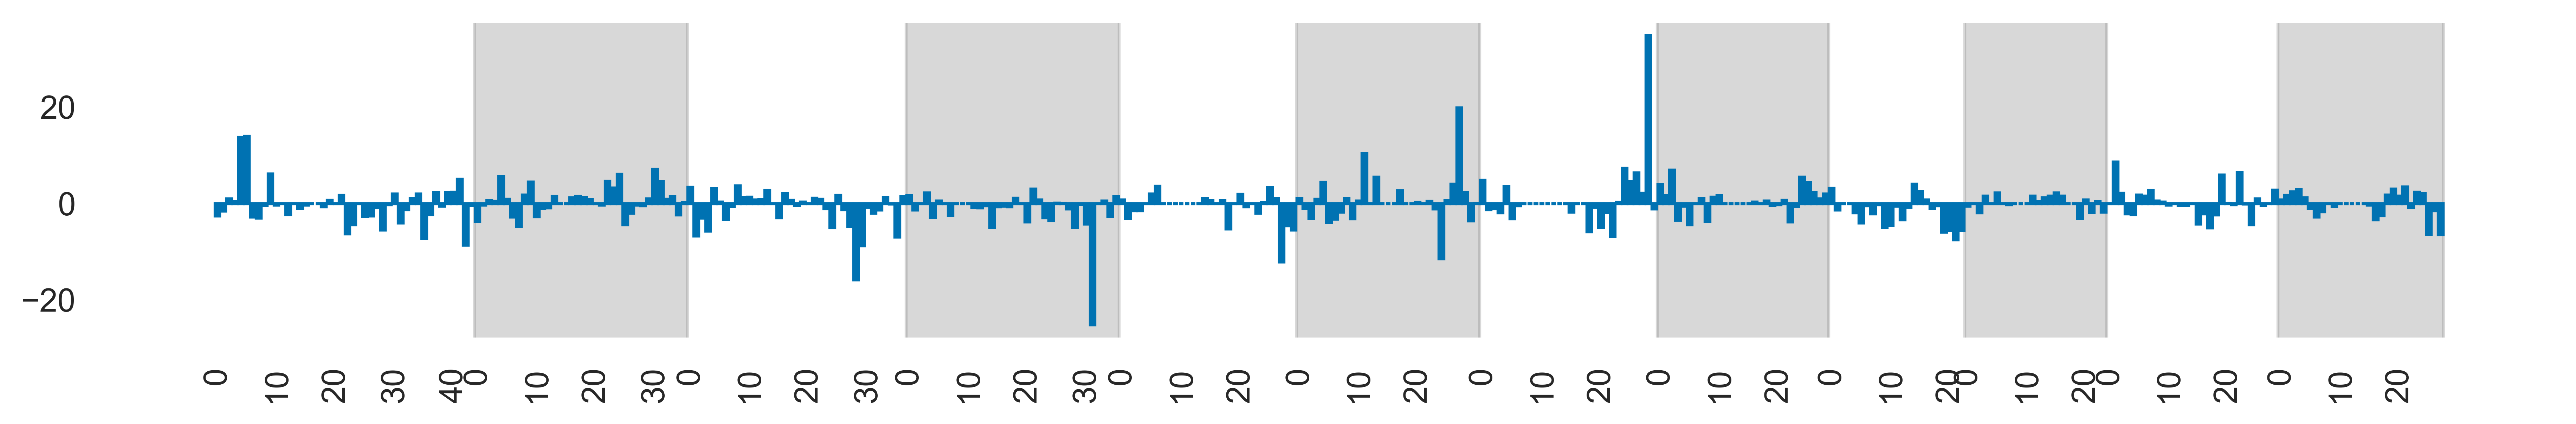

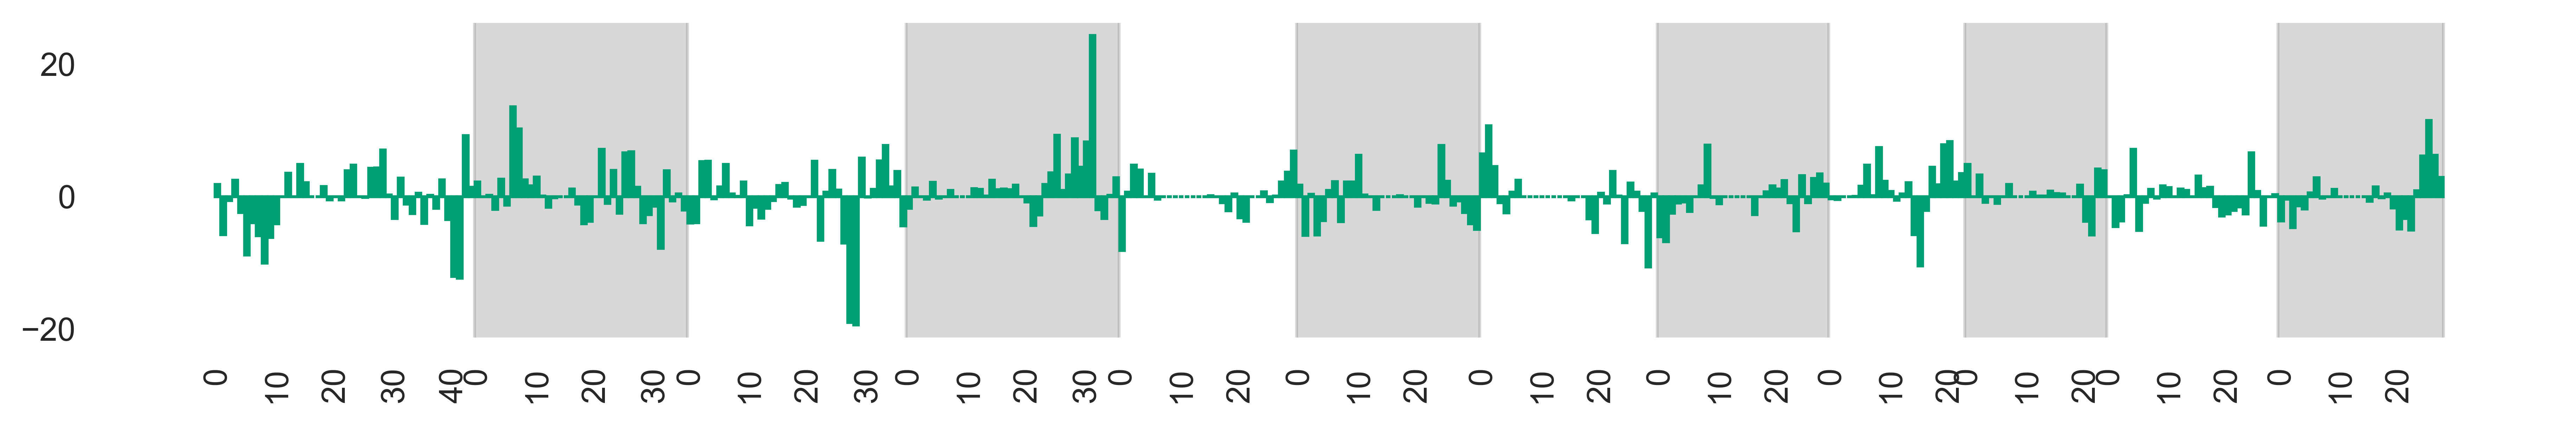

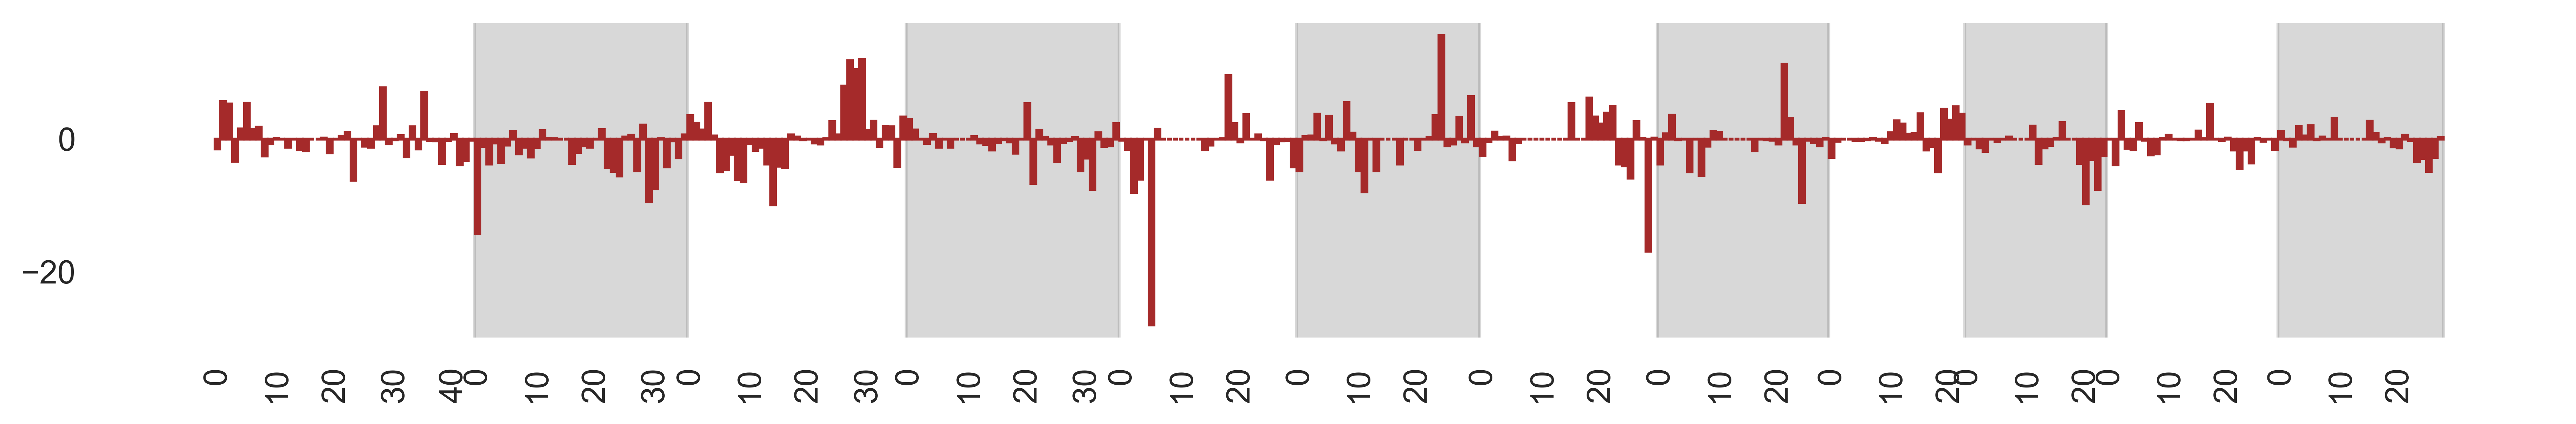

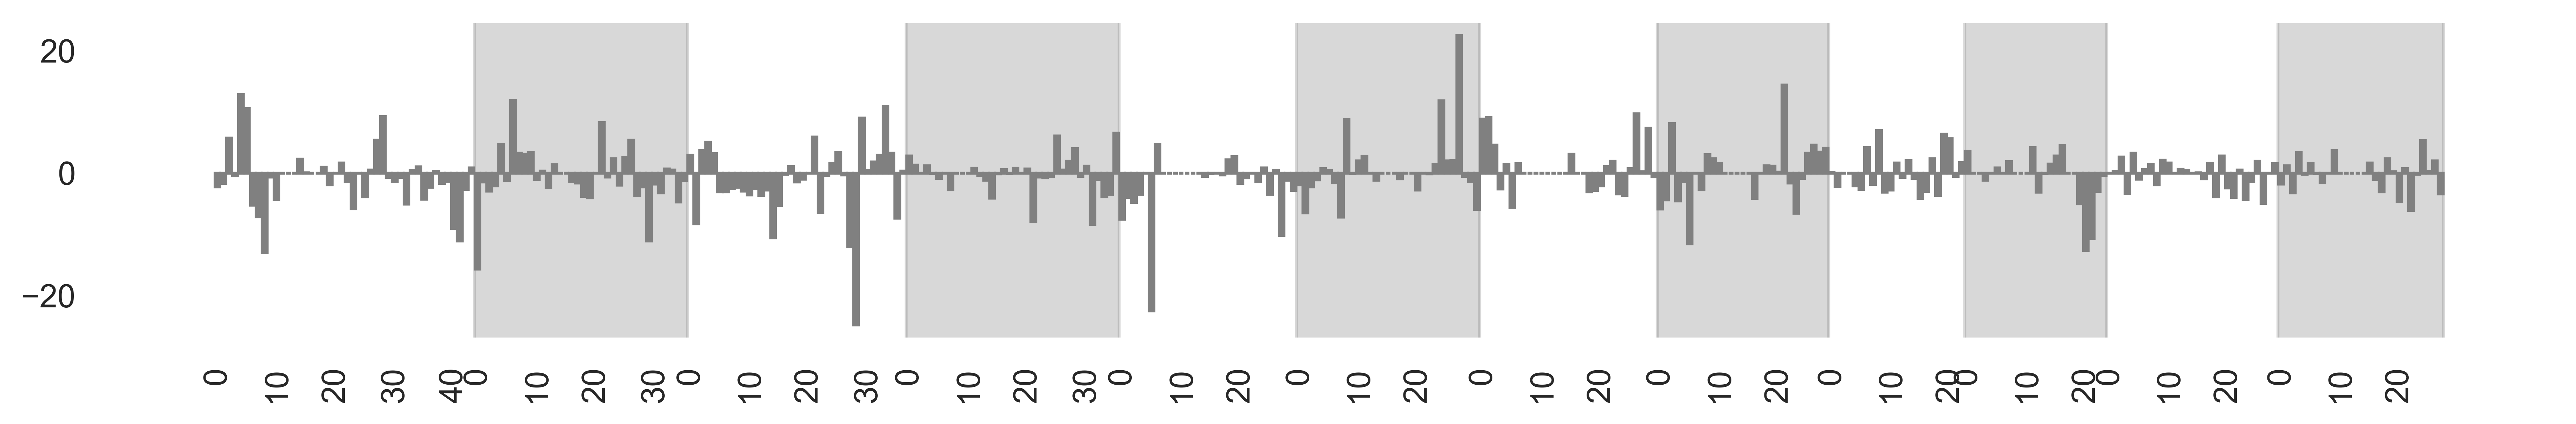

In [3]:
imp_data = pd.read_csv("../data/PART7_Select_useful_RILs/Haplotype_high_imp_HBs_for_3traits_add.csv")
imp_data.iloc[:, 7:27] = imp_data.iloc[:, 7:27].astype(str)

# example: N01
pop = "N01"
print(pop)
regional_info_all = make_regional_info(imp_data, 1000000, "../data/PART7_Select_useful_RILs/Haplotype_high_imp_HBs_for_3traits.csv", pop)
plot_regional_info_with_target(regional_info_all, "GN_imps", "#0072B2", [], [])
plot_regional_info_with_target(regional_info_all, "PN_imps", "#009E73", [], [])
plot_regional_info_with_target(regional_info_all, "GS_imps", "brown", [], [])
plot_regional_info_with_target(regional_info_all, "sum_zscore", "gray", [], [])

## Check genetic effect on GN.
## Extract RILs that have beneficial top 3 genomic regions & high proportion of Hitomebore genotype

N01


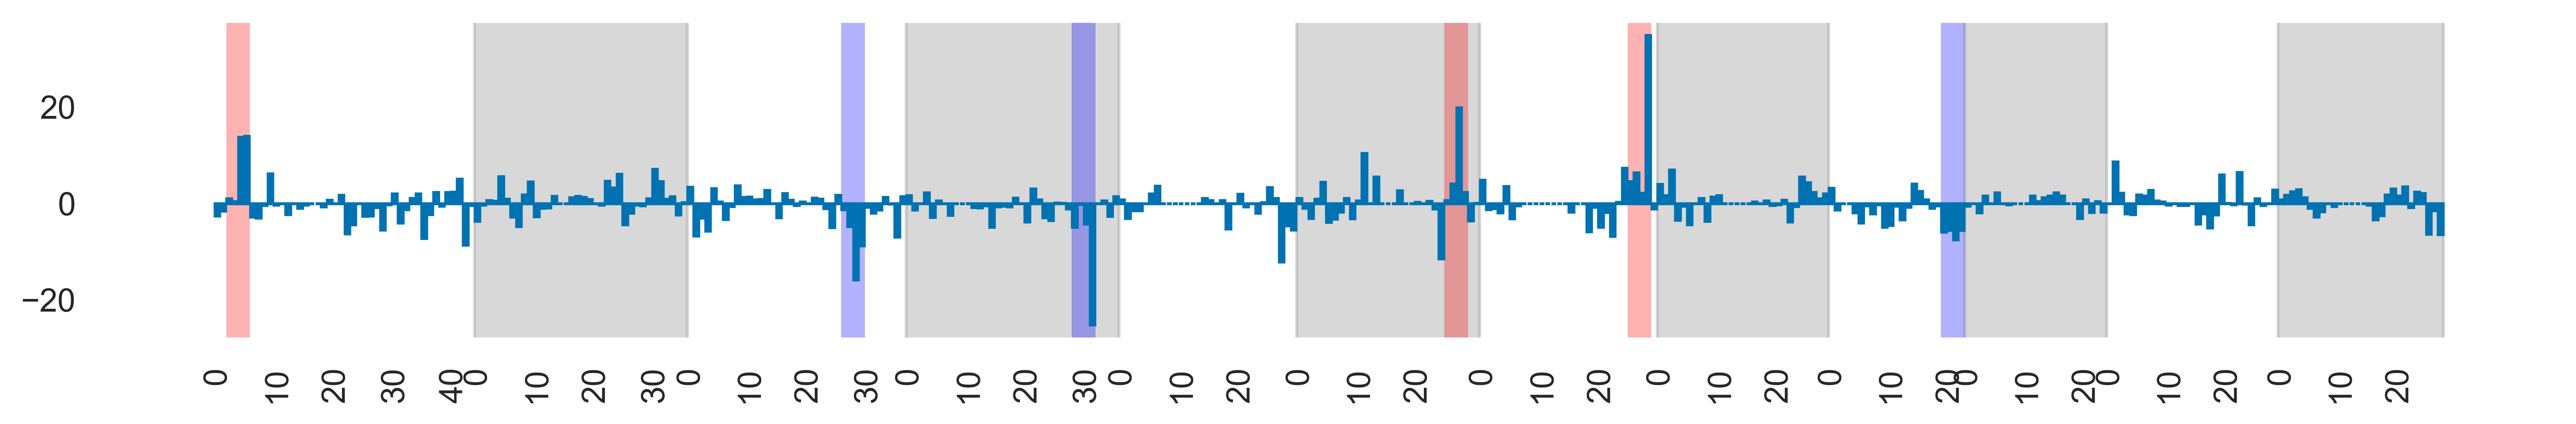

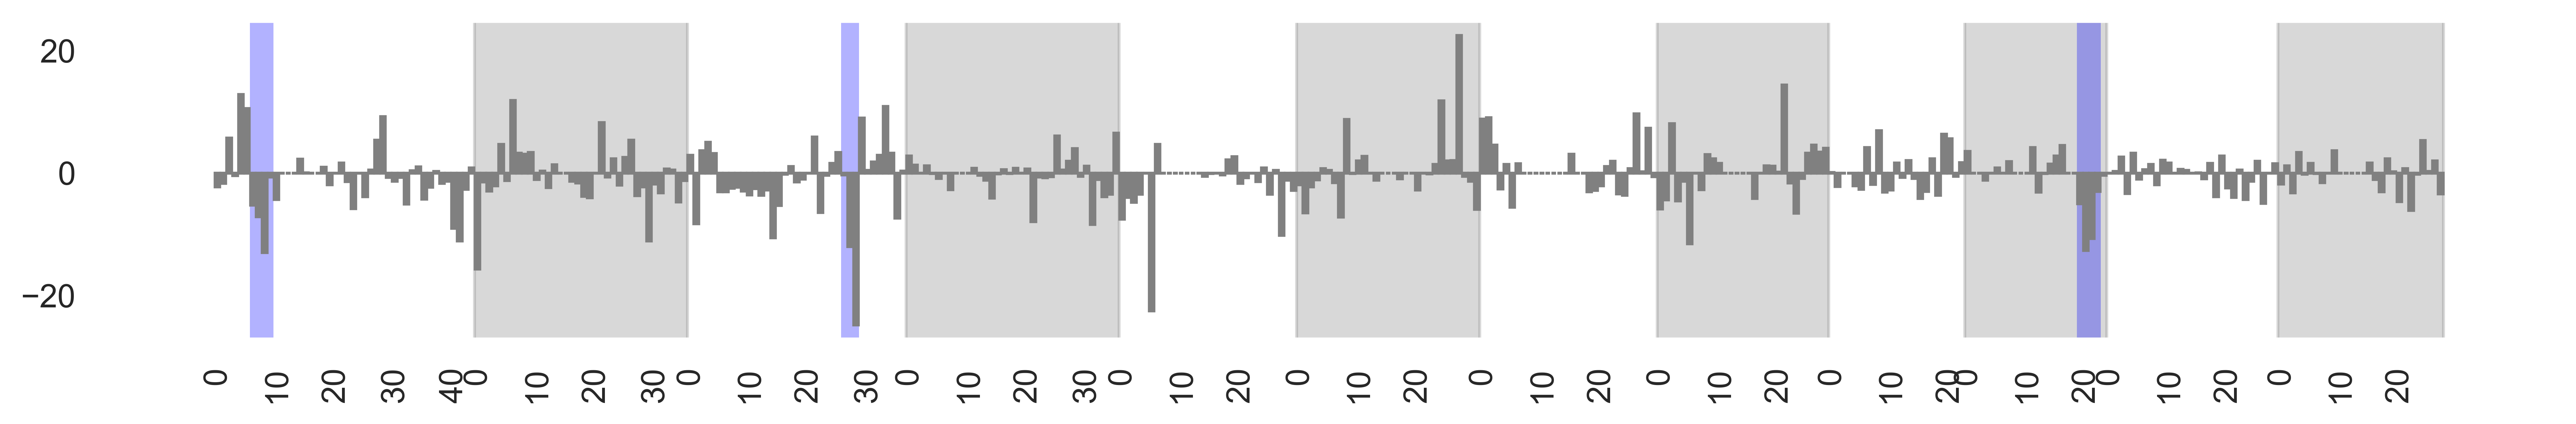

N03


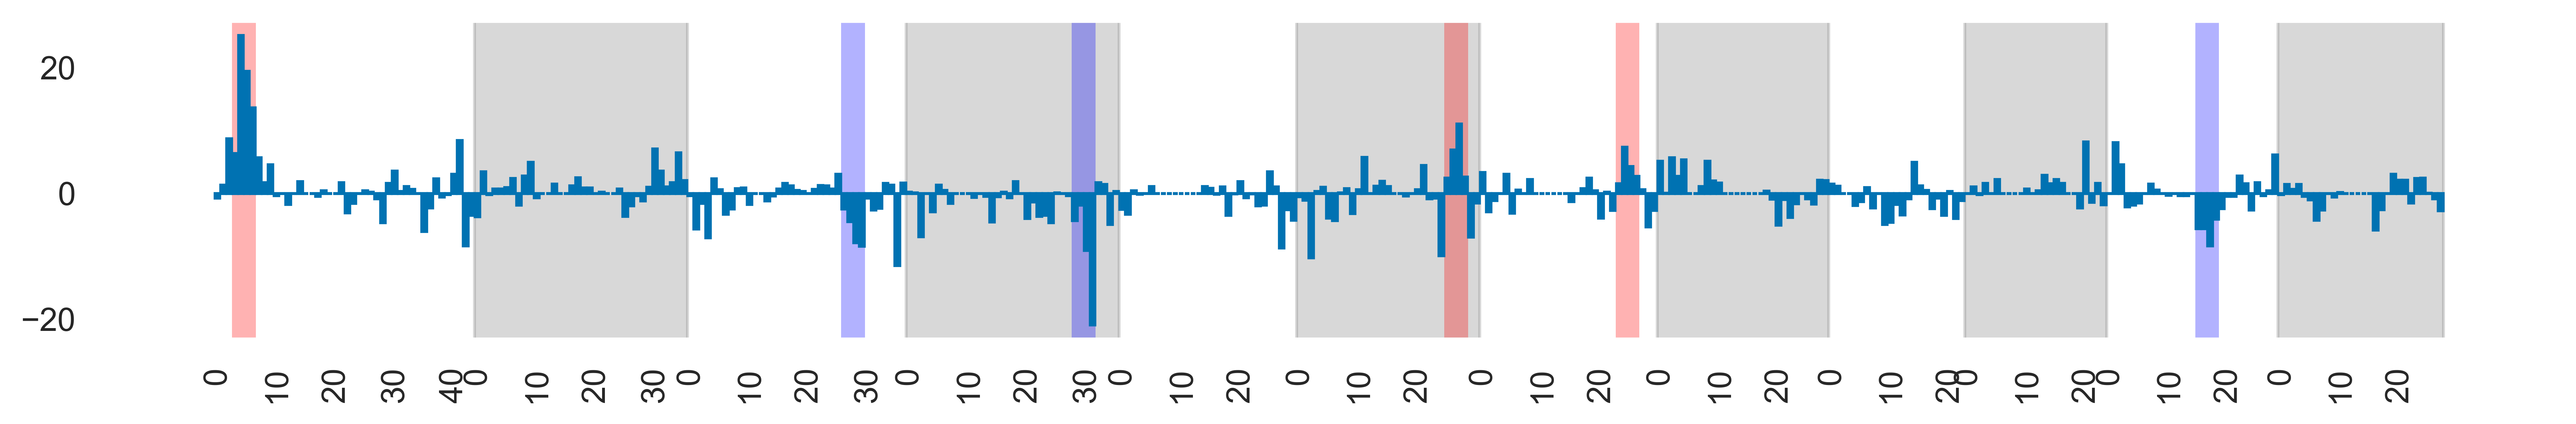

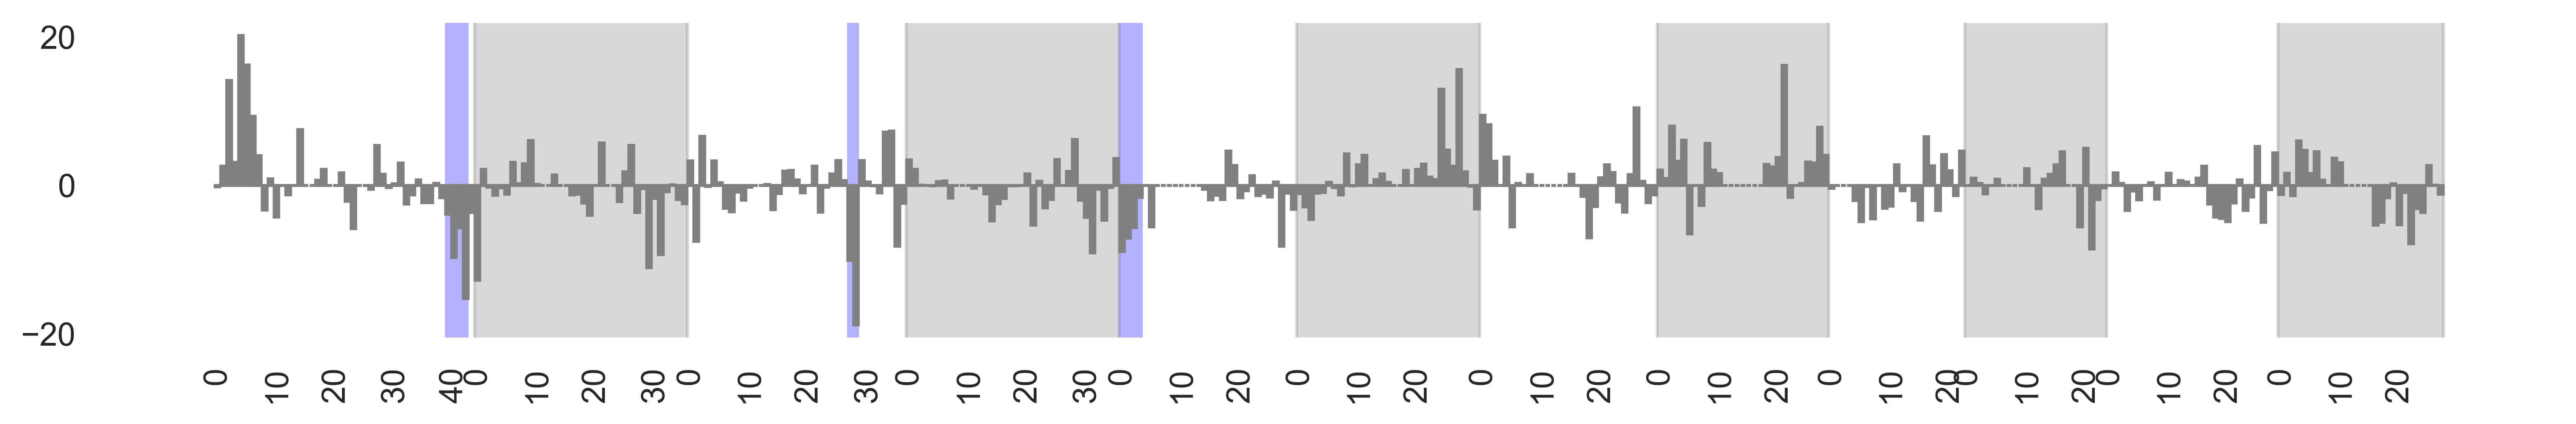

N04


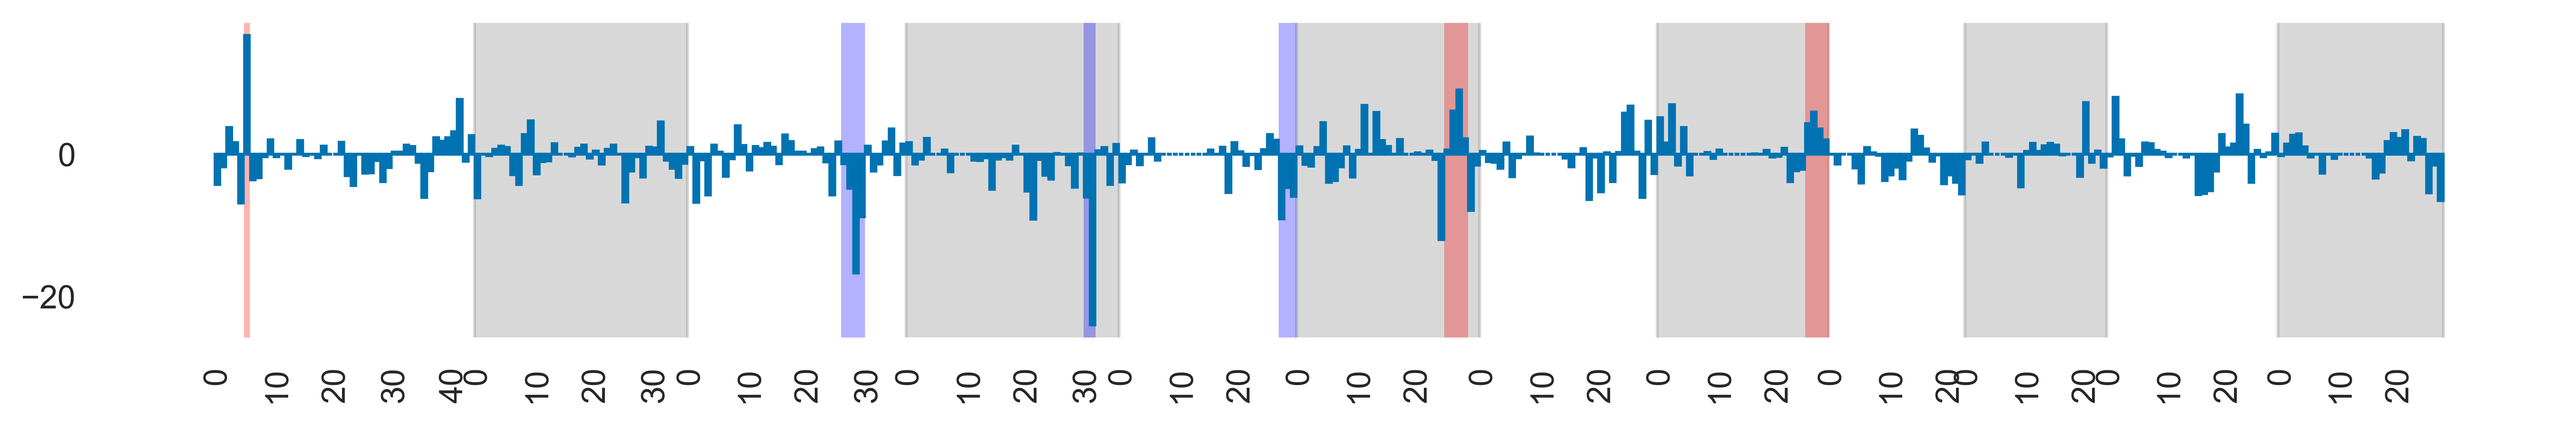

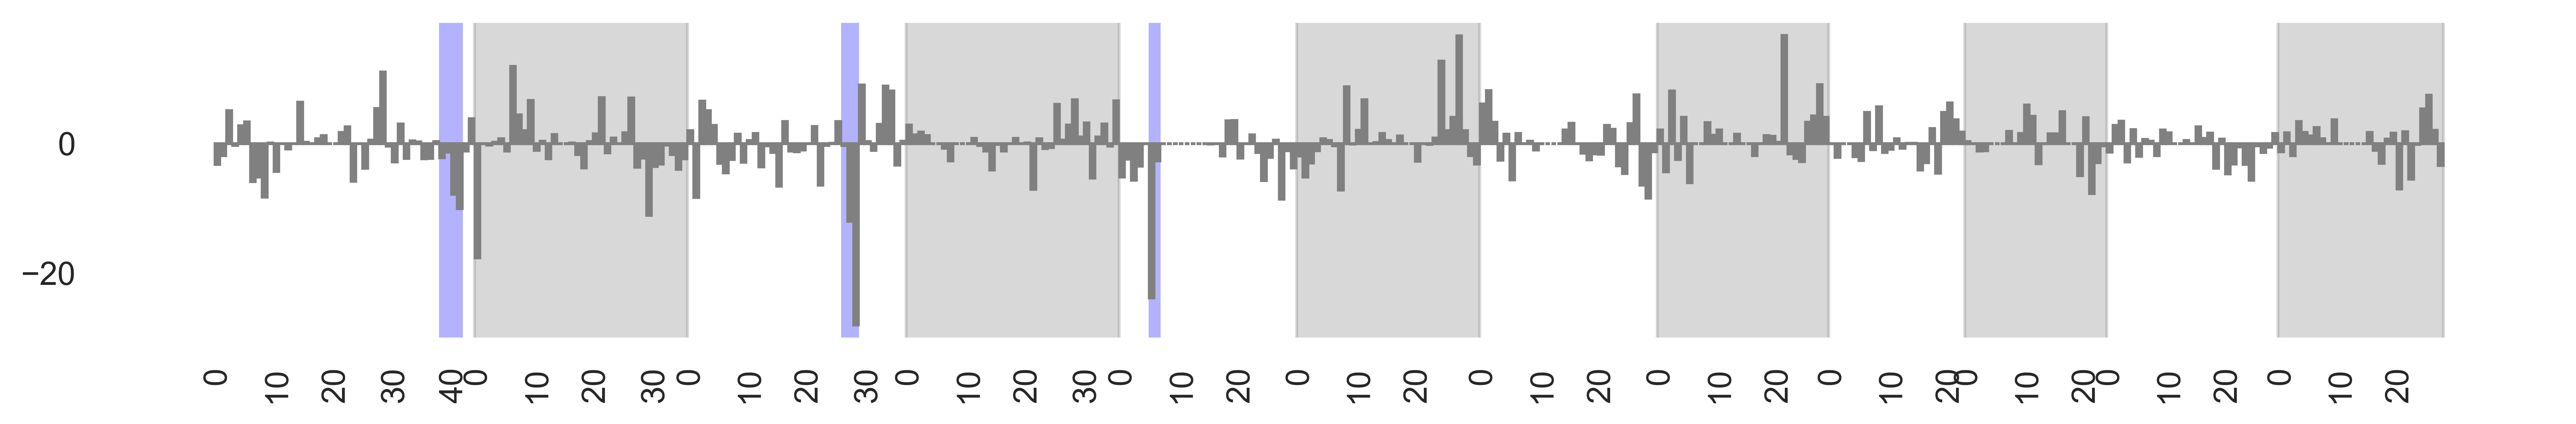

N05


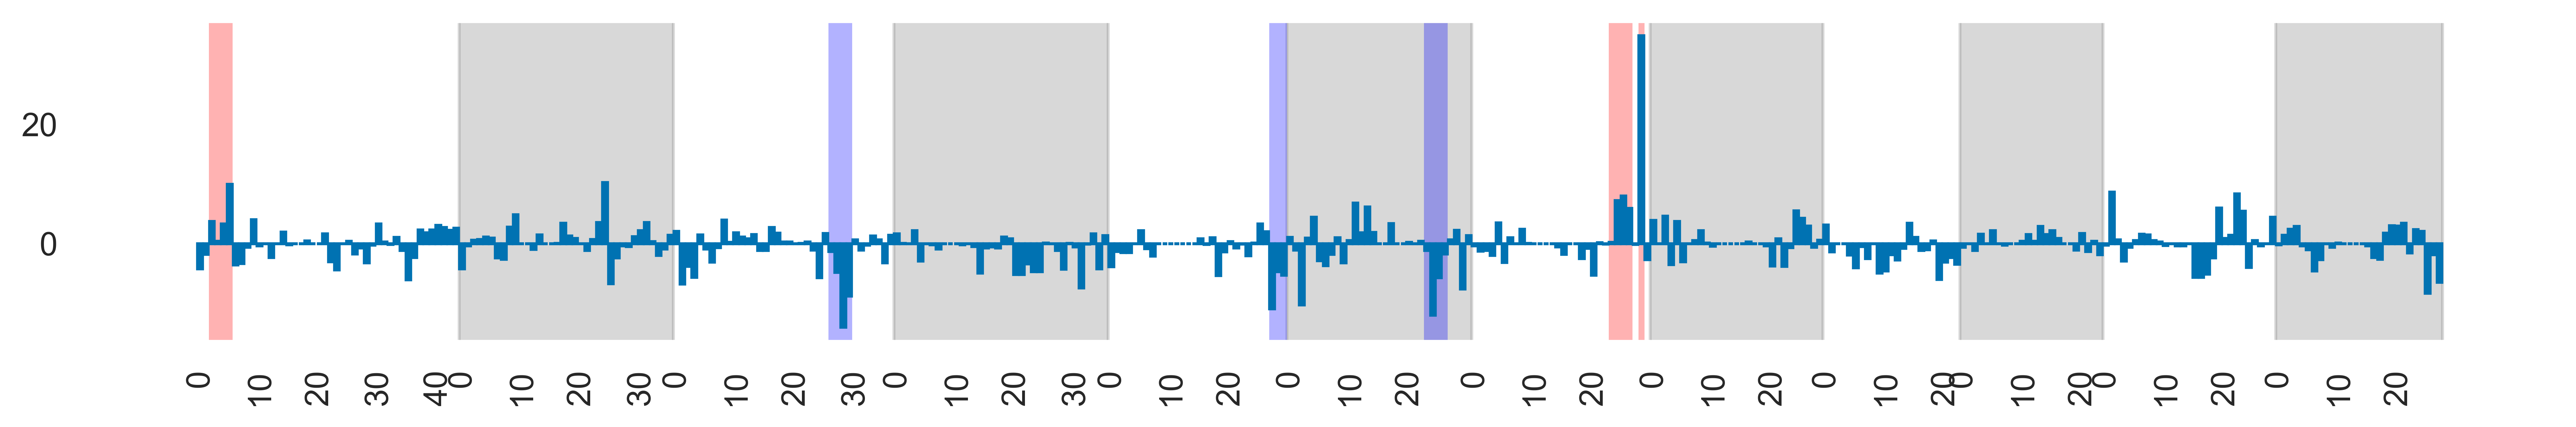

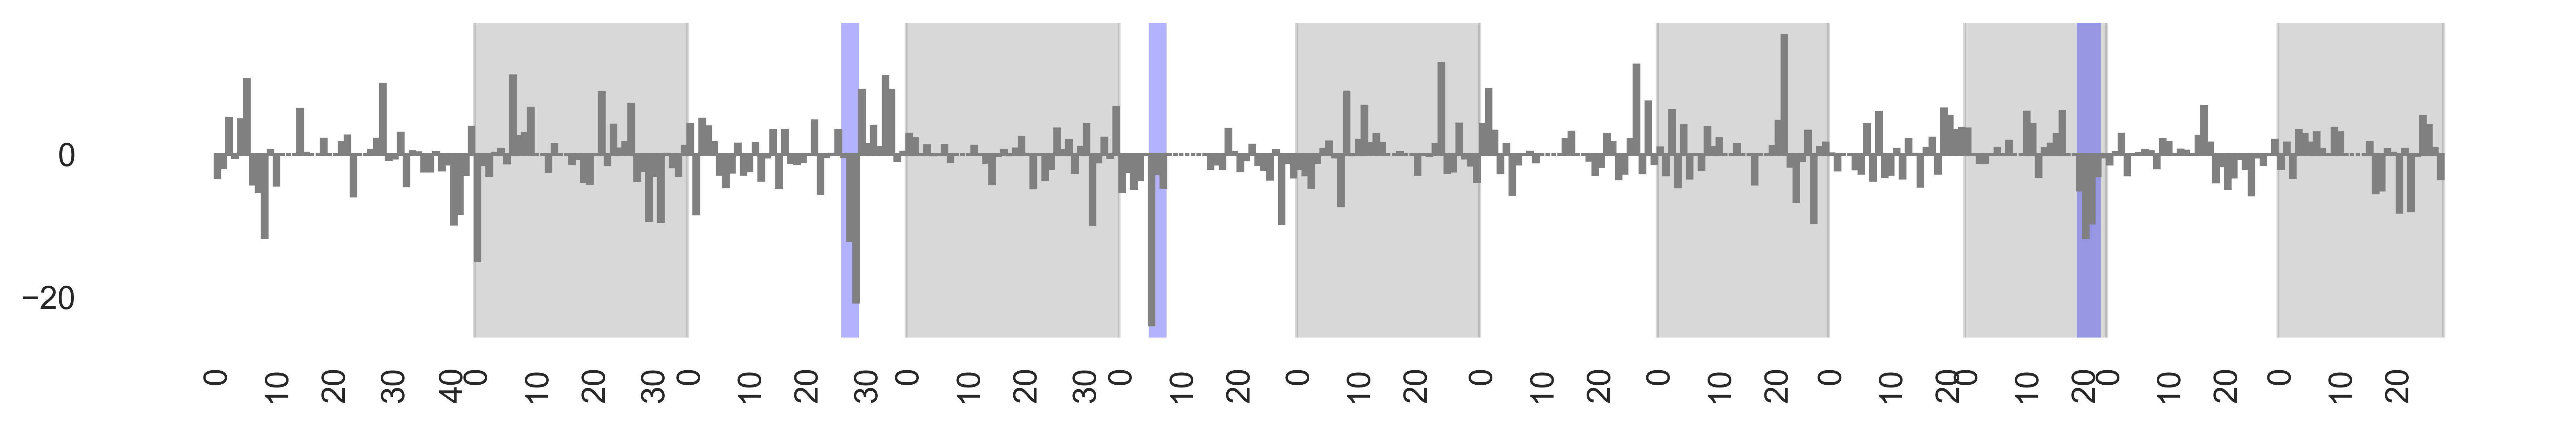

N06


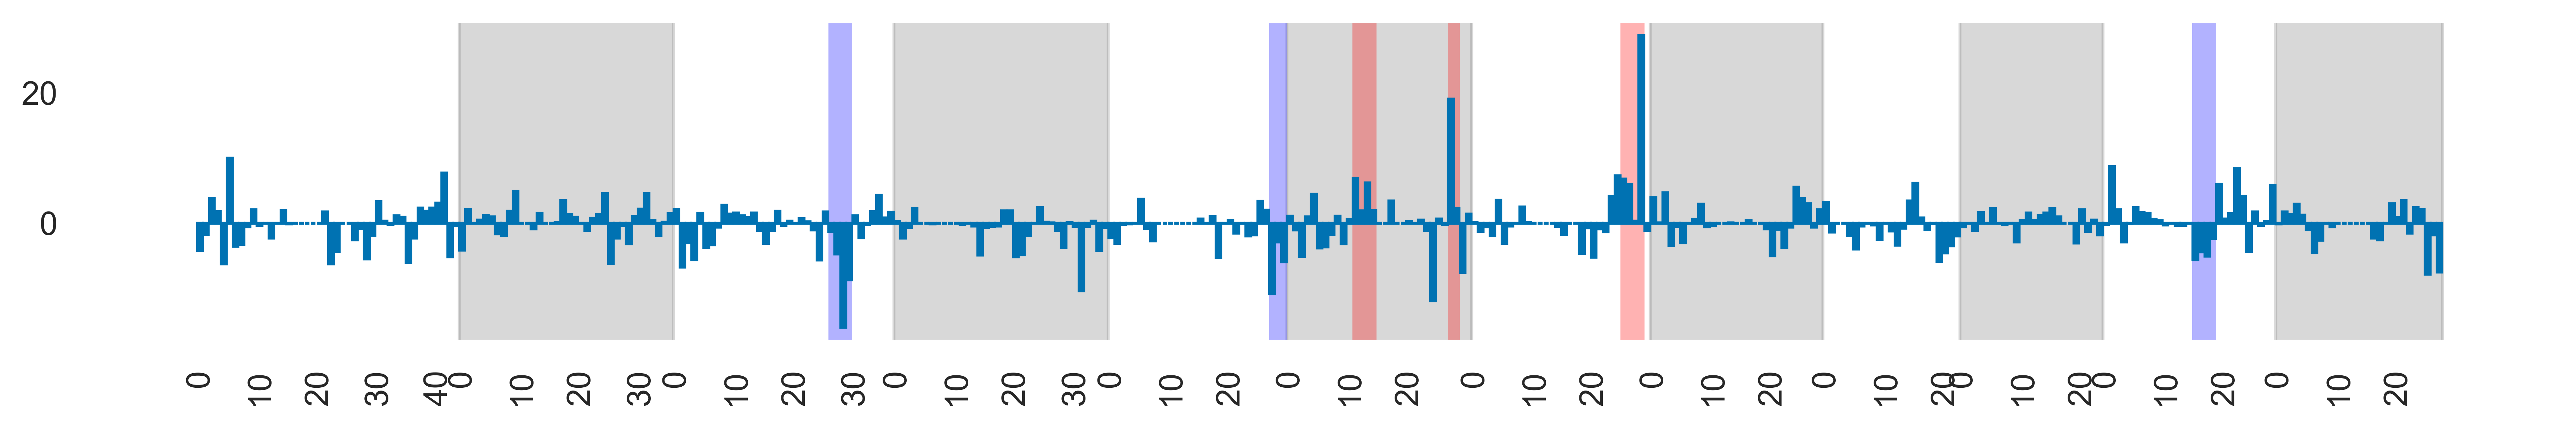

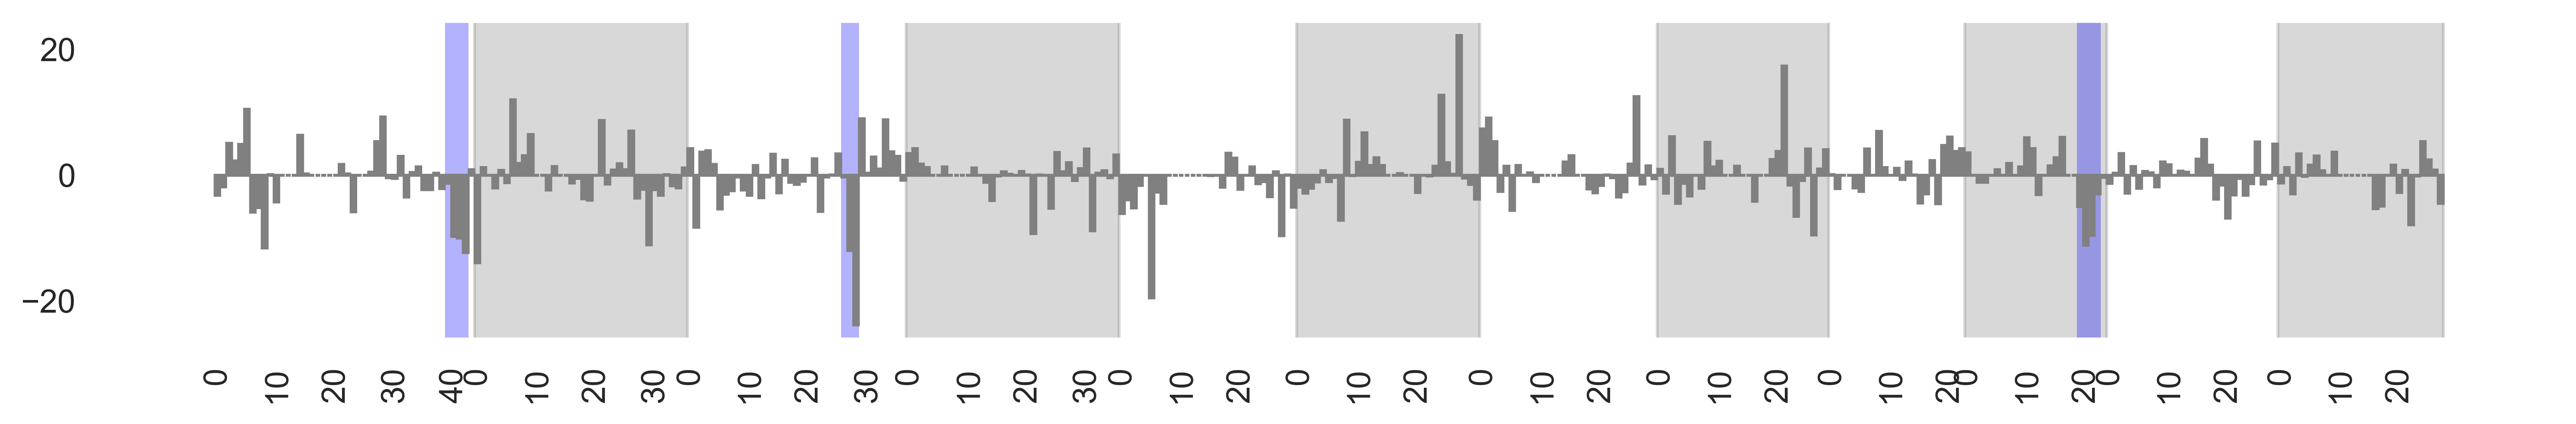

N07


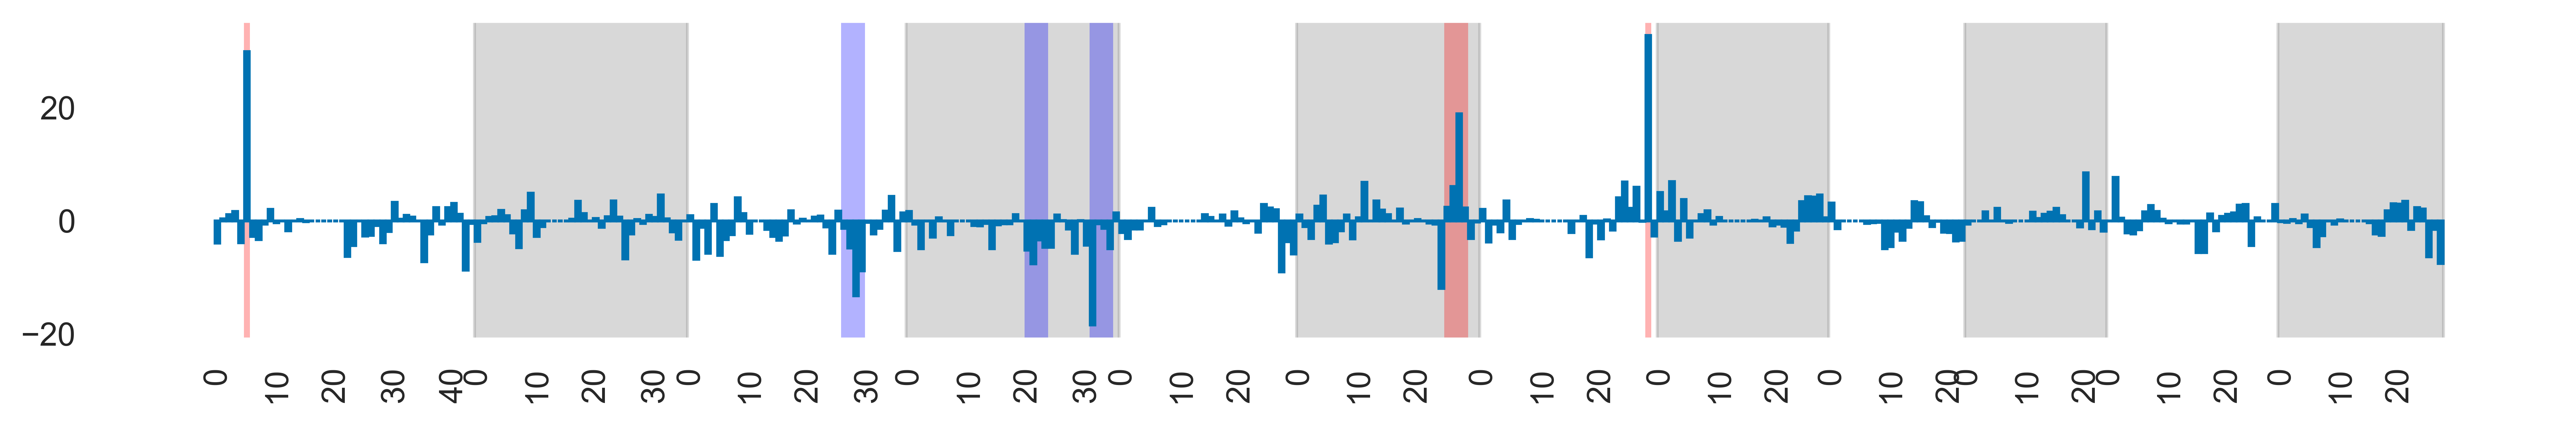

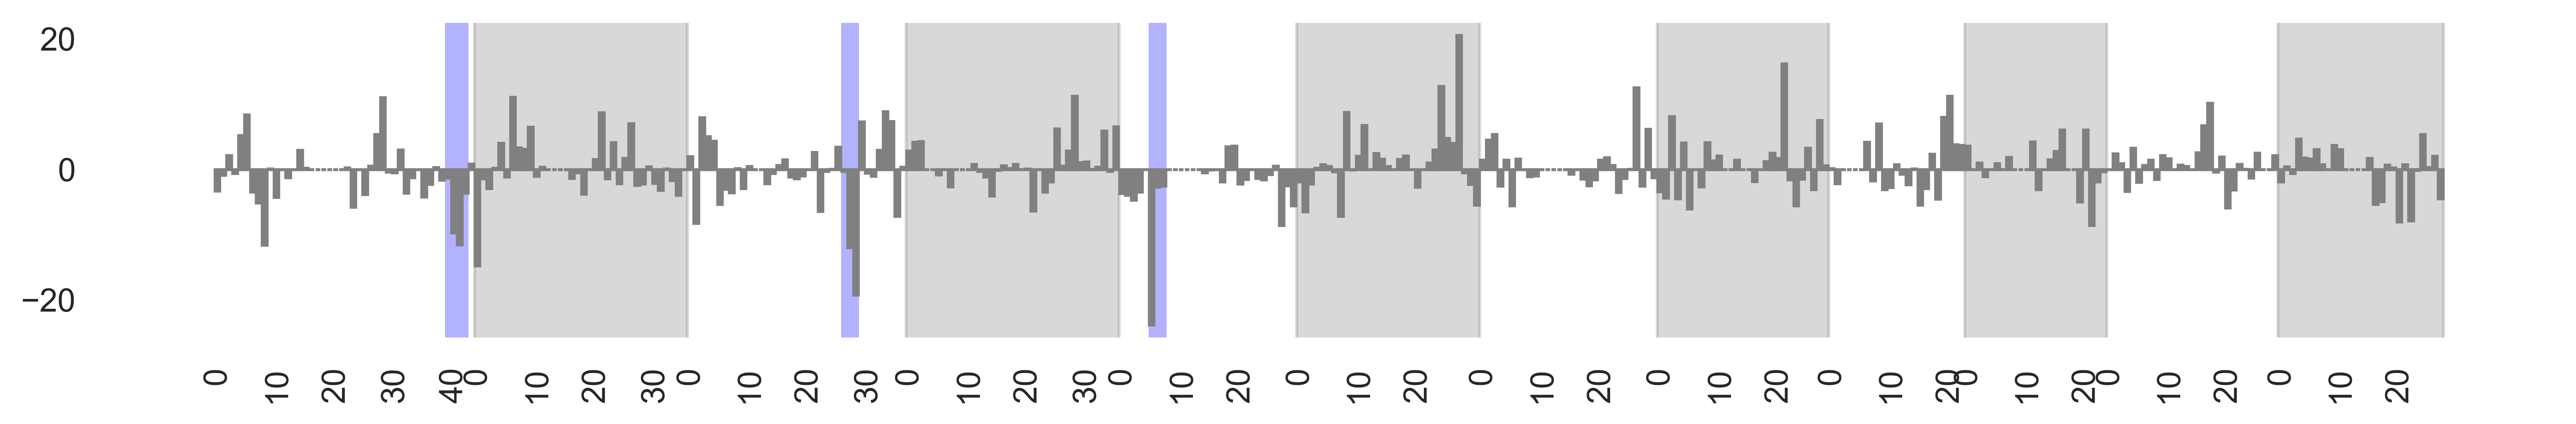

N08


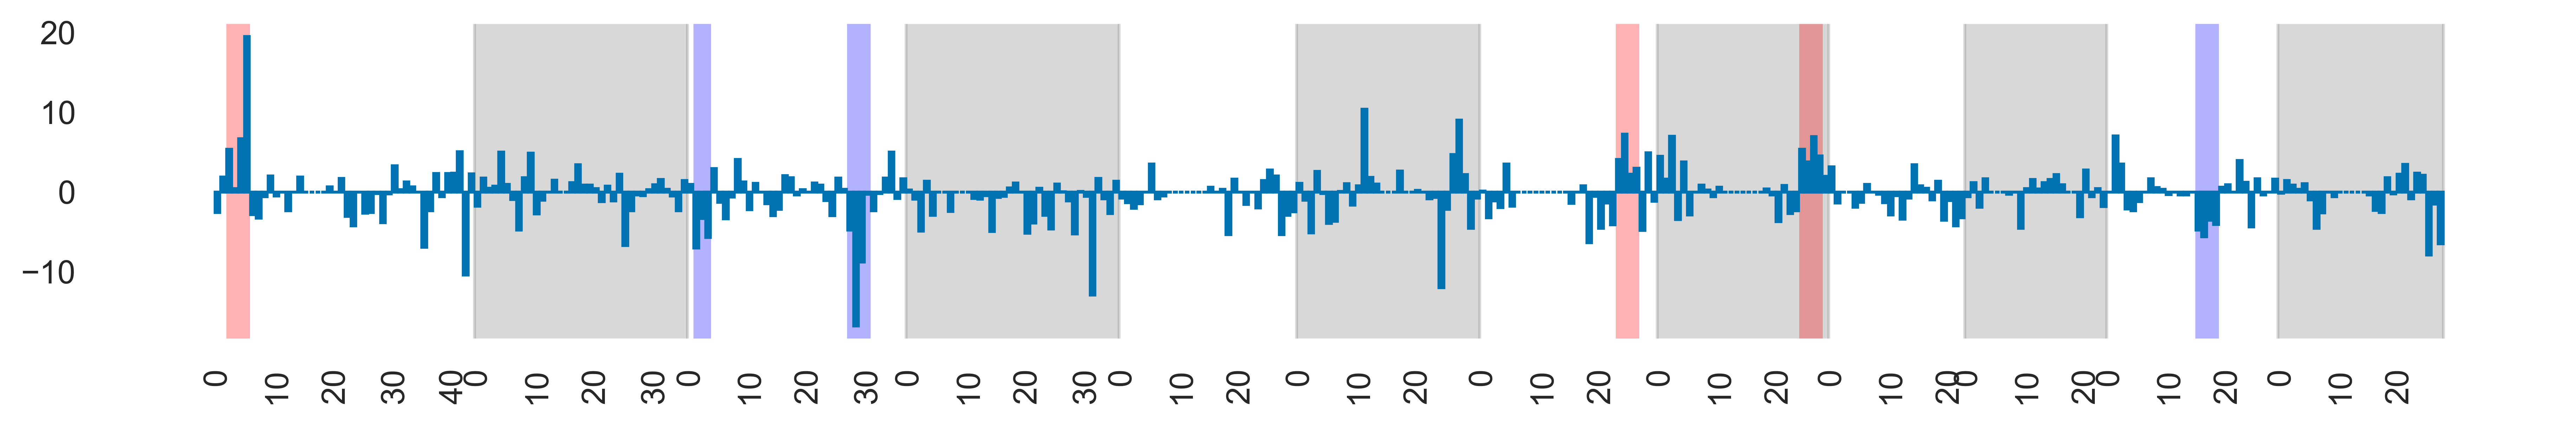

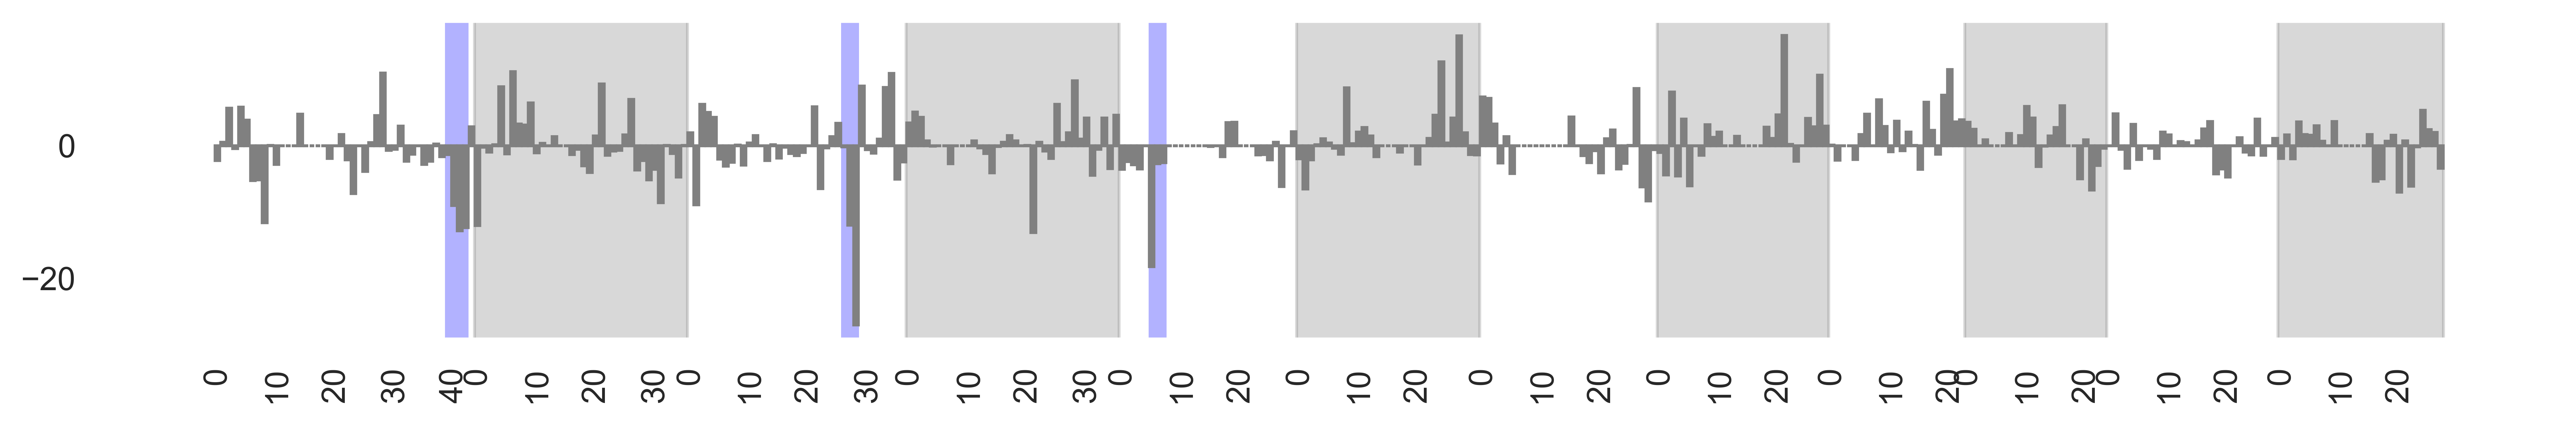

N09


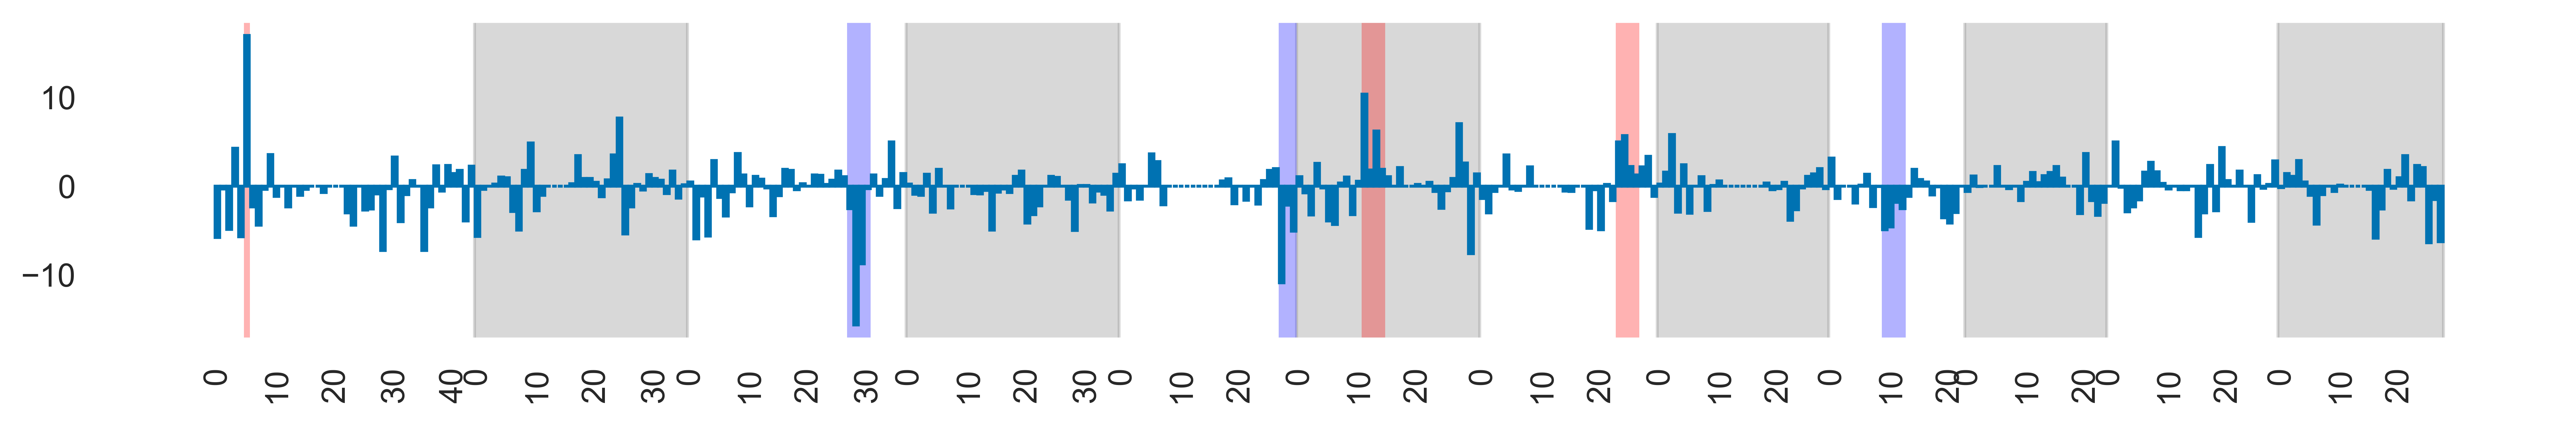

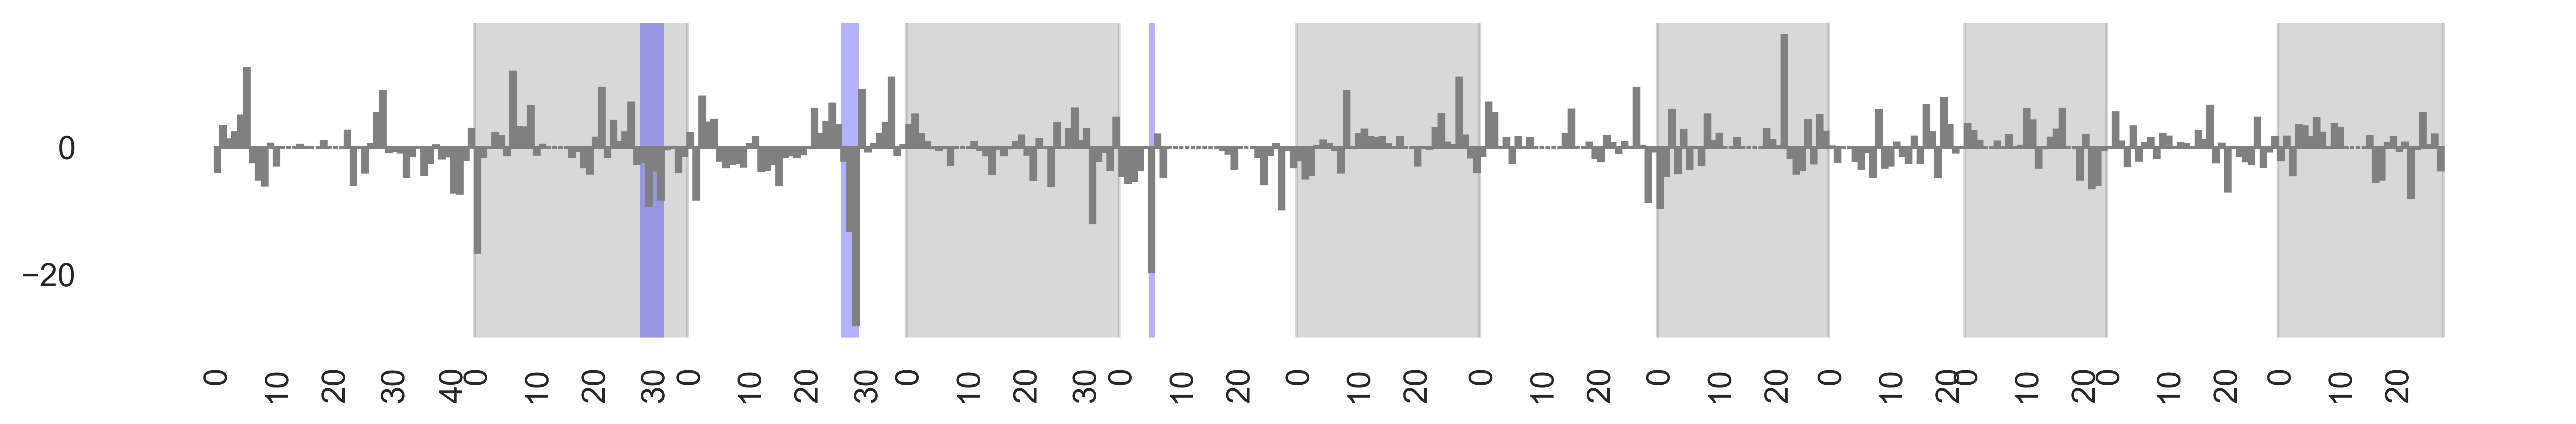

N10


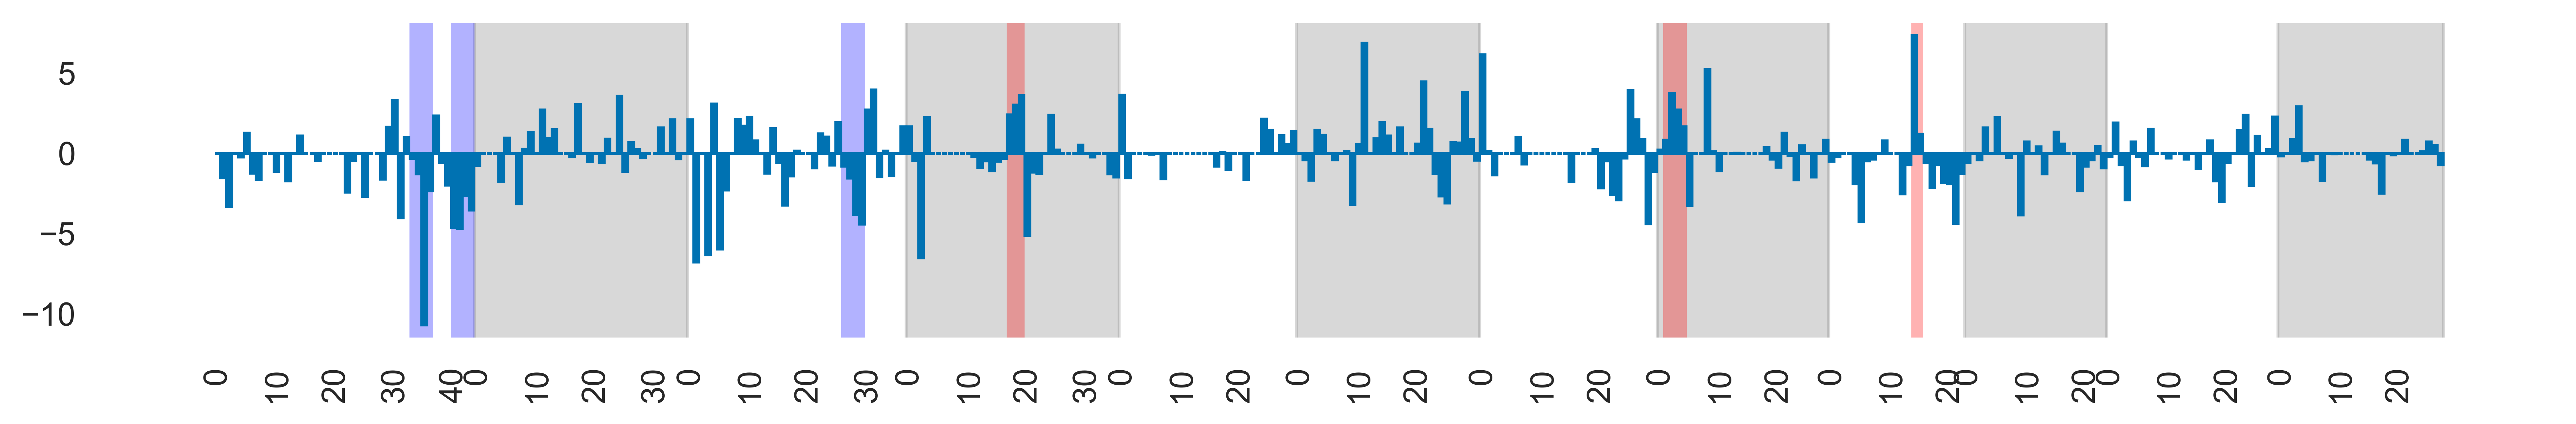

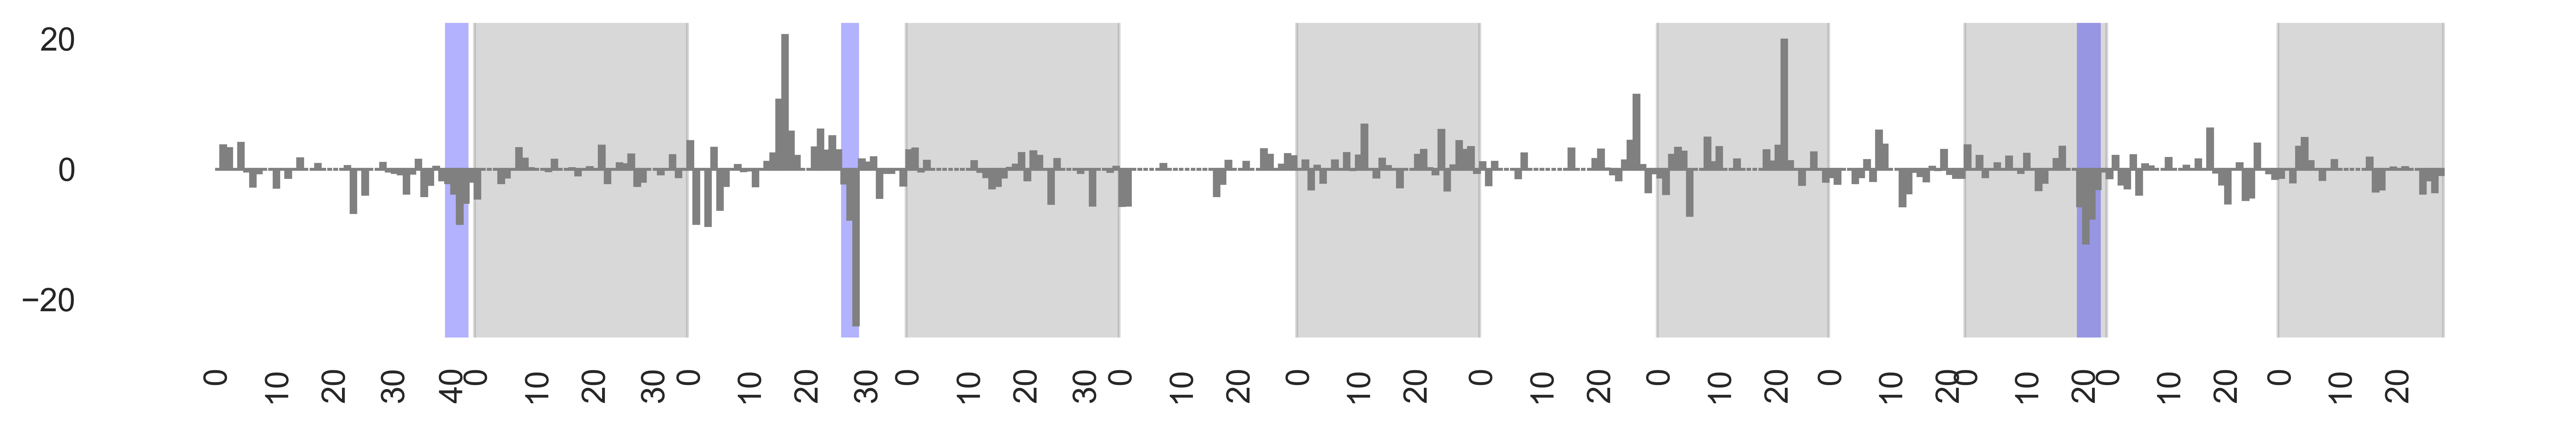

N11


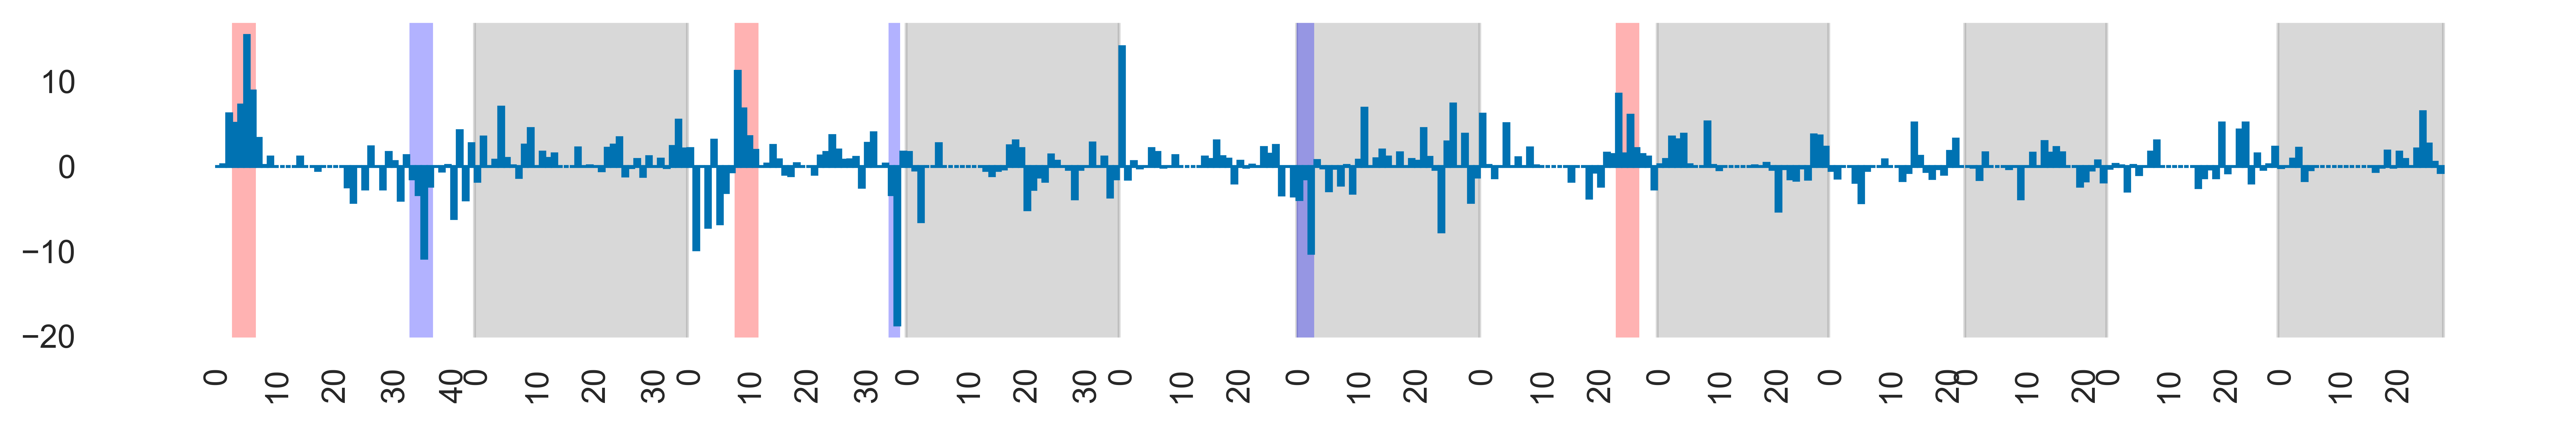

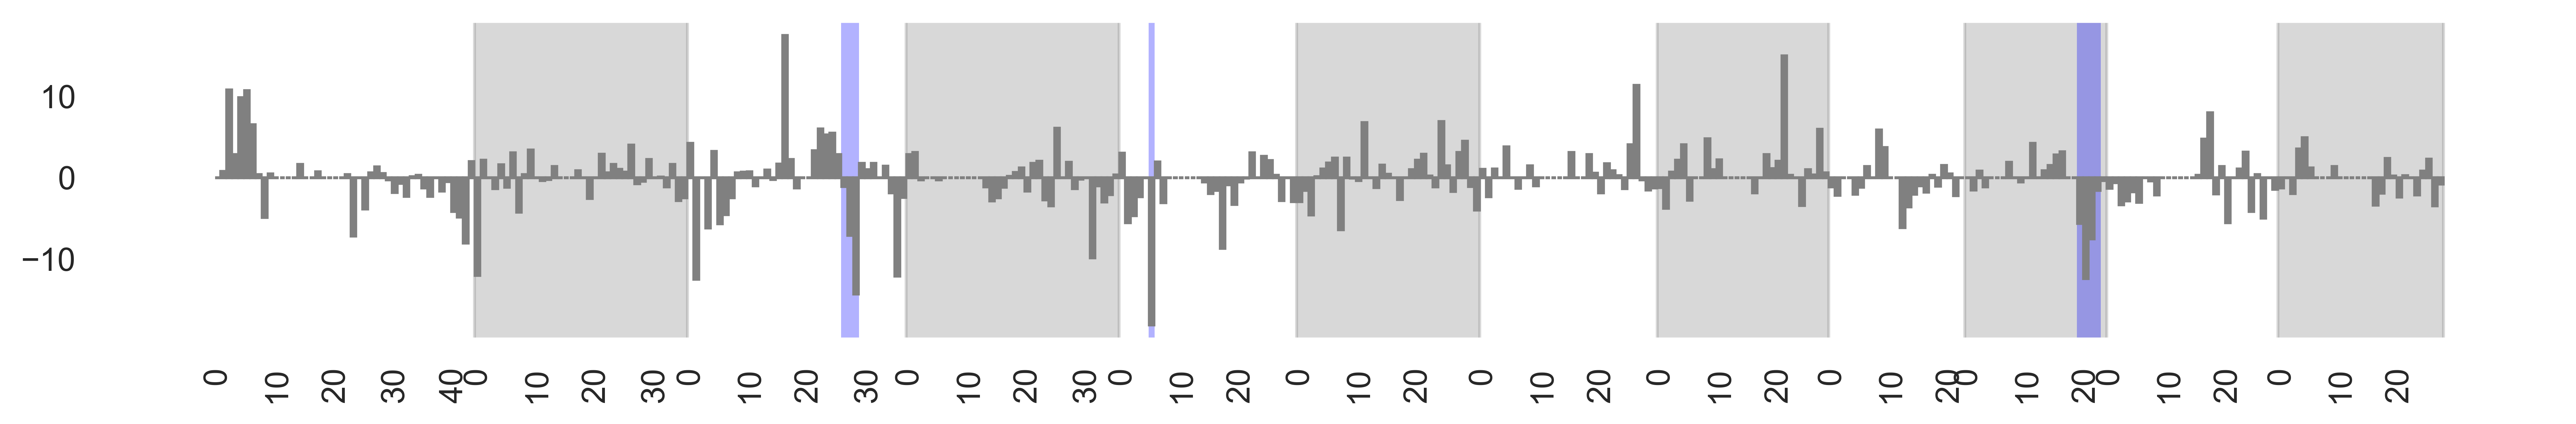

N12


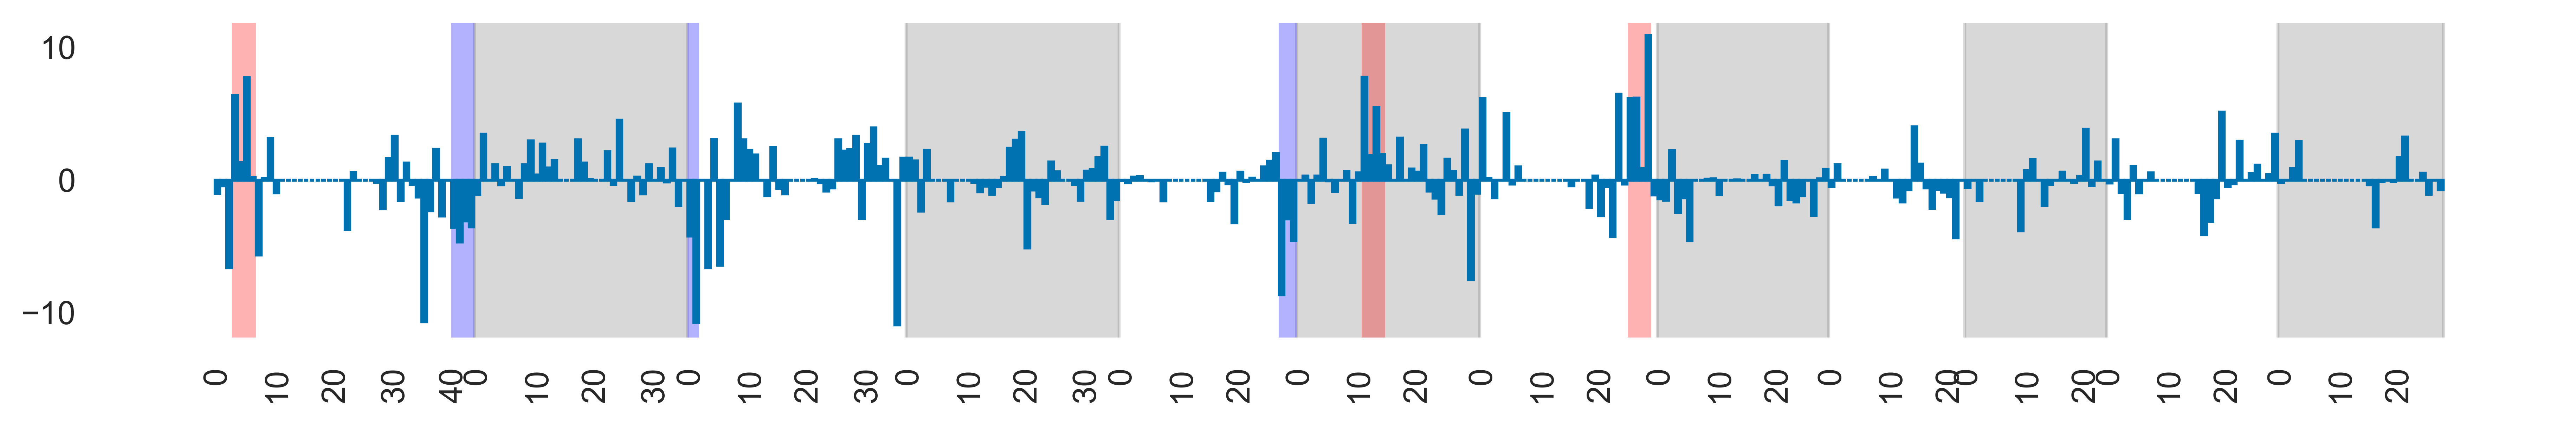

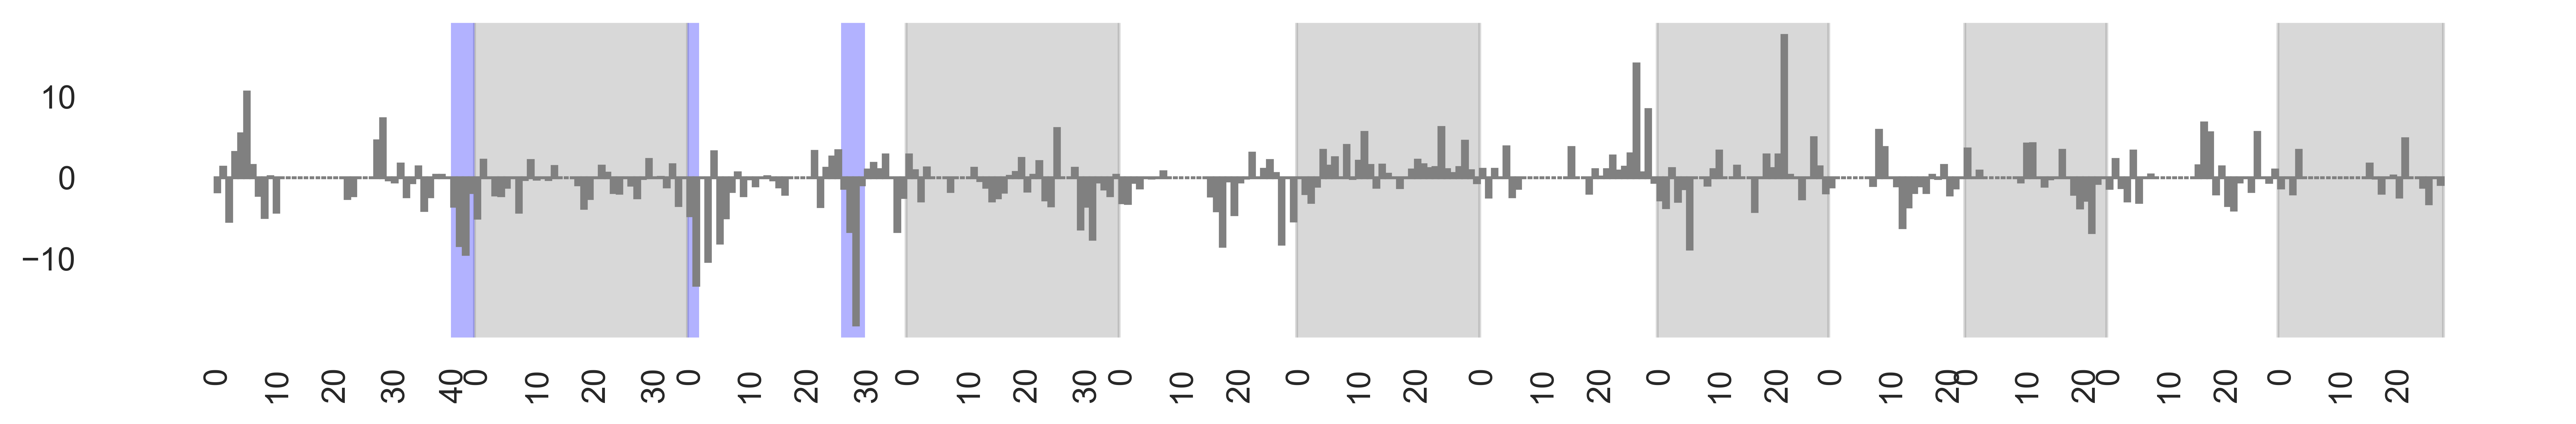

N13


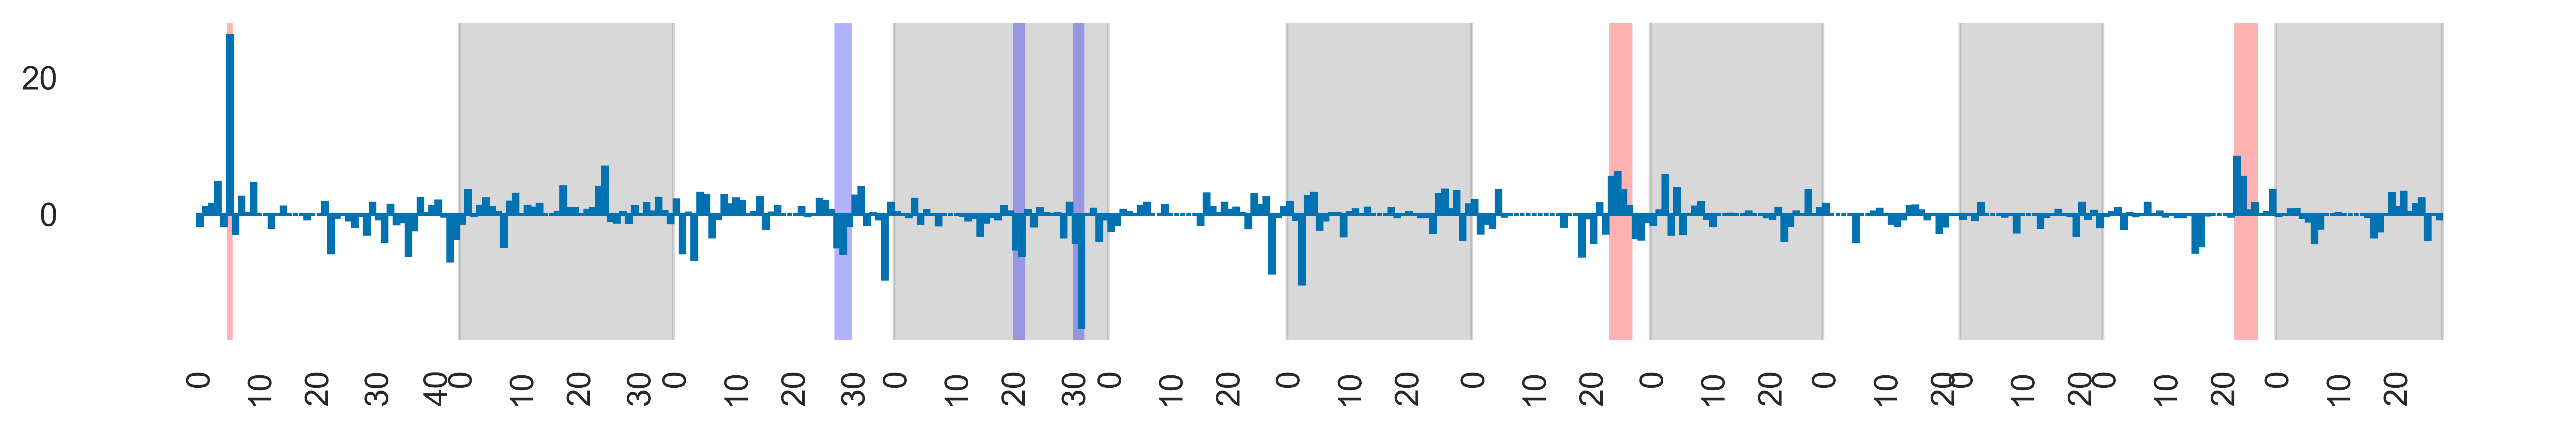

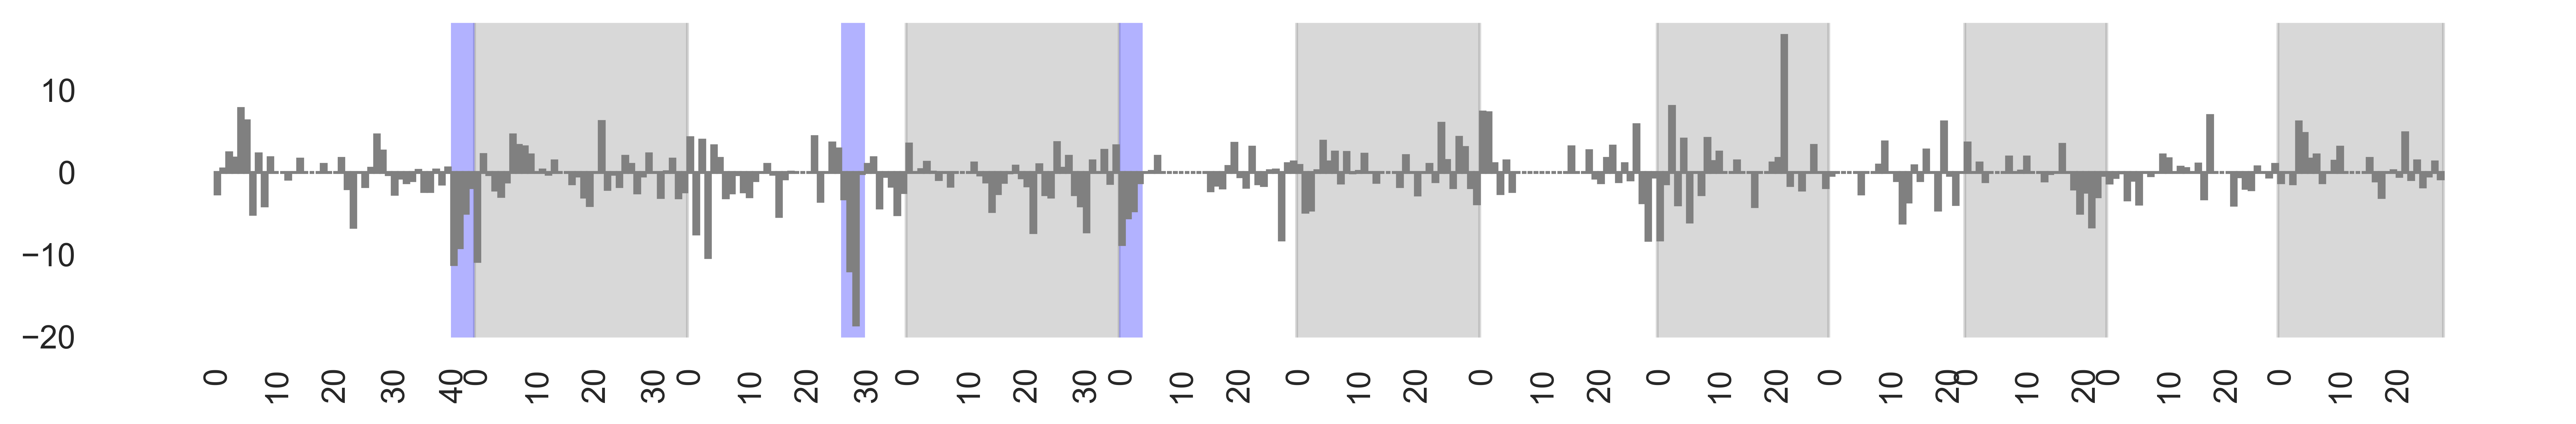

N14


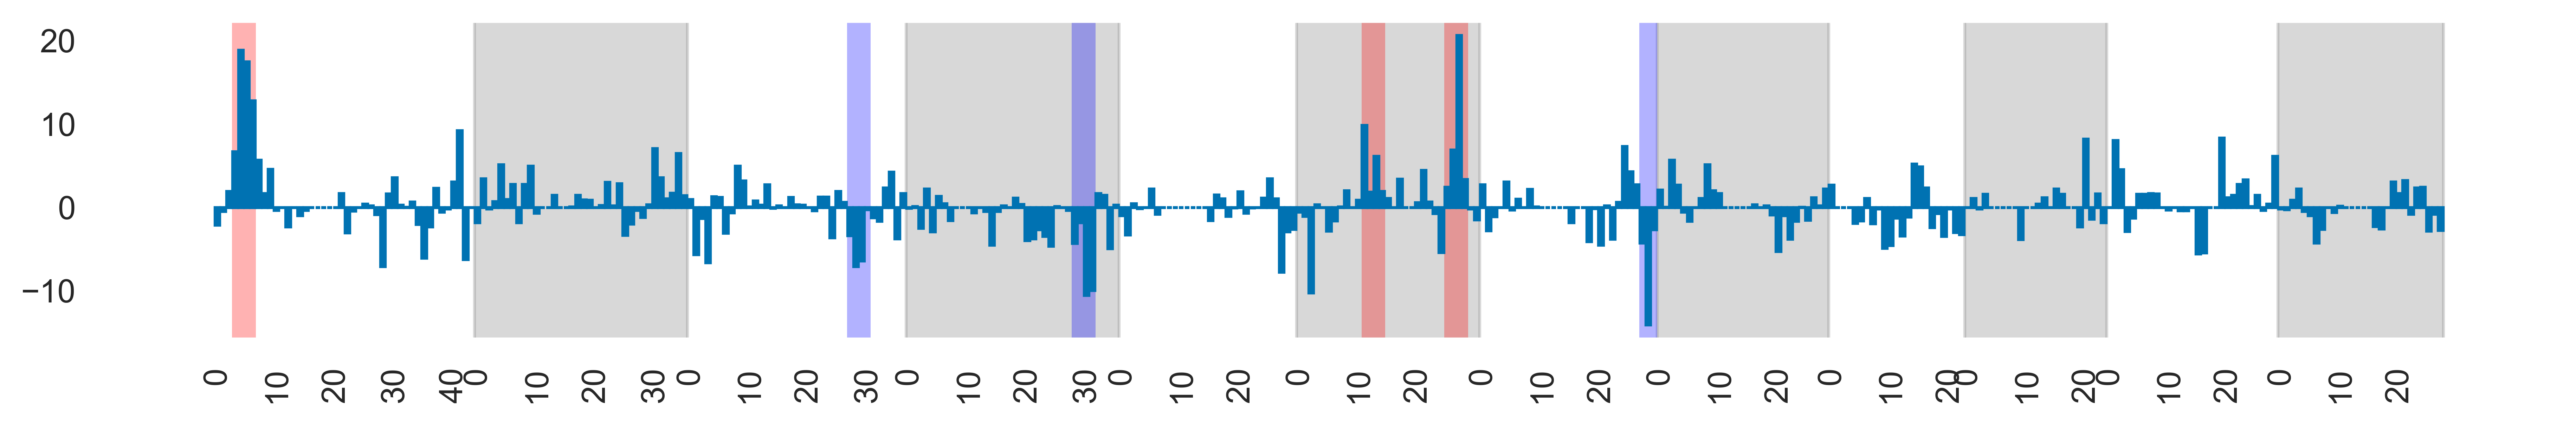

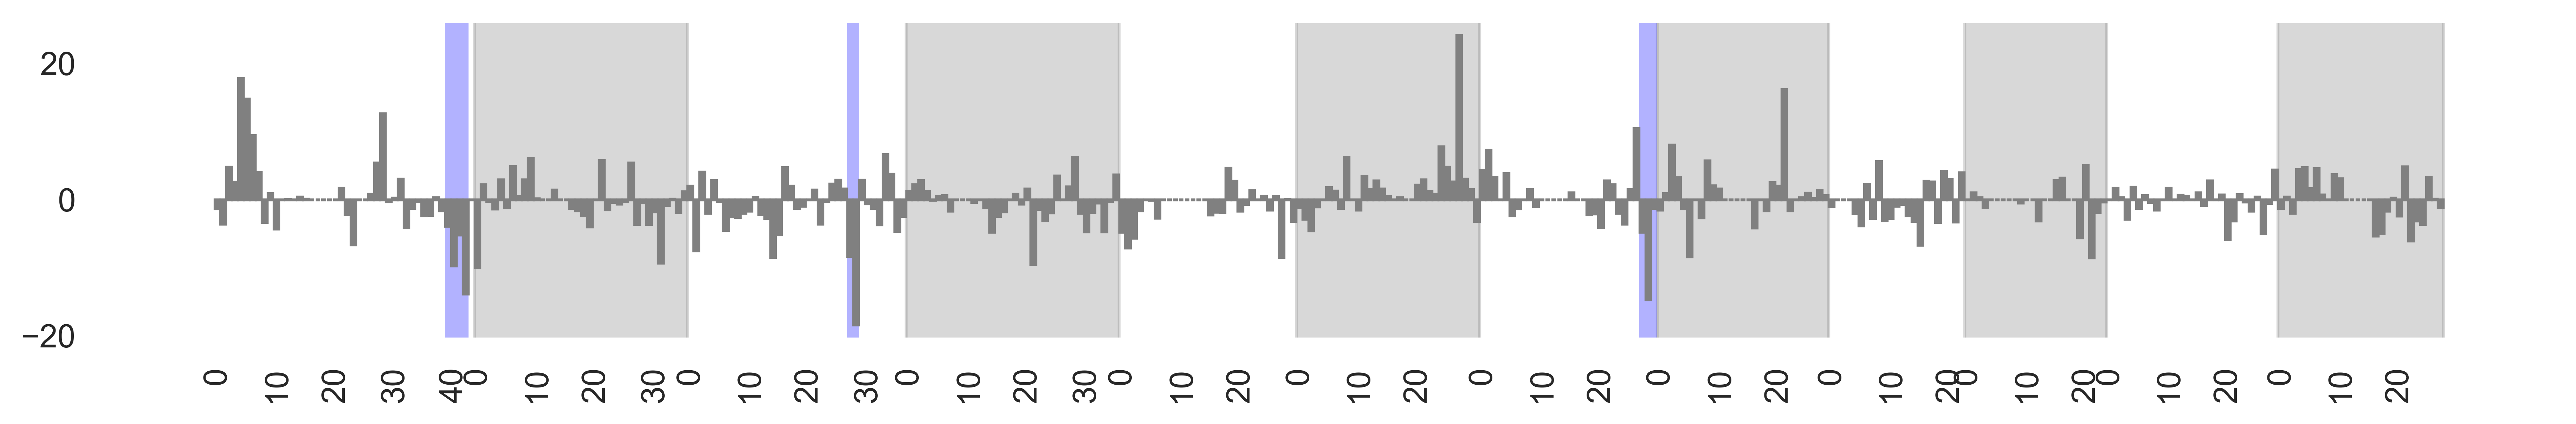

N16


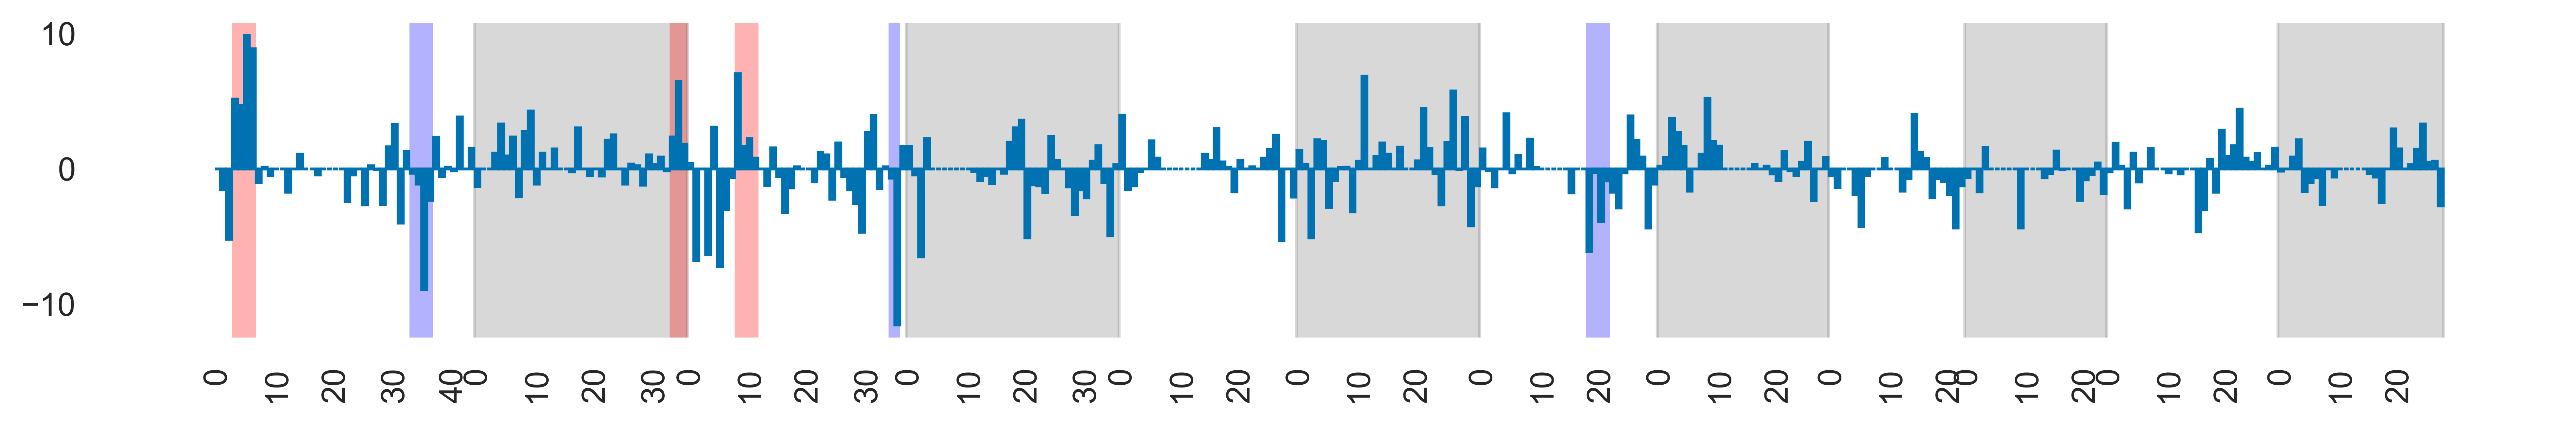

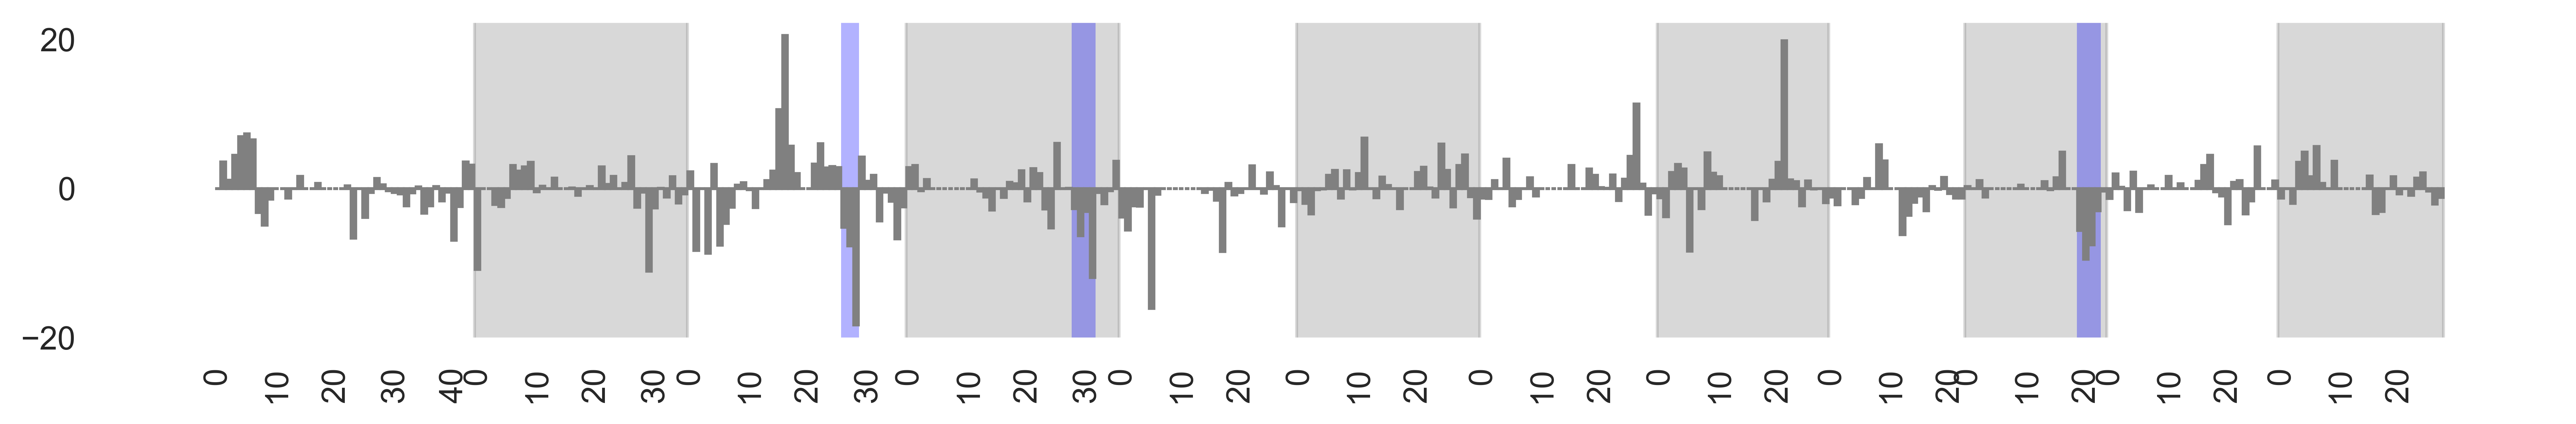

N17


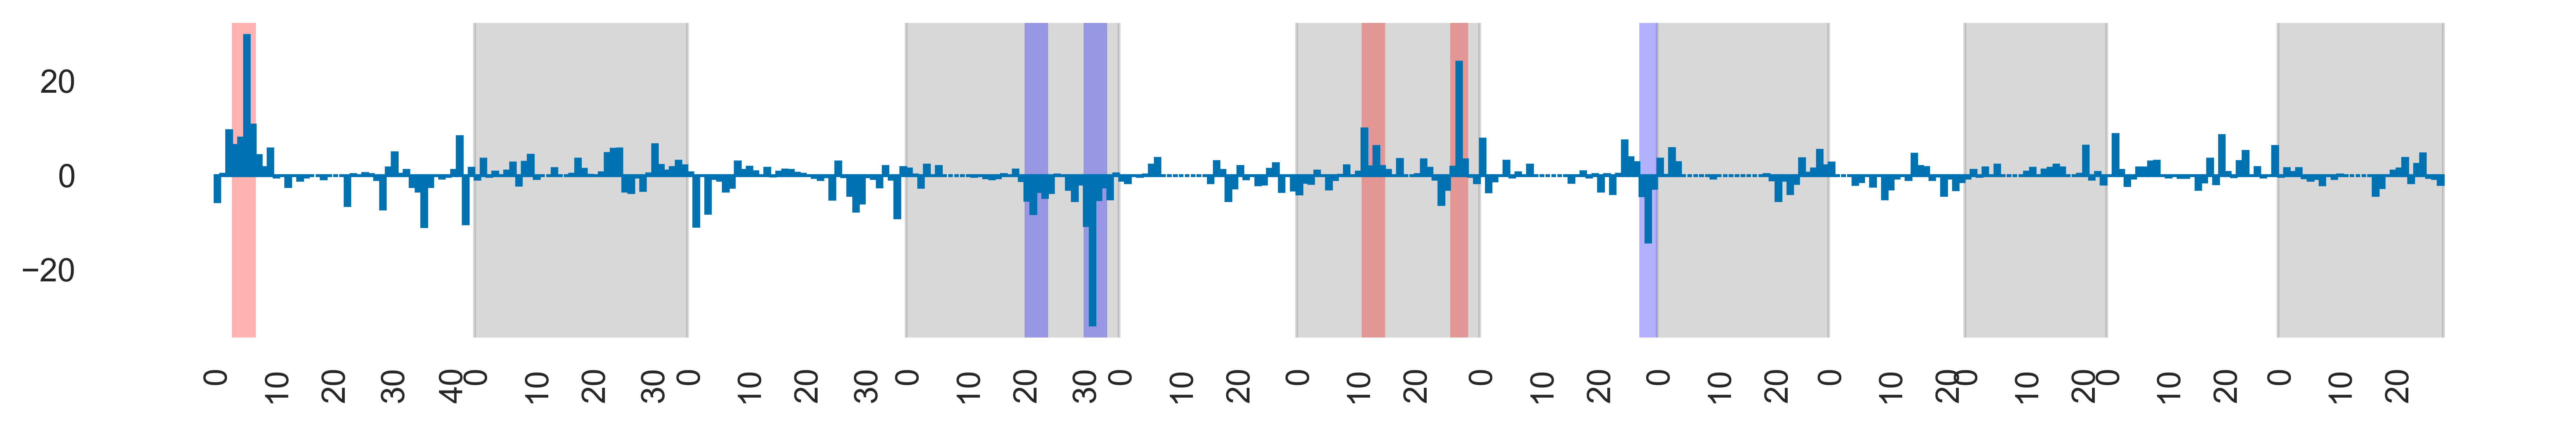

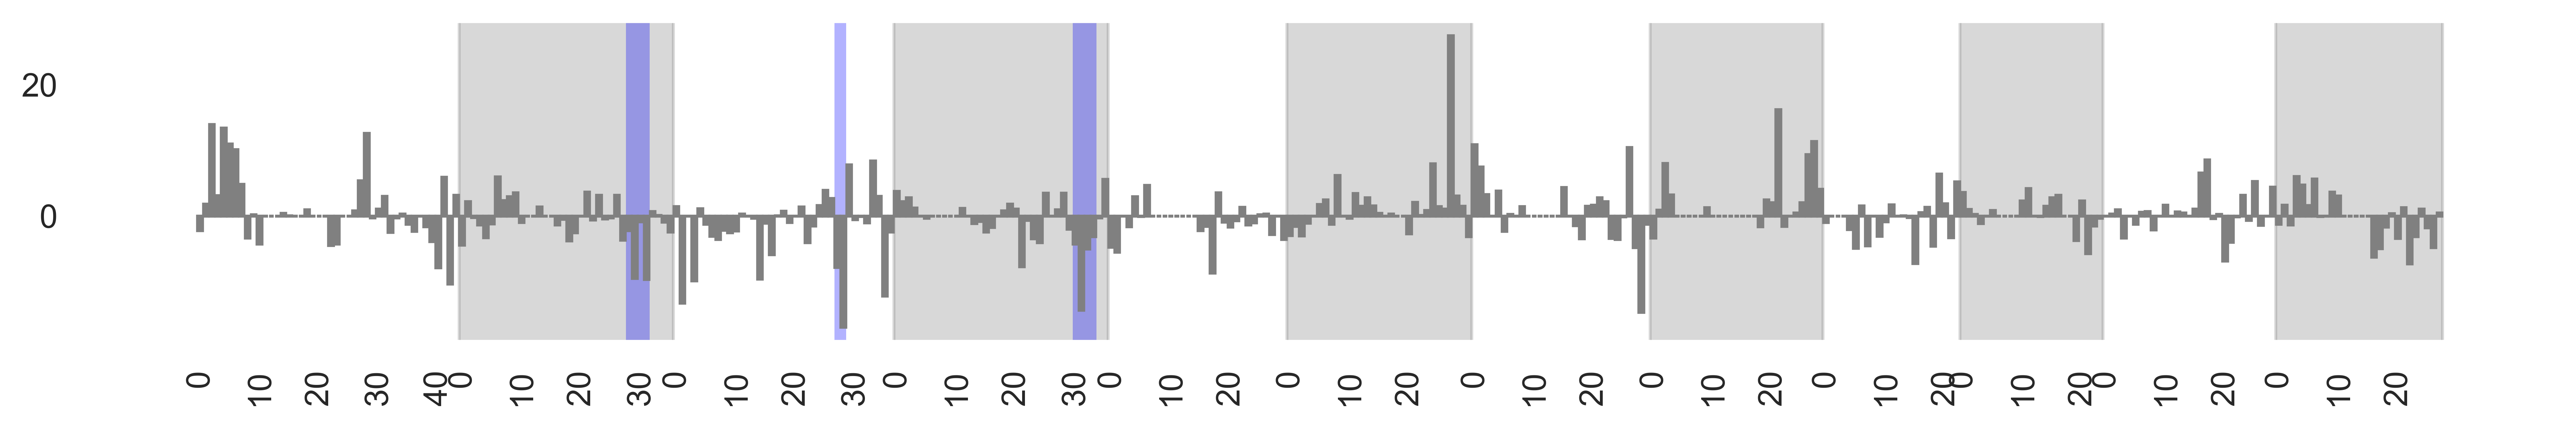

N18


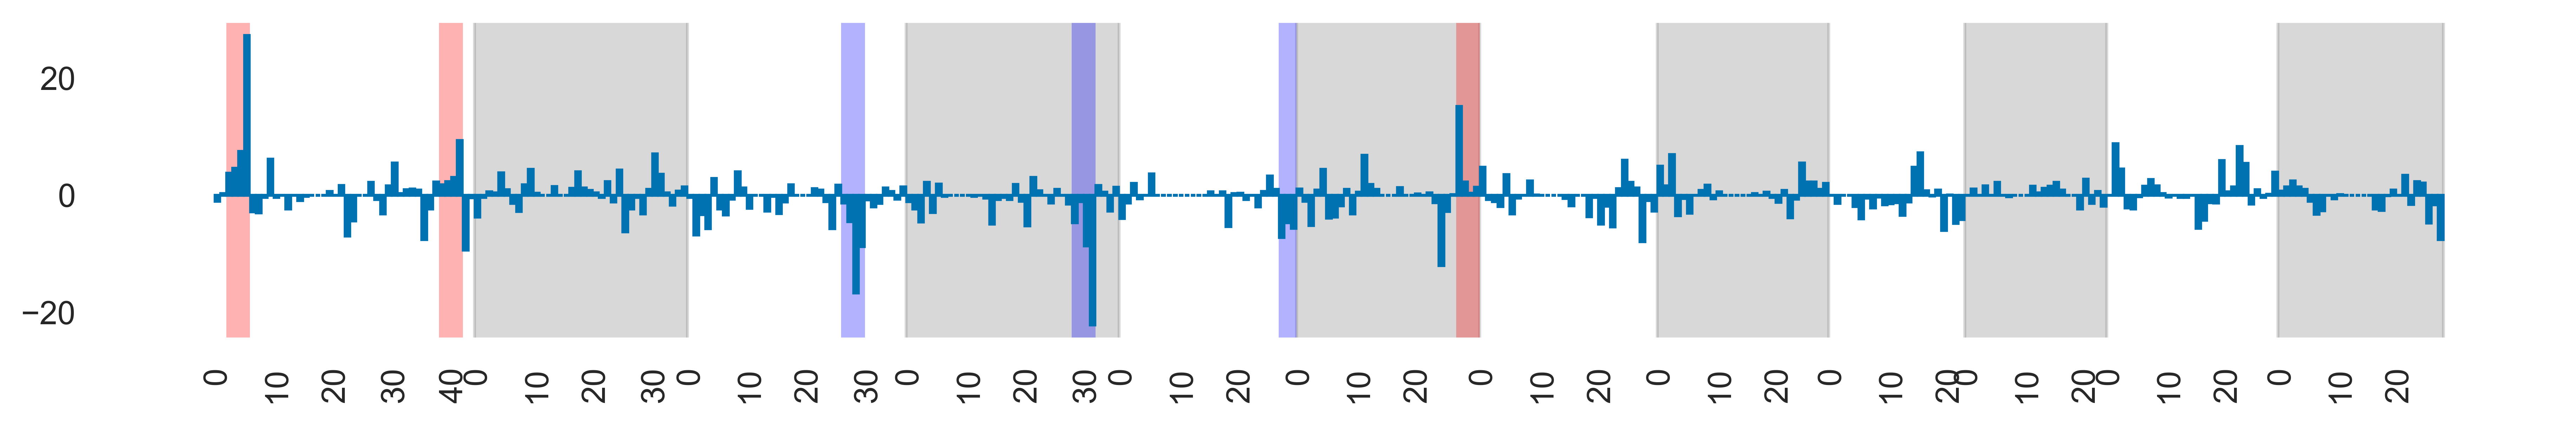

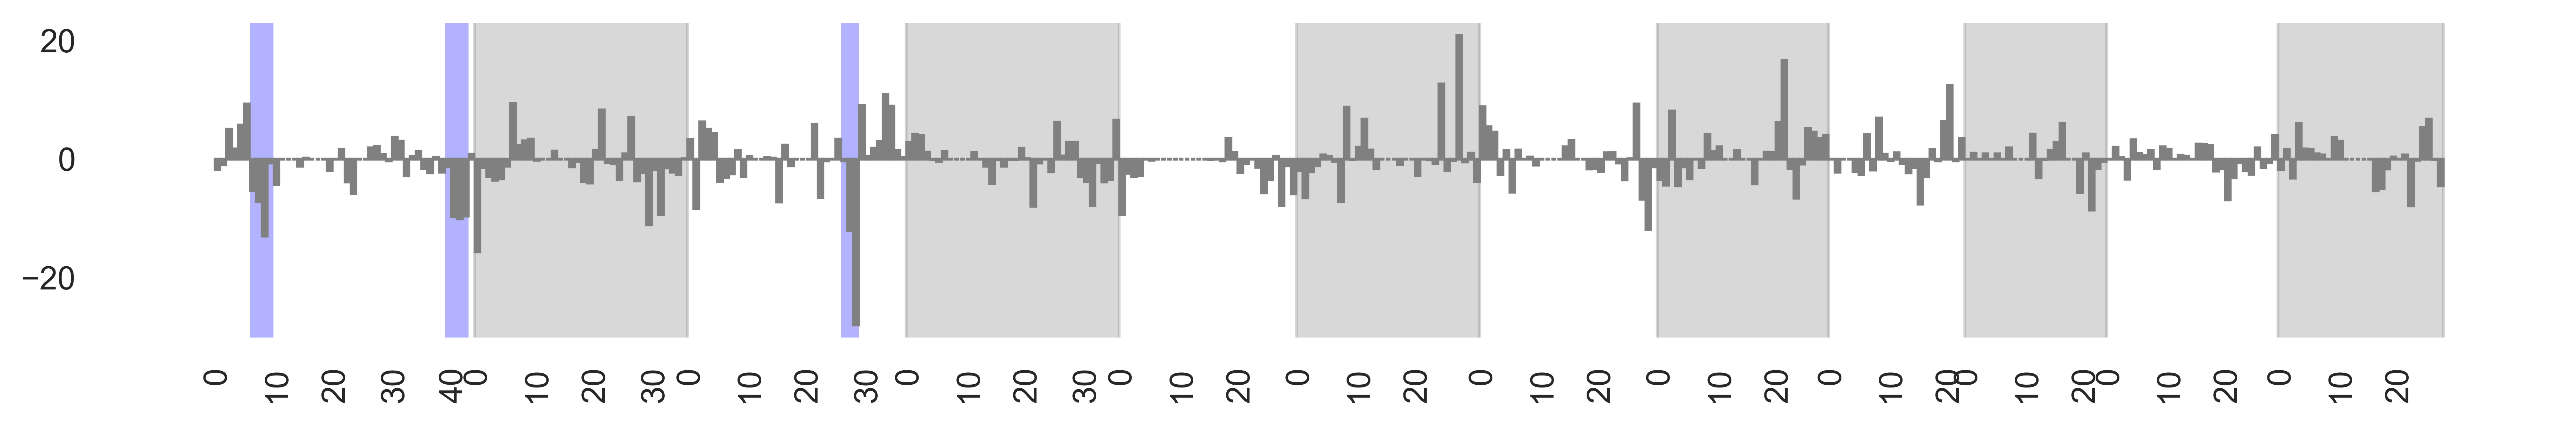

N19


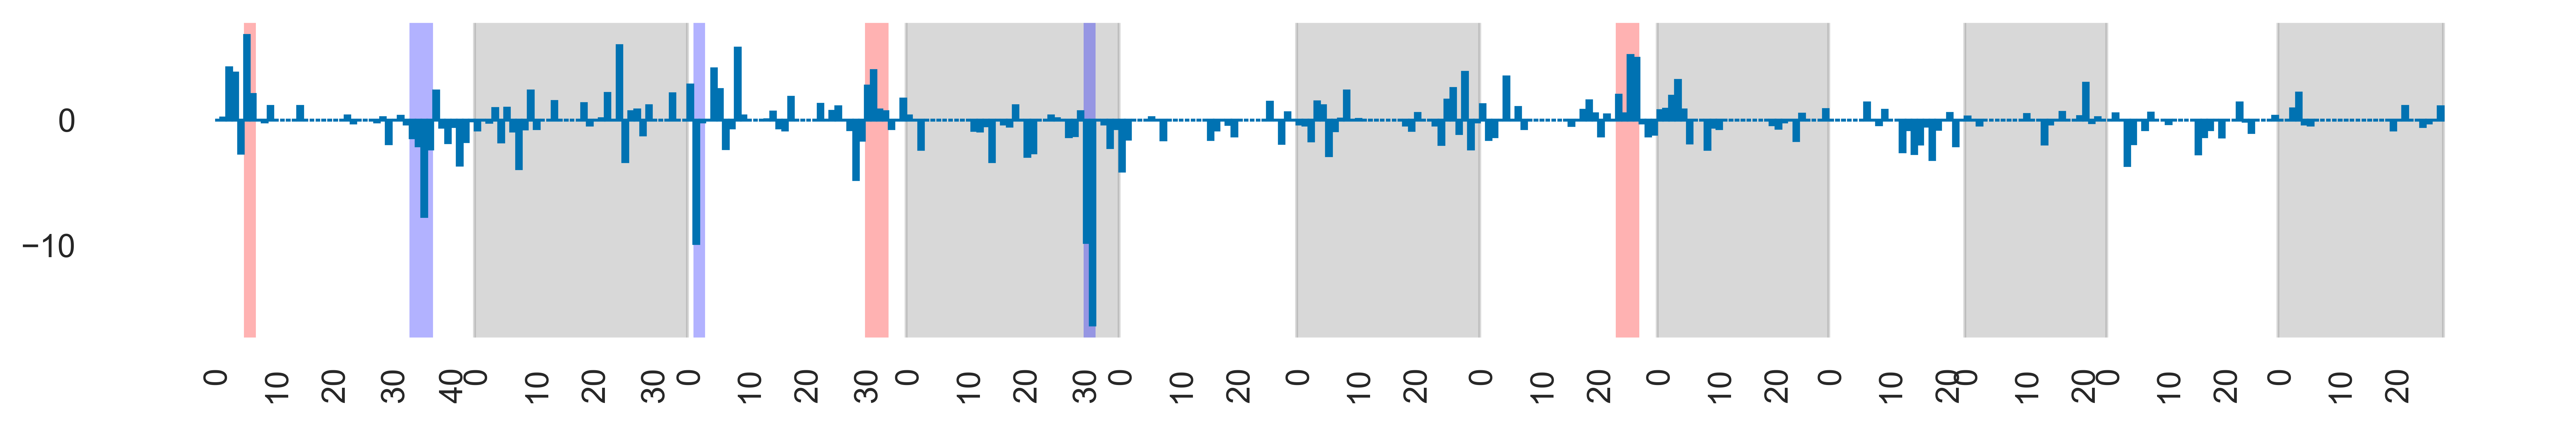

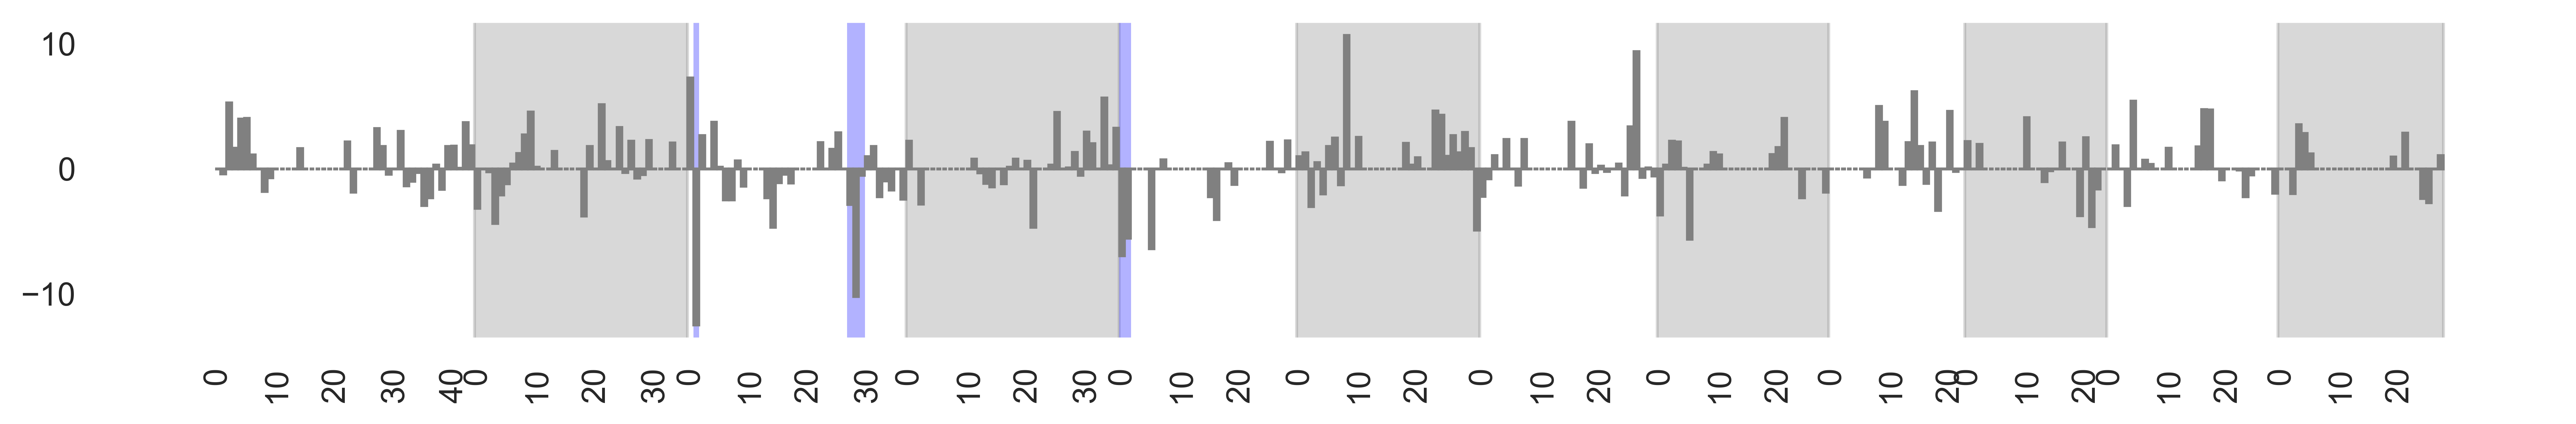

N20


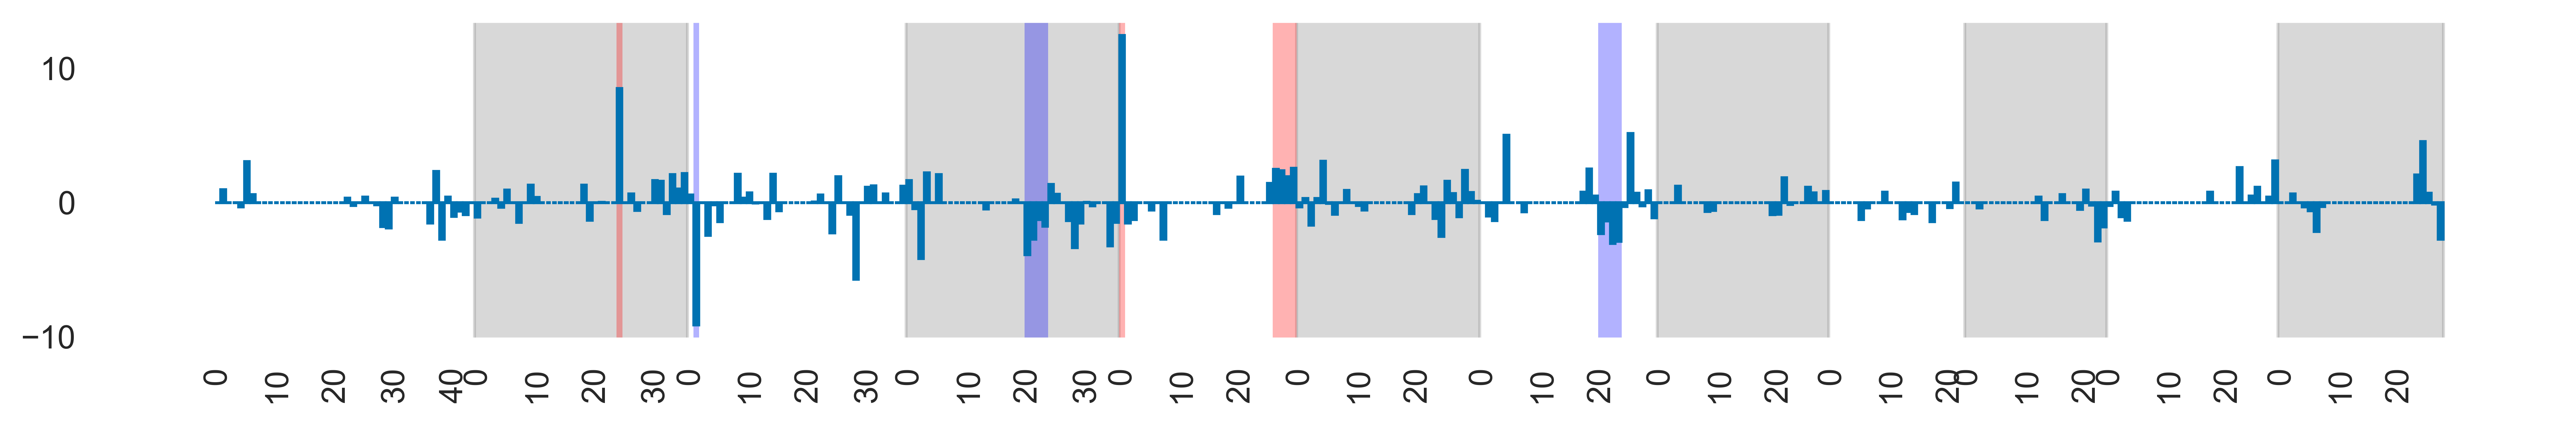

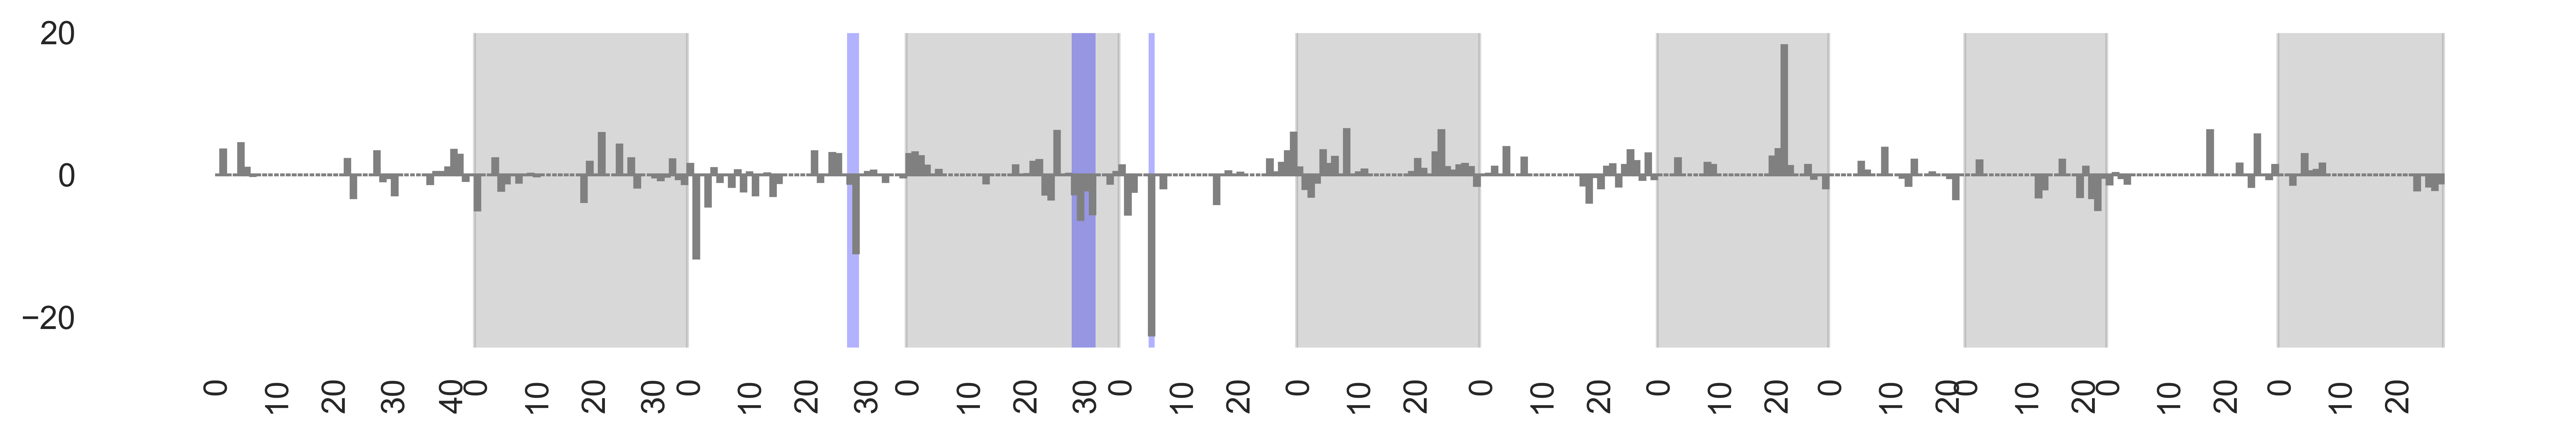

N21


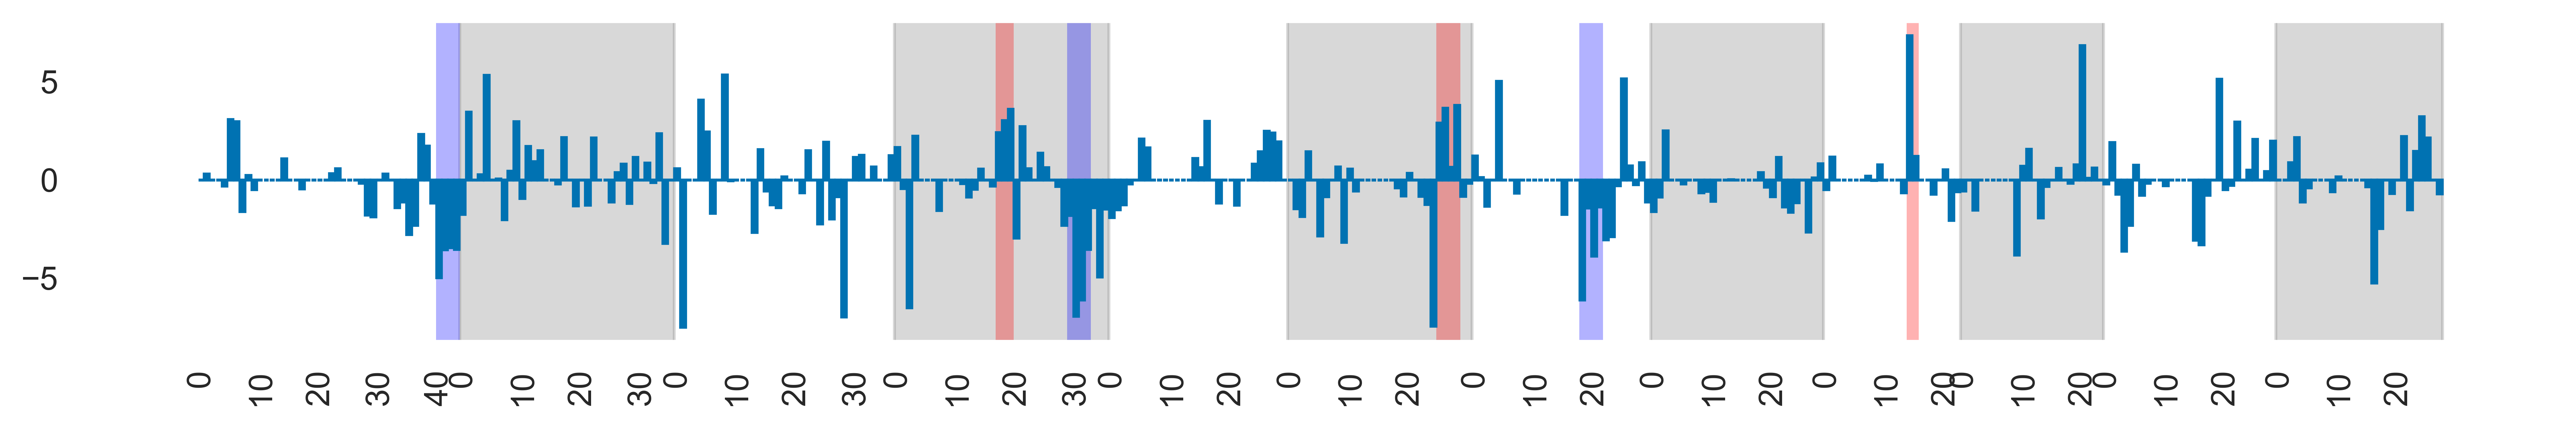

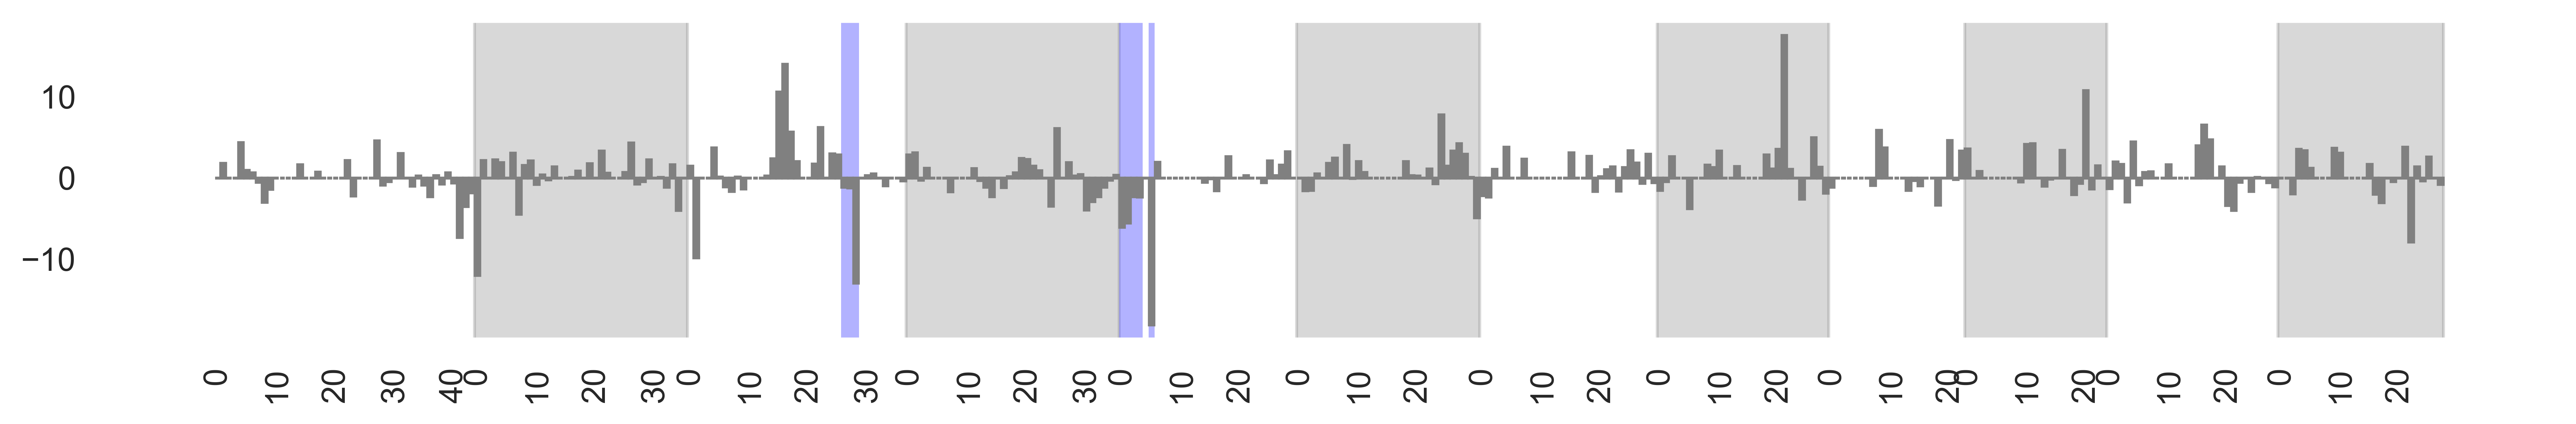

N22


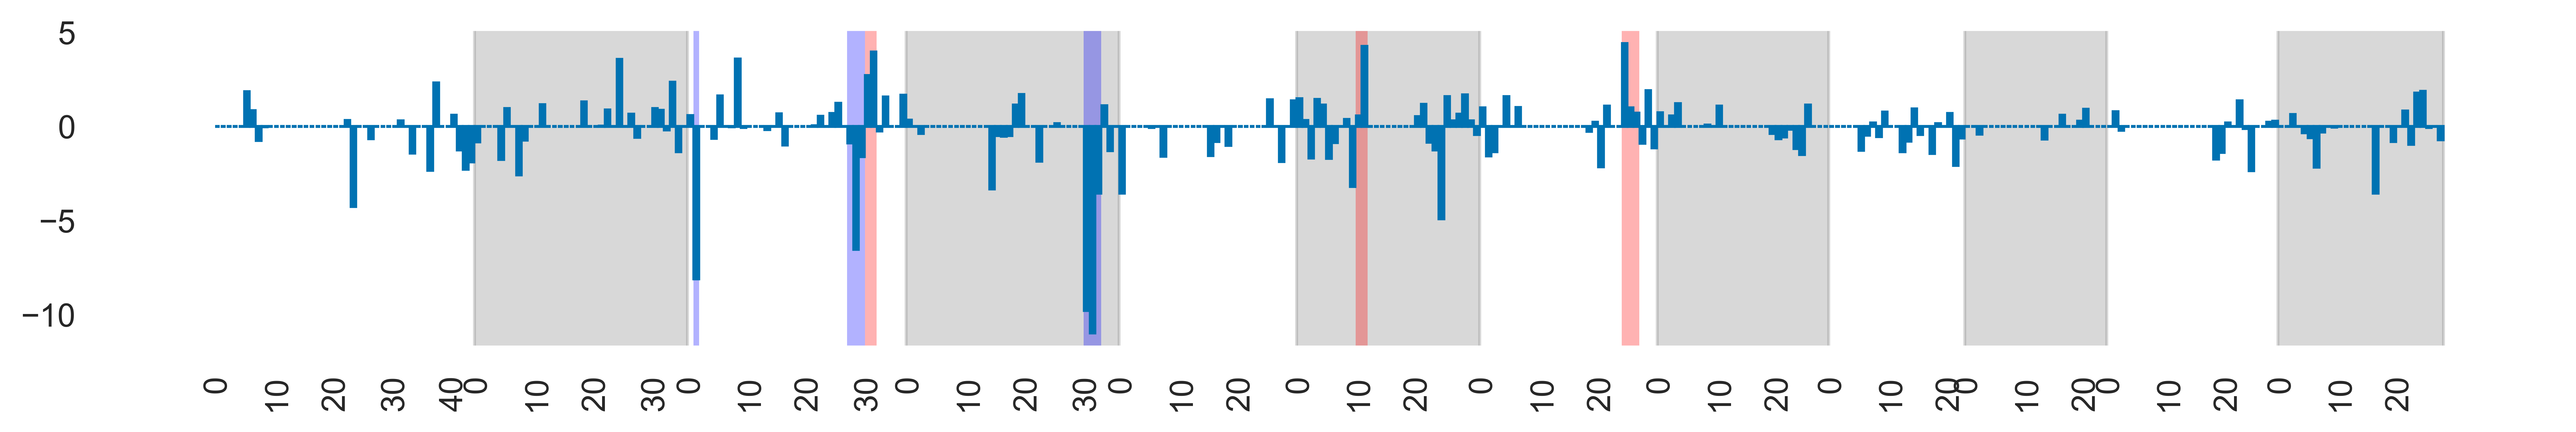

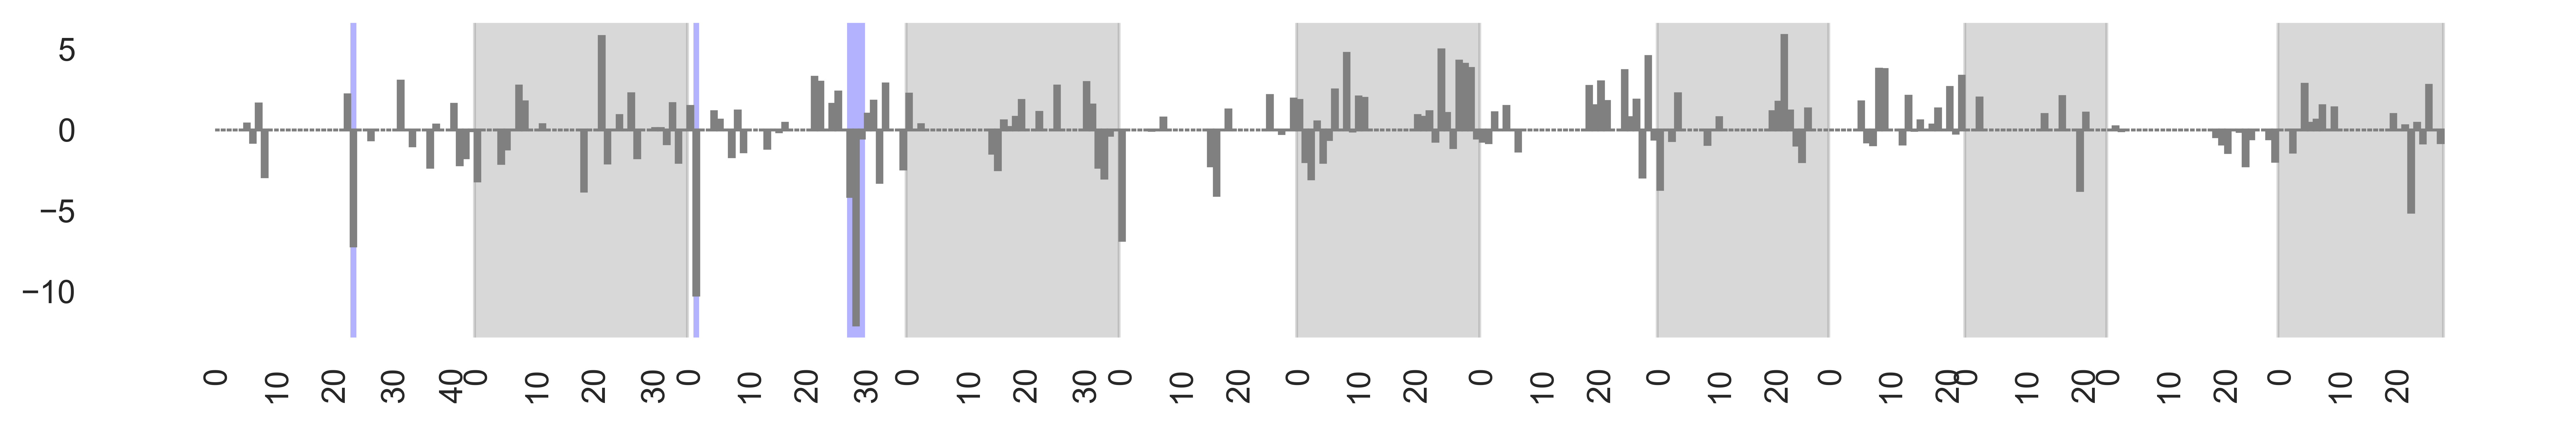

,RIL,GN_plus,GN_plus_regions,GN_plus_region_ratios,GN_minus,GN_minus_region_ratios,GN_merge,zscore_minus,zscore_minus_ratios,Hitome_per,GN_top_regions,GN_worst_regions,Total_worst_regions
159,N01_162,208.626191,3,"1.0, 0.956, 1.0",-0.401753,"0.085, 0, 0",208.224438,-1.027465,"0, 0, 0",0.678649,"chr07_25-29Mbp,chr01_2-6Mbp,chr06_25-29Mbp","chr04_28-32Mbp,chr03_26-30Mbp,chr09_19-23Mbp","chr03_26-29Mbp,chr10_19-23Mbp,chr01_6-10Mbp"
70,N17_071,189.827885,3,"1.0, 1.0, 1.0",0.000000,"0, 0, 0",189.827885,-27.829014,"0, 0.696, 0.167",0.736586,"chr01_3-7Mbp,chr06_26-29Mbp,chr06_11-15Mbp","chr04_30-34Mbp,chr04_20-24Mbp,chr07_27-30Mbp","chr04_30-34Mbp,chr03_27-29Mbp,chr02_28-32Mbp"
78,N01_079,197.499721,3,"1.0, 0.844, 1.0",-49.185447,"0, 0, 1.0",148.314274,12.709778,"0, 0, 0.237",0.721655,"chr07_25-29Mbp,chr01_2-6Mbp,chr06_25-29Mbp","chr04_28-32Mbp,chr03_26-30Mbp,chr09_19-23Mbp","chr03_26-29Mbp,chr10_19-23Mbp,chr01_6-10Mbp"
43,N06_044,148.258562,3,"1.0, 0.842, 1.0",-19.154834,"0, 0.413, 0.2",129.103729,-26.479667,"0, 0, 0.5",0.668060,"chr07_25-29Mbp,chr06_27-29Mbp,chr06_11-15Mbp","chr03_26-30Mbp,chr05_27-30Mbp,chr11_15-19Mbp","chr03_26-29Mbp,chr01_39-43Mbp,chr10_19-23Mbp"
14,N07_015,123.925682,2,"1.0, 0, 1.0",0.000000,"0, 0, 0",123.925682,-58.735530,"0, 0.833, 0.178",0.650565,"chr07_28-29Mbp,chr01_5-6Mbp,chr06_25-29Mbp","chr03_26-30Mbp,chr04_31-35Mbp,chr04_20-24Mbp","chr03_26-29Mbp,chr05_5-8Mbp,chr01_39-43Mbp"
157,N01_160,105.724763,2,"0.717, 0.489, 0",-10.279383,"0.234, 0, 0",95.445381,-36.729344,"0, 0.667, 0",0.665381,"chr07_25-29Mbp,chr01_2-6Mbp,chr06_25-29Mbp","chr04_28-32Mbp,chr03_26-30Mbp,chr09_19-23Mbp","chr03_26-29Mbp,chr10_19-23Mbp,chr01_6-10Mbp"
190,N18_191,100.975026,2,"1.0, 0, 0.432",-7.665045,"0, 0.045, 0.167",93.309980,-25.593188,"0.06, 0.26, 0",0.682583,"chr01_2-6Mbp,chr06_27-31Mbp,chr01_38-42Mbp","chr04_28-32Mbp,chr03_26-30Mbp,chr05_27-30Mbp","chr03_26-29Mbp,chr01_39-43Mbp,chr01_6-10Mbp"
73,N01_074,160.780452,3,"1.0, 1.0, 0.182",-69.165106,"1.0, 0, 0",91.615346,-18.256215,"0, 0.222, 0",0.663073,"chr07_25-29Mbp,chr01_2-6Mbp,chr06_25-29Mbp","chr04_28-32Mbp,chr03_26-30Mbp,chr09_19-23Mbp","chr03_26-29Mbp,chr10_19-23Mbp,chr01_6-10Mbp"
188,N09_192,90.607280,3,"1.0, 1.0, 0.68",0.000000,"0, 0, 0",90.607280,0.000000,"0, 0, 0",0.686598,"chr06_11-15Mbp,chr01_5-6Mbp,chr07_23-27Mbp","chr03_27-31Mbp,chr05_27-30Mbp,chr09_9-13Mbp","chr03_26-29Mbp,chr02_28-32Mbp,chr05_5-6Mbp"
8,N08_009,105.307672,2,"1.0, 1.0, 0",-18.424832,"0, 0, 0.429",86.882840,-67.965700,"0, 0, 1.0",0.697675,"chr01_2-6Mbp,chr08_24-28Mbp,chr07_23-27Mbp","chr03_27-31Mbp,chr11_15-19Mbp,chr03_1-4Mbp","chr03_26-29Mbp,chr01_39-43Mbp,chr05_5-8Mbp"


In [3]:
genotype_path = "../data/PART7_Select_useful_RILs/Haplotype_high_imp_HBs_for_3traits.csv"
Hitome_per_path = "../data/PART0_NAM_stats/Percentage_Hitomebore_genotype.csv"

GN_top_regions_effect_summary = pd.DataFrame()
for pop in [i[:3] for i in family]:
    print(pop)
    
    # merge genetic effect within 1Mbp region
    regional_info_all = make_regional_info(imp_data, 1000000, "../data/PART7_Select_useful_RILs/Haplotype_high_imp_HBs_for_3traits.csv", pop)
    
    # get top3 beneficial regions, detrimental regions
    GN_top_regions = get_top_regions(regional_info_all, "GN_imps", "top", 3)
    GN_worst_regions = get_top_regions(regional_info_all, "GN_imps", "worst", 3)
    Total_worst_regions = get_top_regions(regional_info_all, "sum_zscore", "worst", 3)
    
    # visualize genetic effect
    plot_regional_info_with_target(regional_info_all, "GN_imps", "#0072B2", GN_top_regions, GN_worst_regions)
    plot_regional_info_with_target(regional_info_all, "sum_zscore", "gray", [], Total_worst_regions)
    
    # get stats
    each_effect_summary = target_effect_summary(imp_data, genotype_path, Hitome_per_path, pop, "GN", GN_top_regions, GN_worst_regions, Total_worst_regions)
    each_effect_summary["GN_top_regions"] = ",".join([f"{i[0]}_{i[1]//1000000}-{i[2]//1000000}Mbp" for i in GN_top_regions])
    each_effect_summary["GN_worst_regions"] = ",".join([f"{i[0]}_{i[1]//1000000}-{i[2]//1000000}Mbp" for i in GN_worst_regions])
    each_effect_summary["Total_worst_regions"] = ",".join([f"{i[0]}_{i[1]//1000000}-{i[2]//1000000}Mbp" for i in Total_worst_regions])
    GN_top_regions_effect_summary = pd.concat([GN_top_regions_effect_summary, each_effect_summary])

GN_top_regions_effect_summary.to_csv("../data/PART7_Select_useful_RILs/Select_RILs_for_GN_stats.csv")
# show the candidate RILs for breeding material
display(GN_top_regions_effect_summary[GN_top_regions_effect_summary.Hitome_per > 0.65].sort_values(by="GN_merge", ascending=False).iloc[:10, :])

## Check genetic effect on PN for each candidate RIL populations

N01


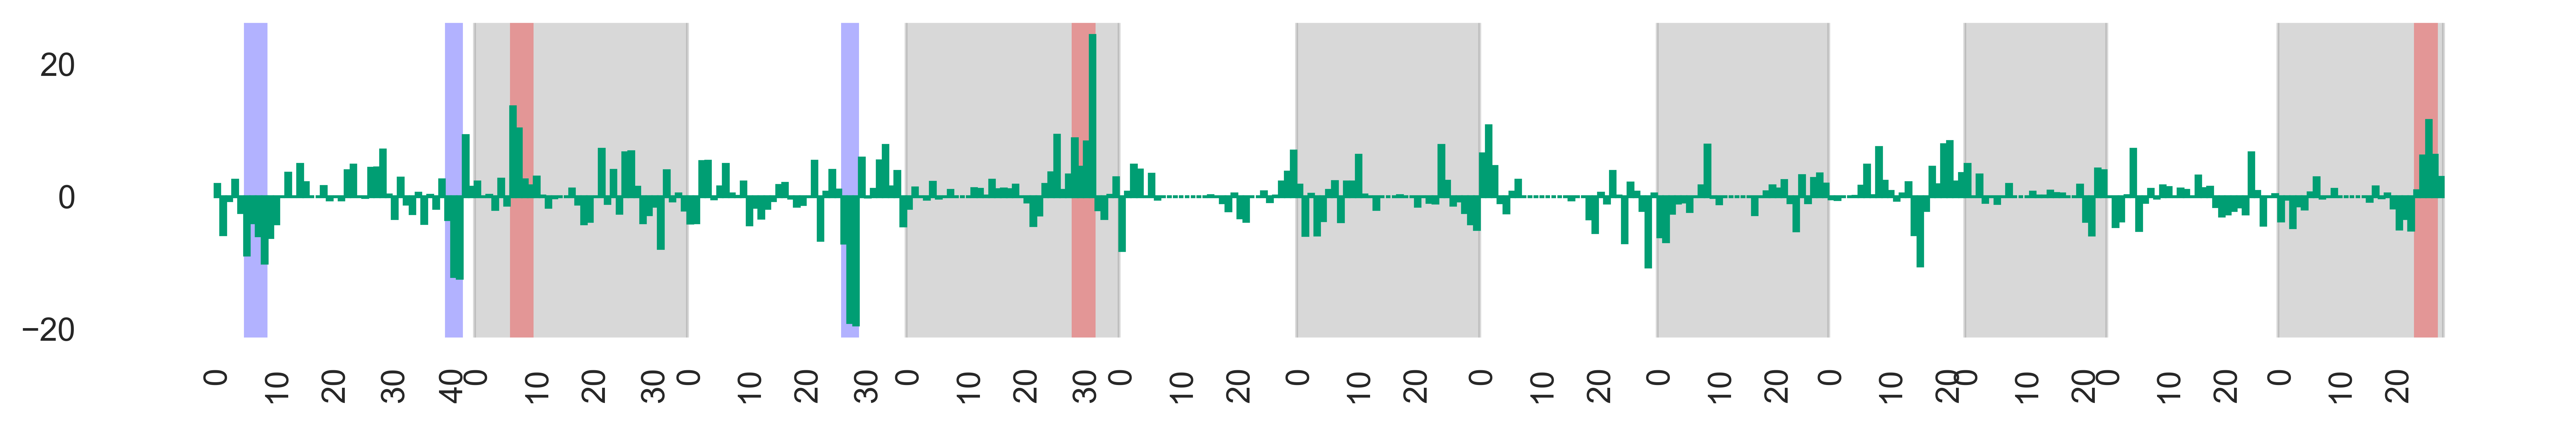

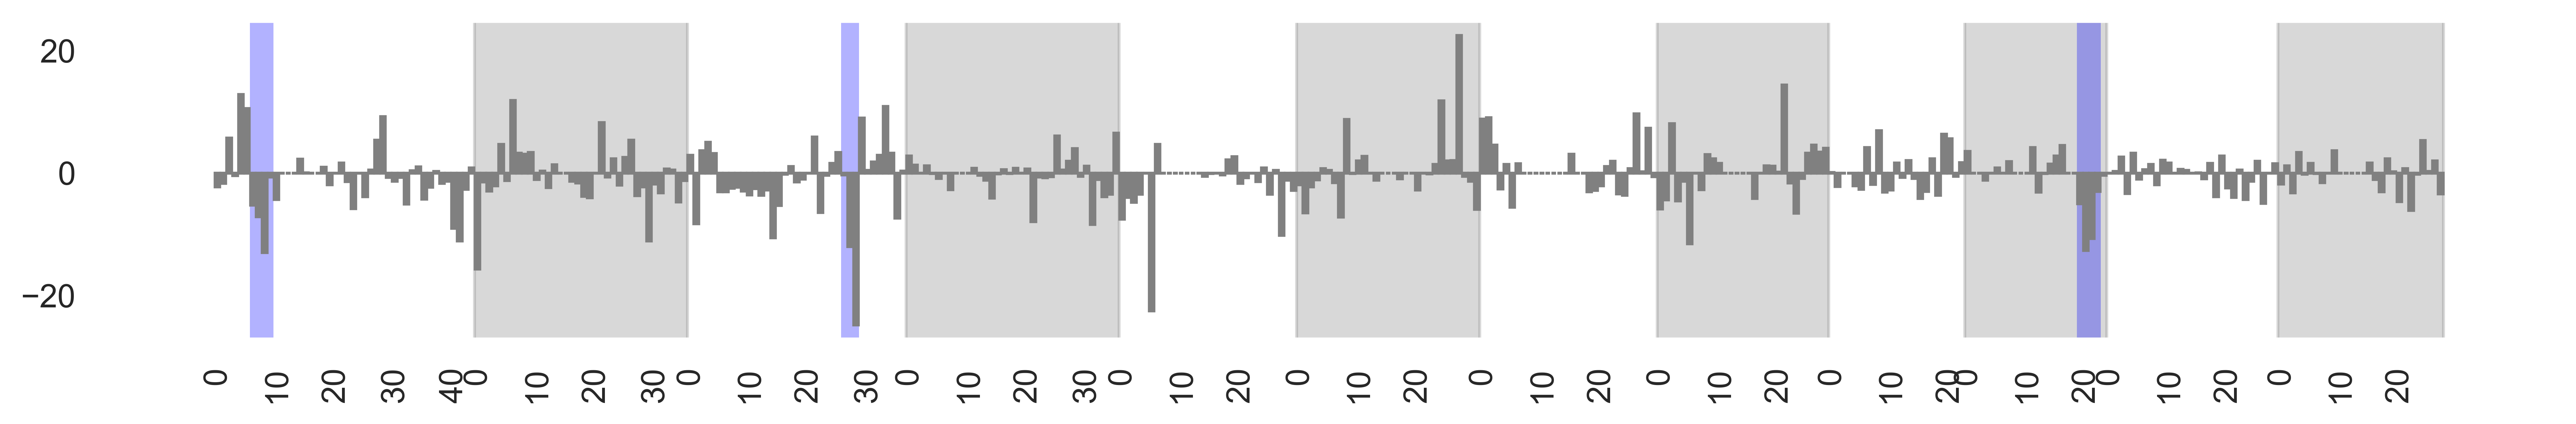

N03


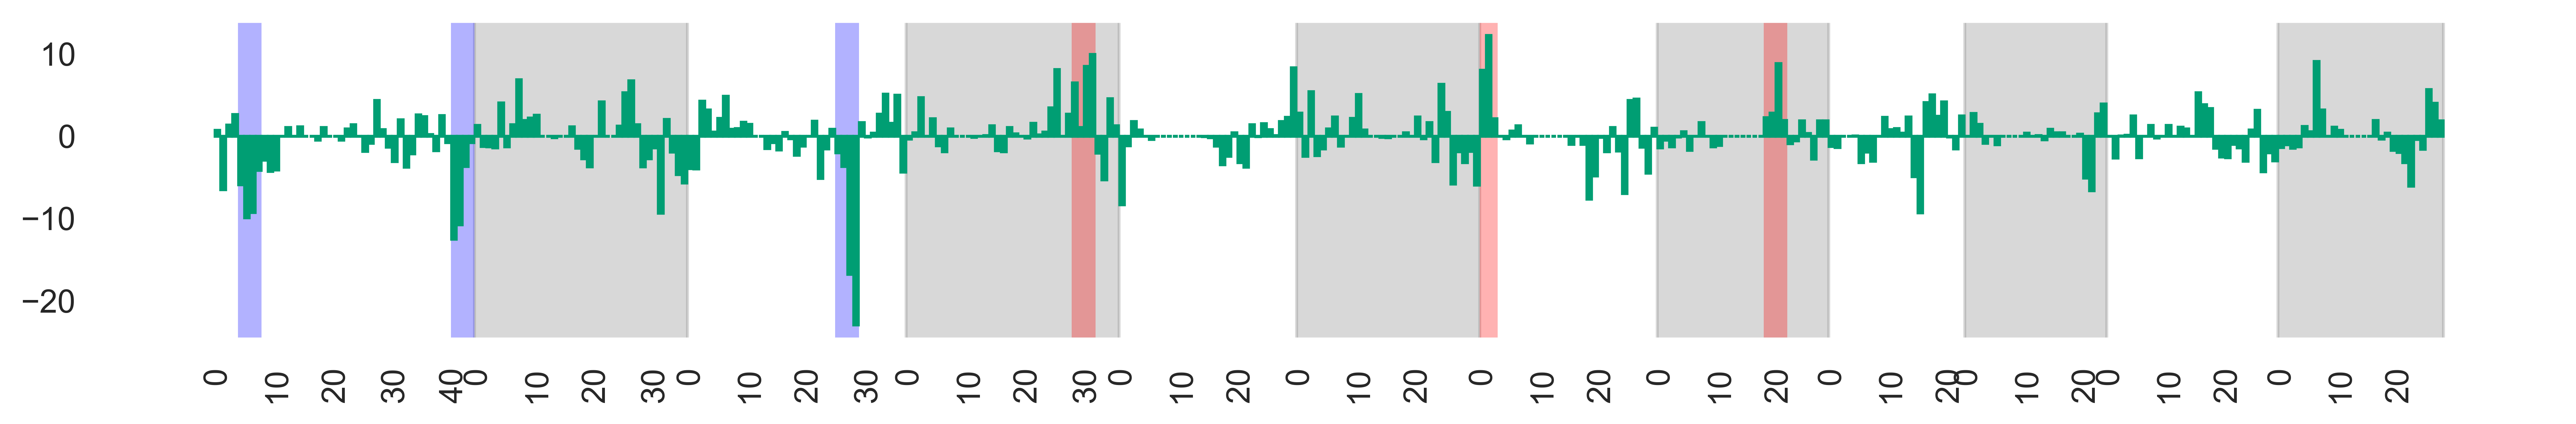

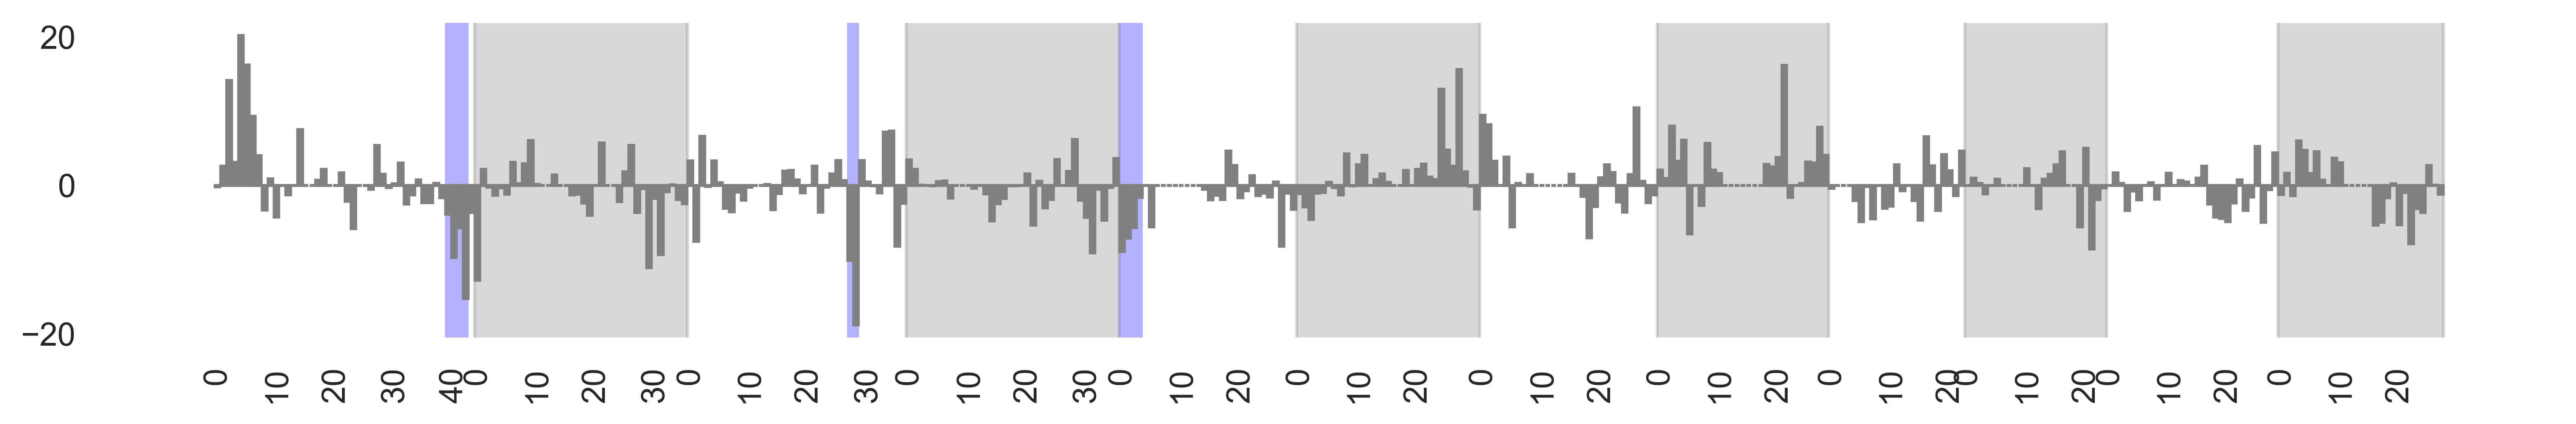

N04


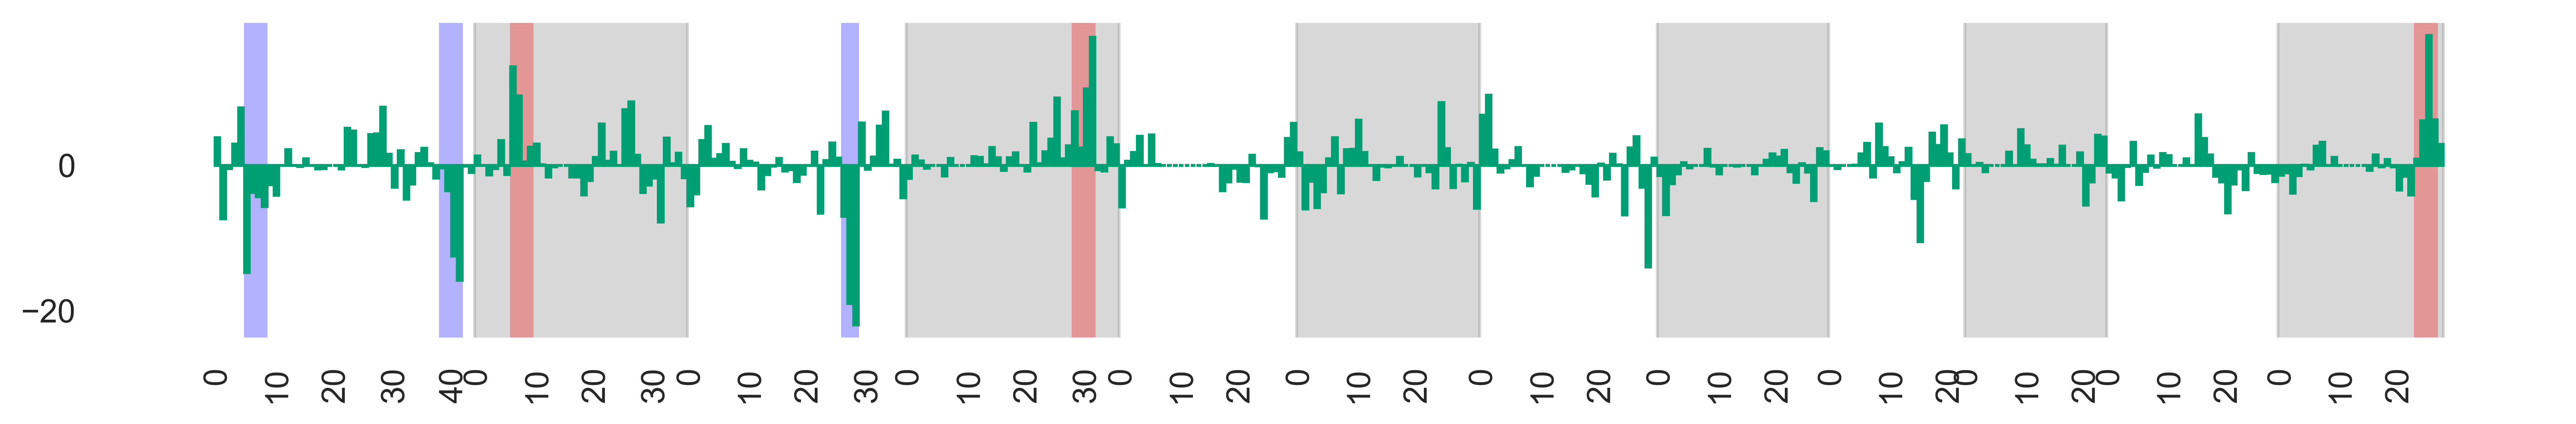

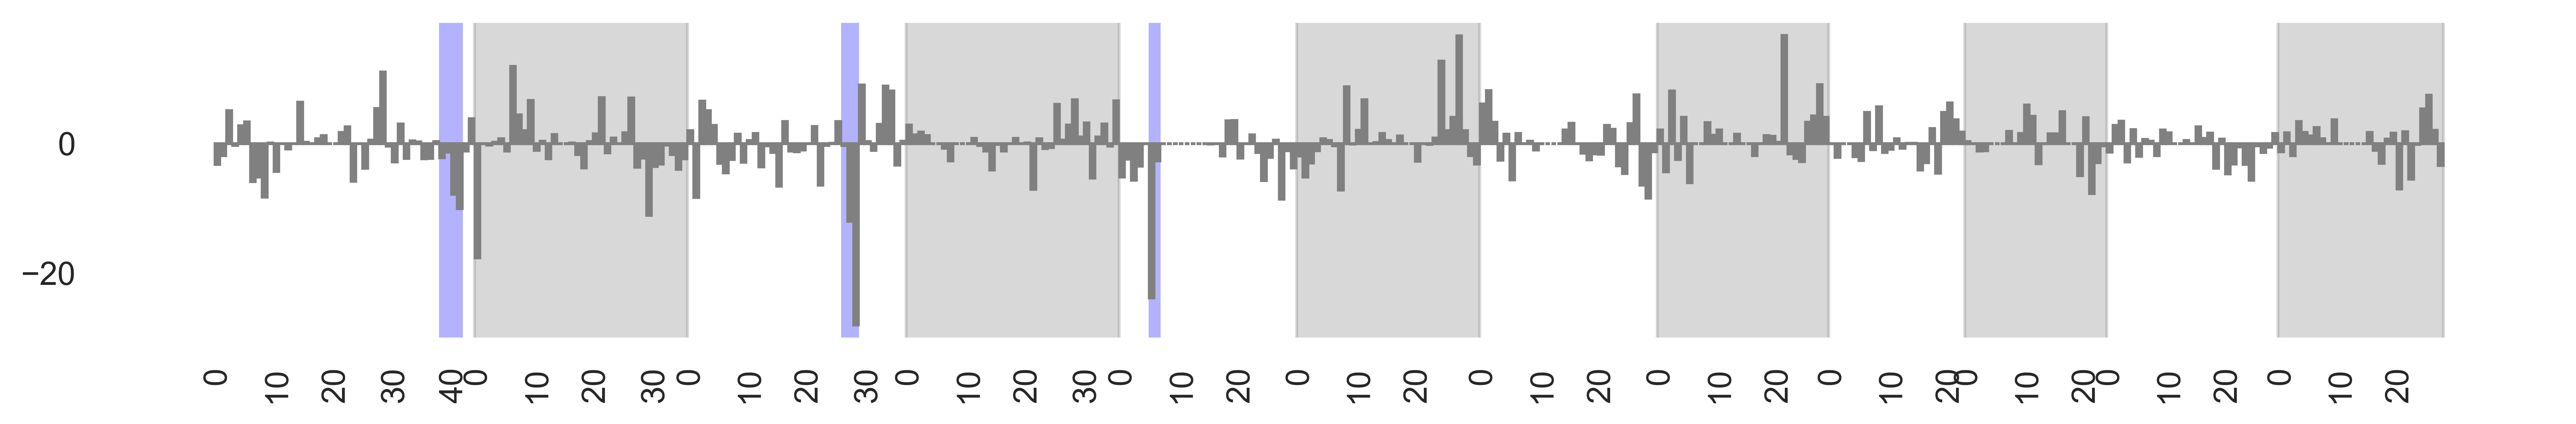

N05


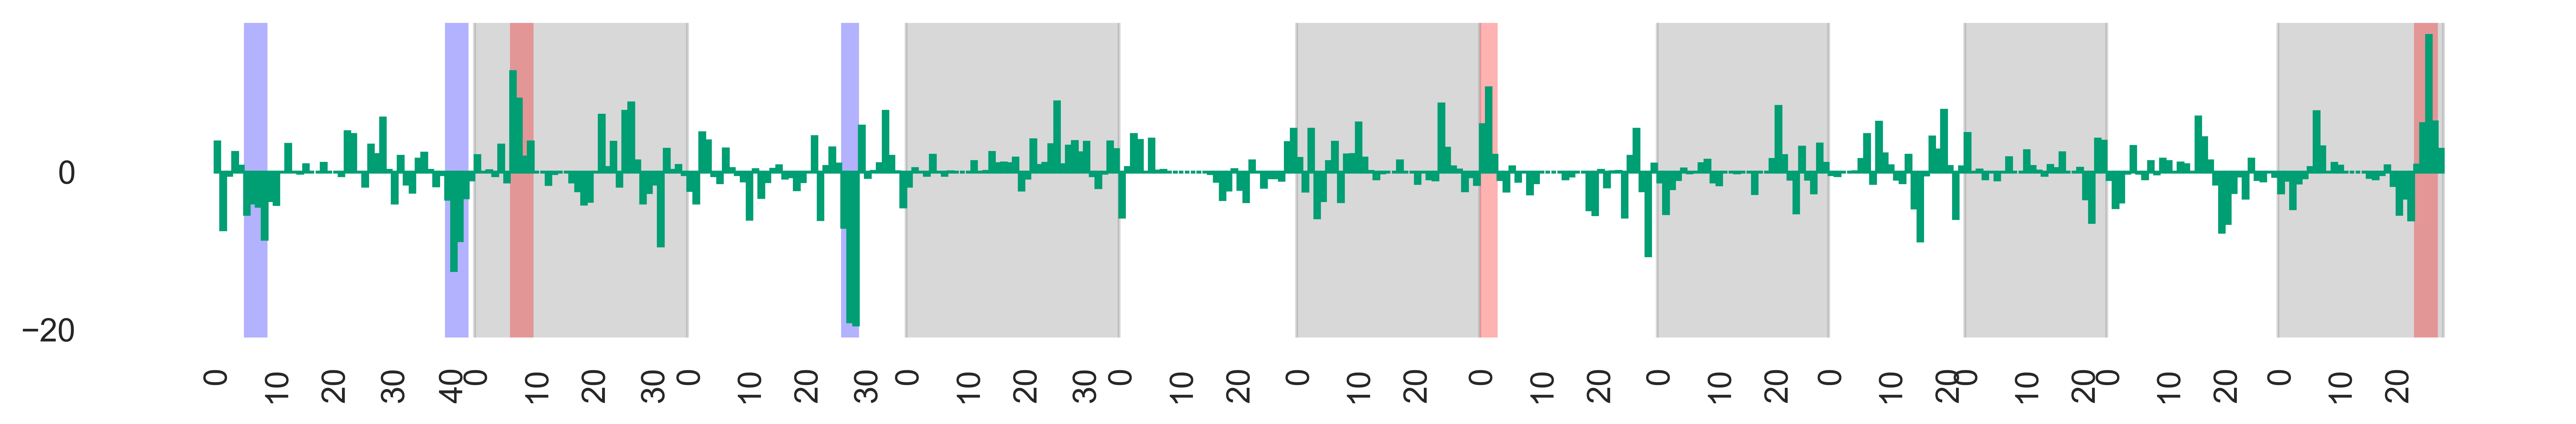

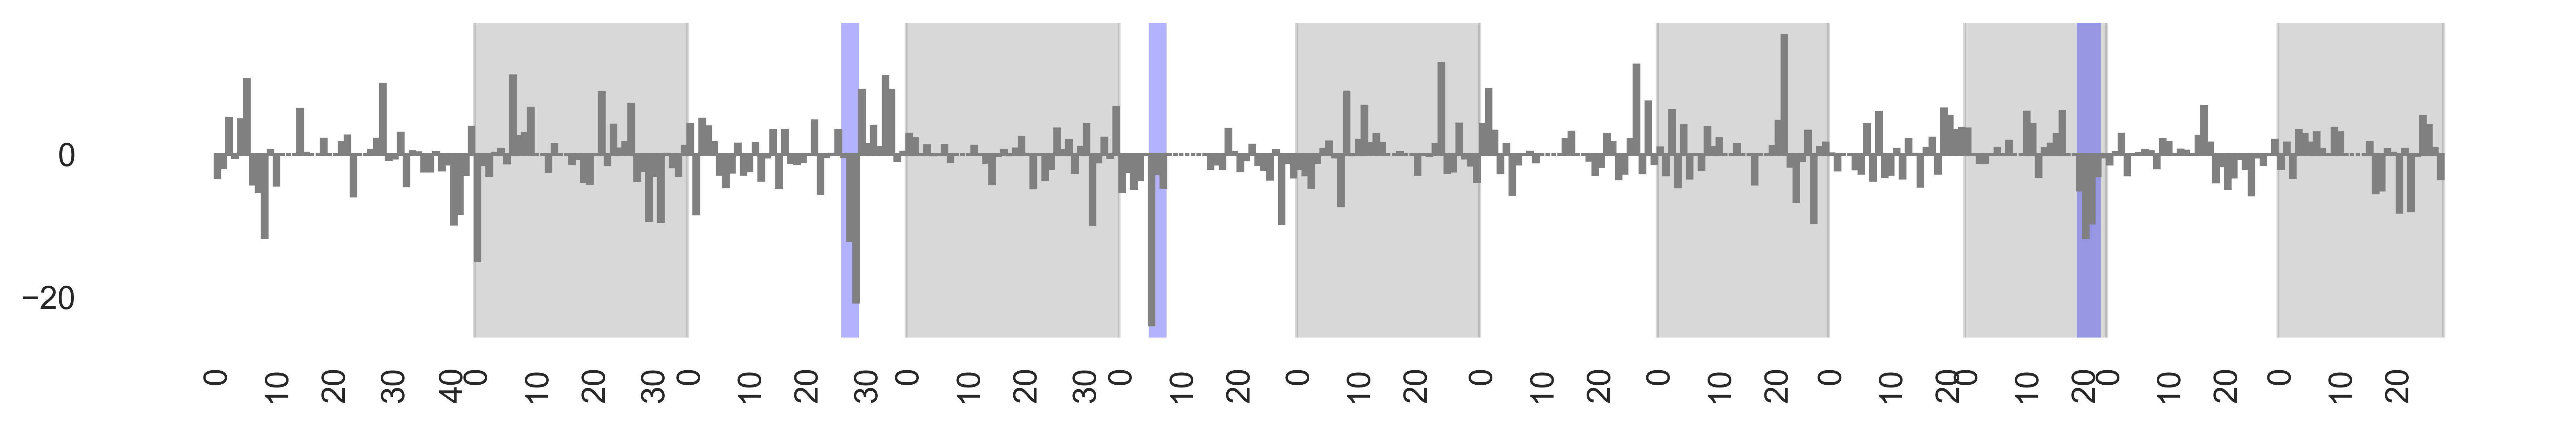

N06


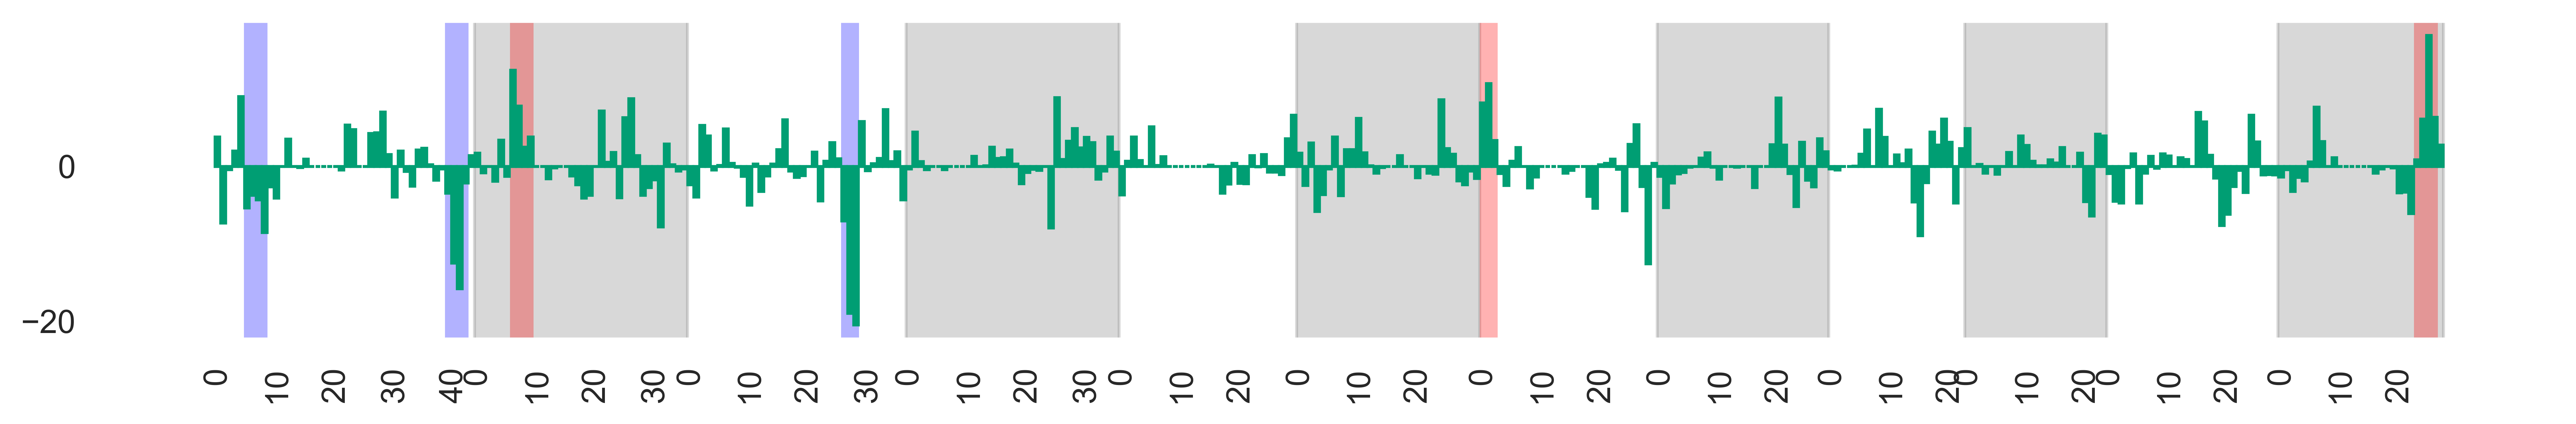

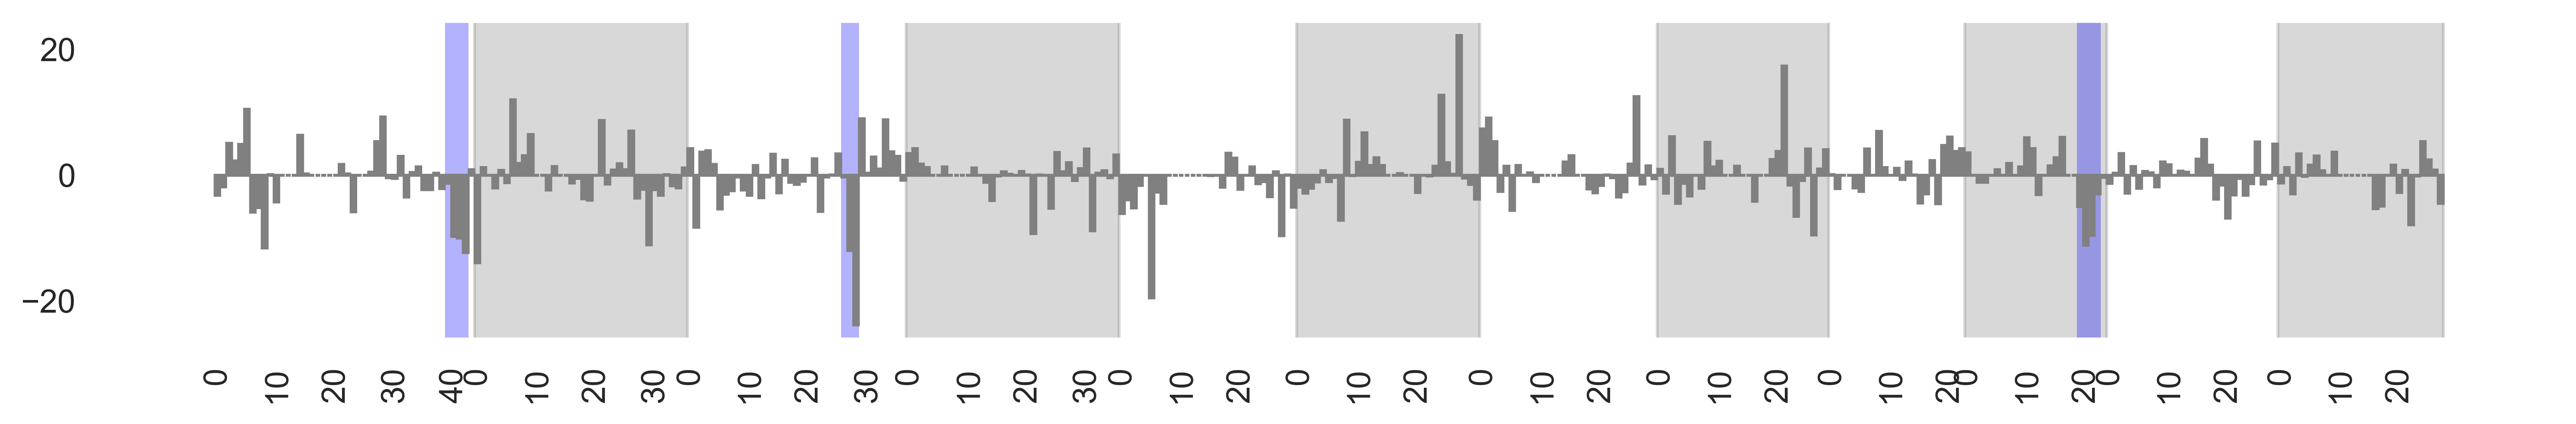

N07


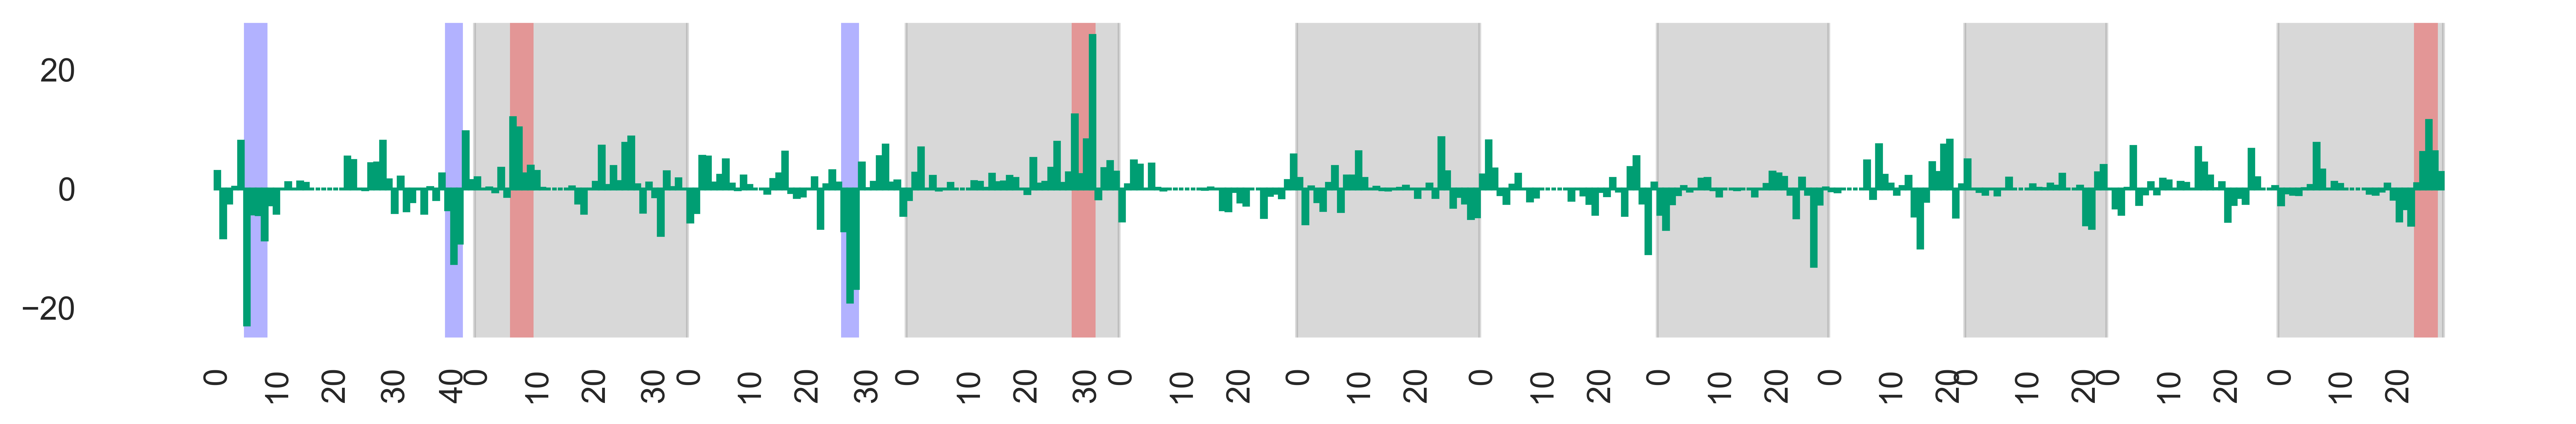

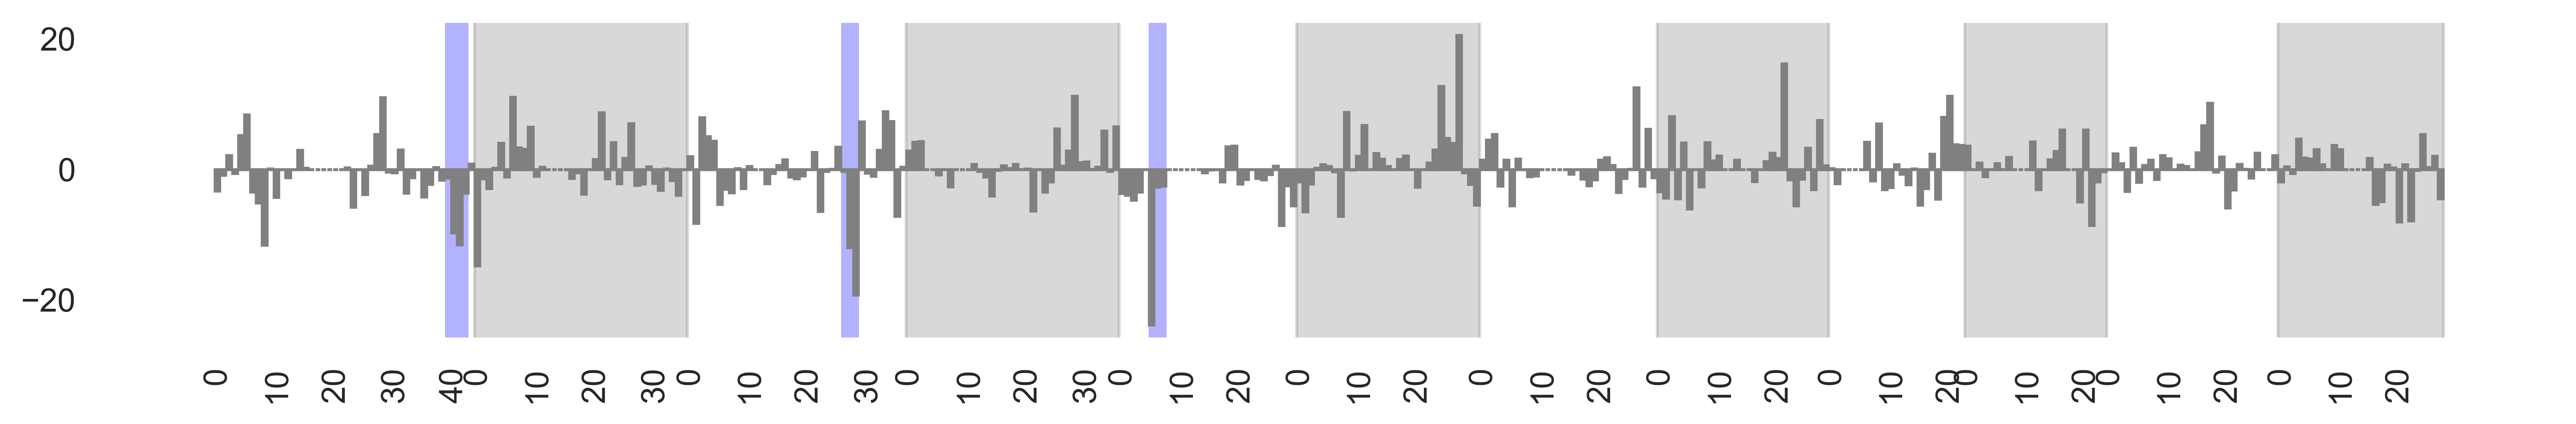

N08


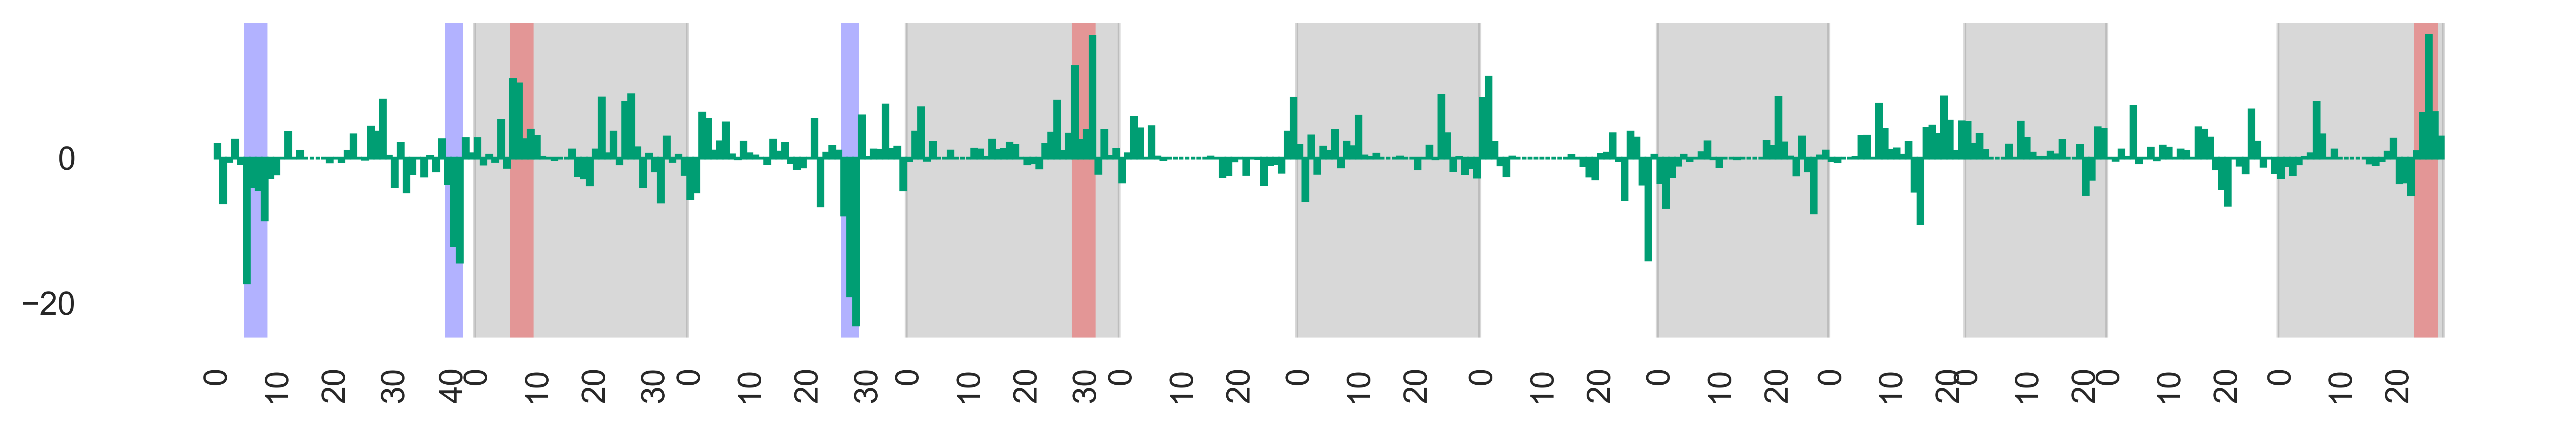

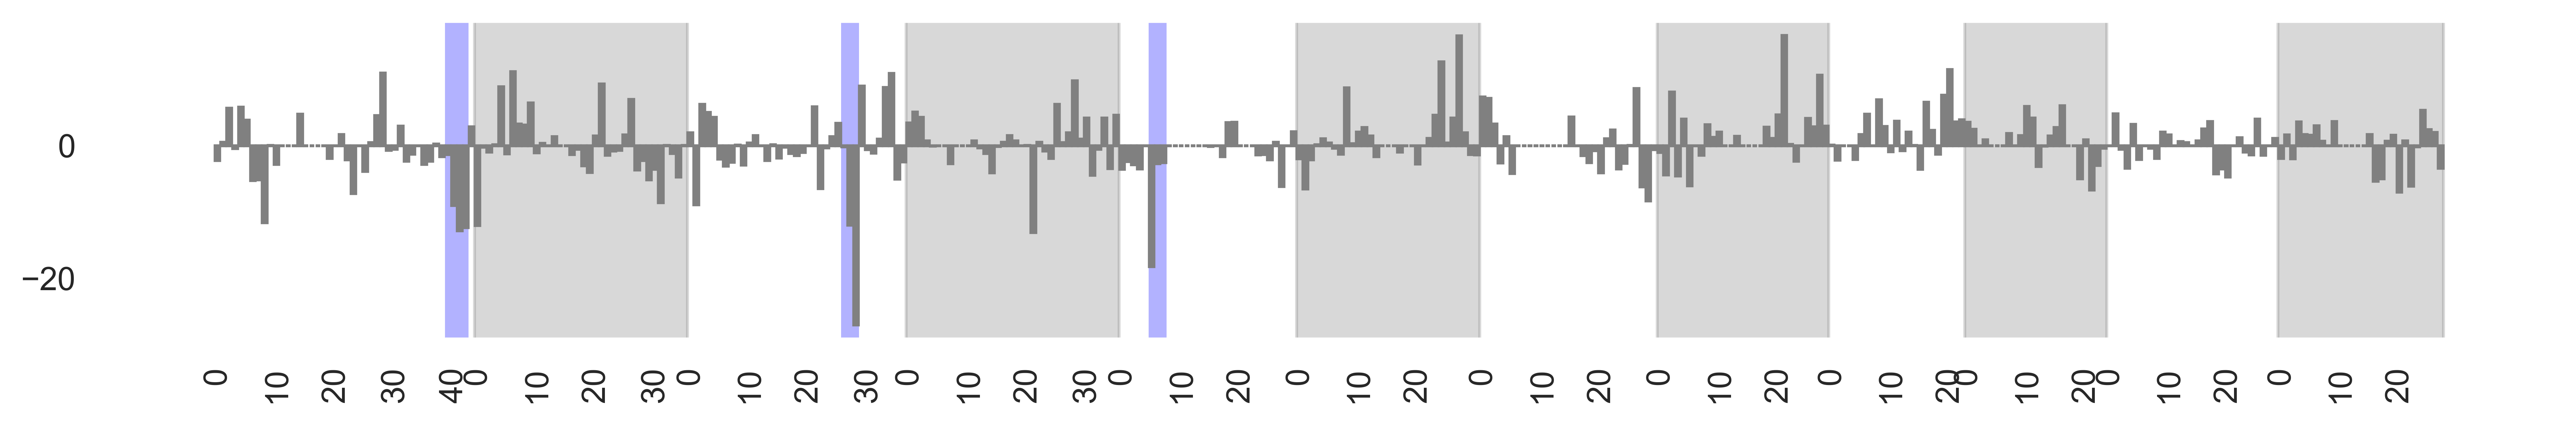

N09


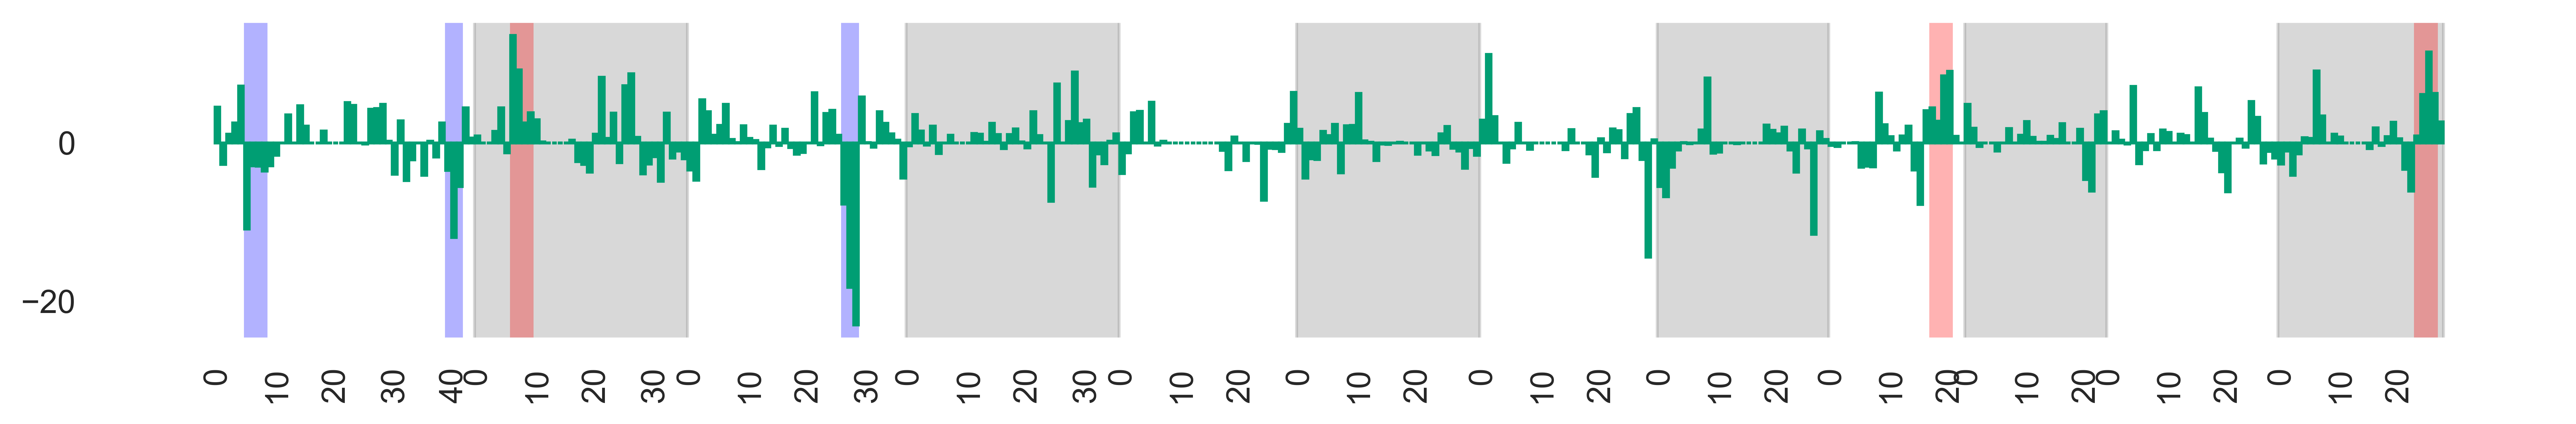

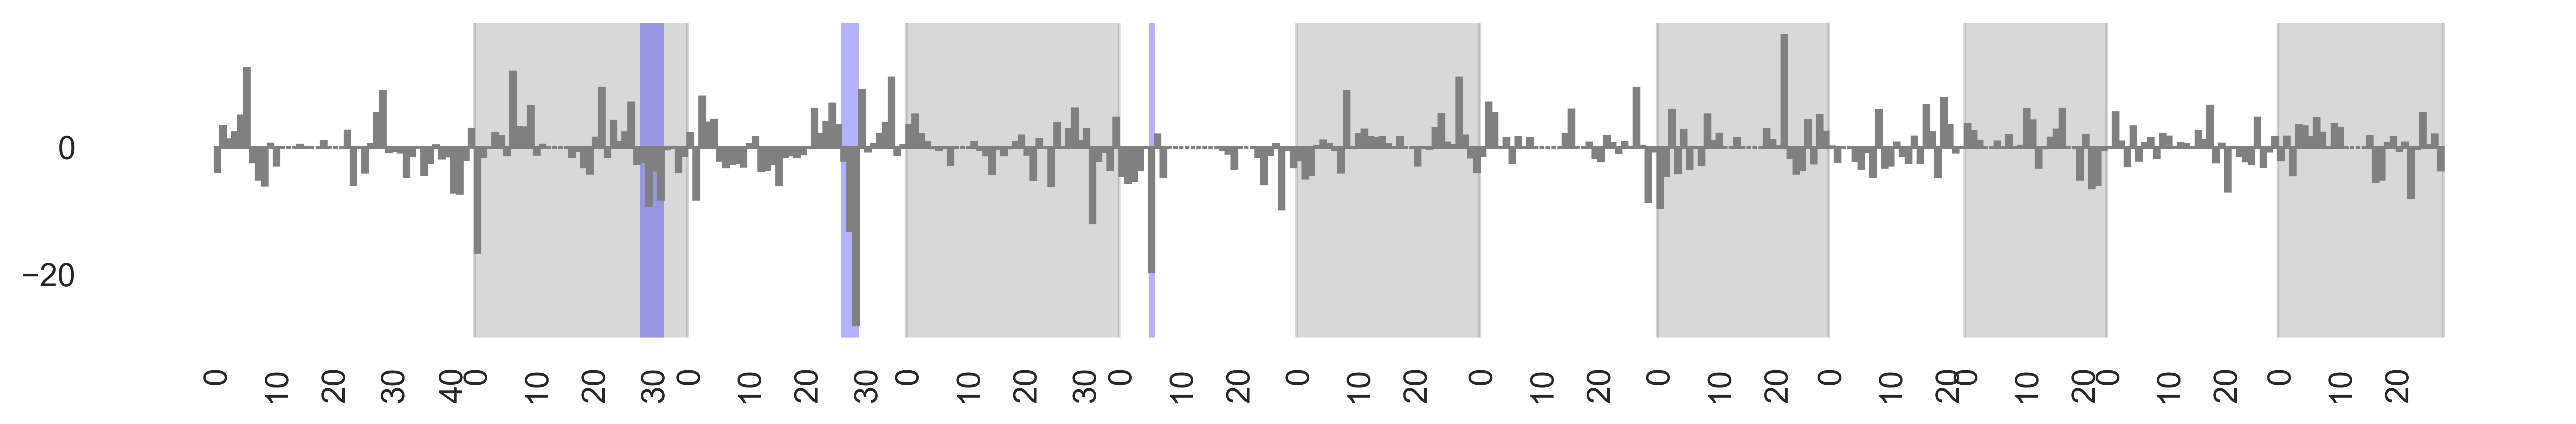

N10


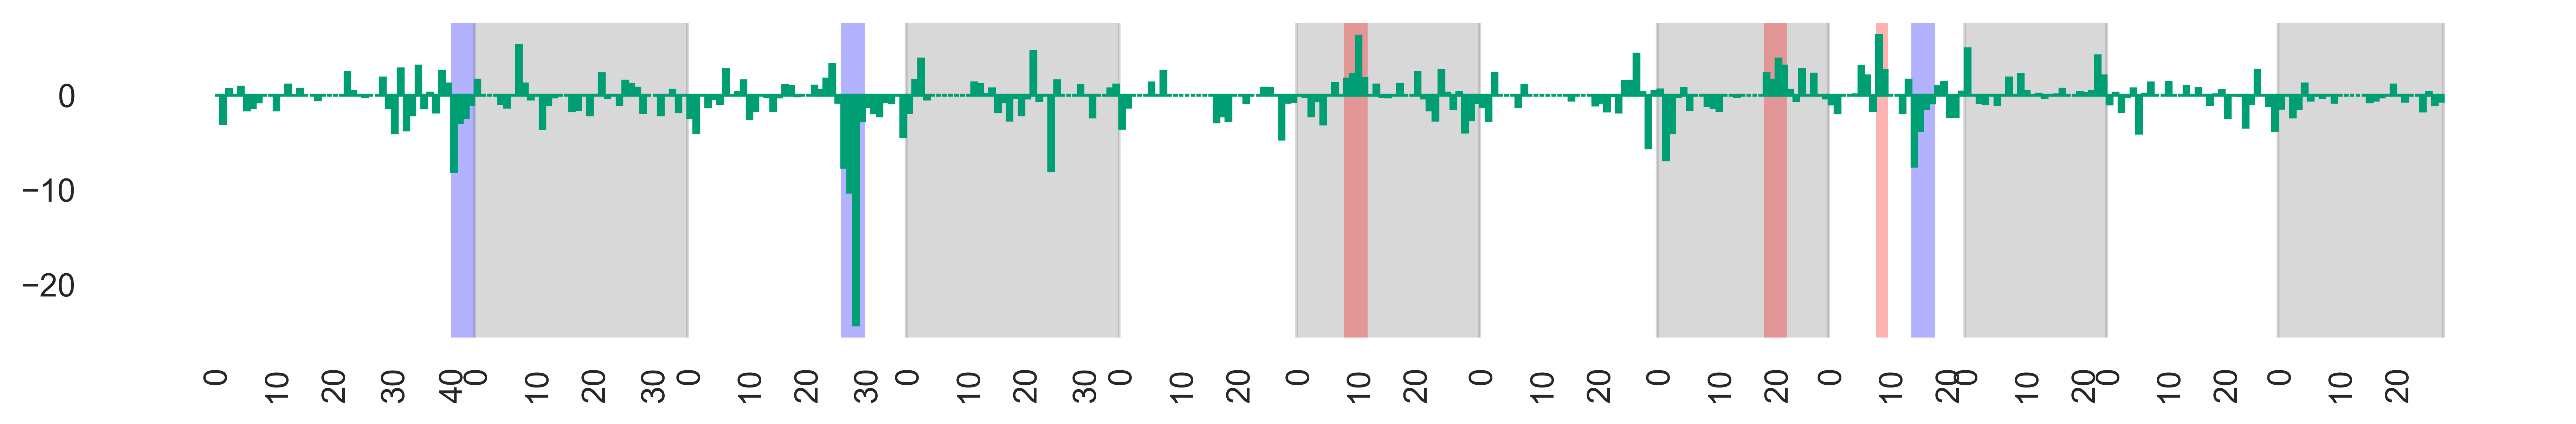

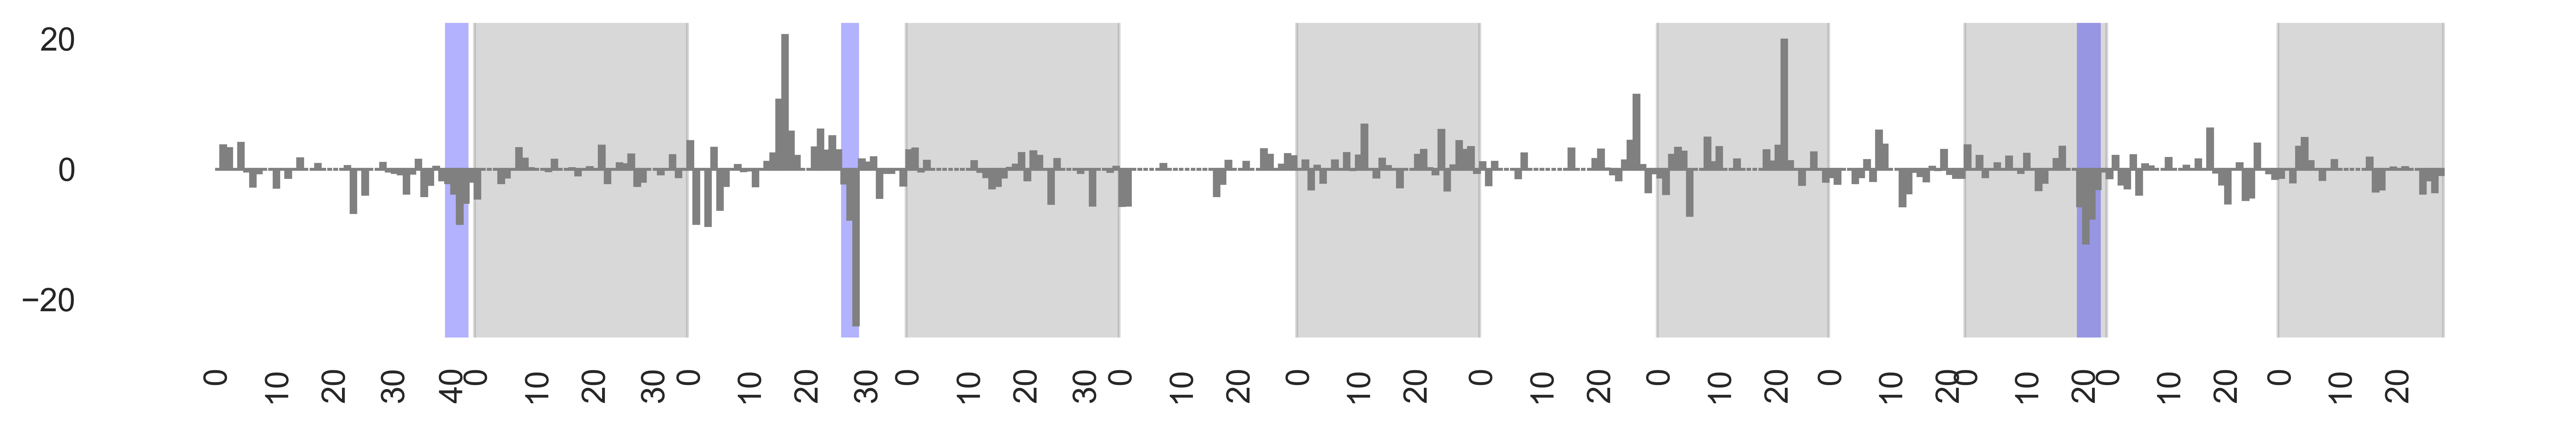

N11


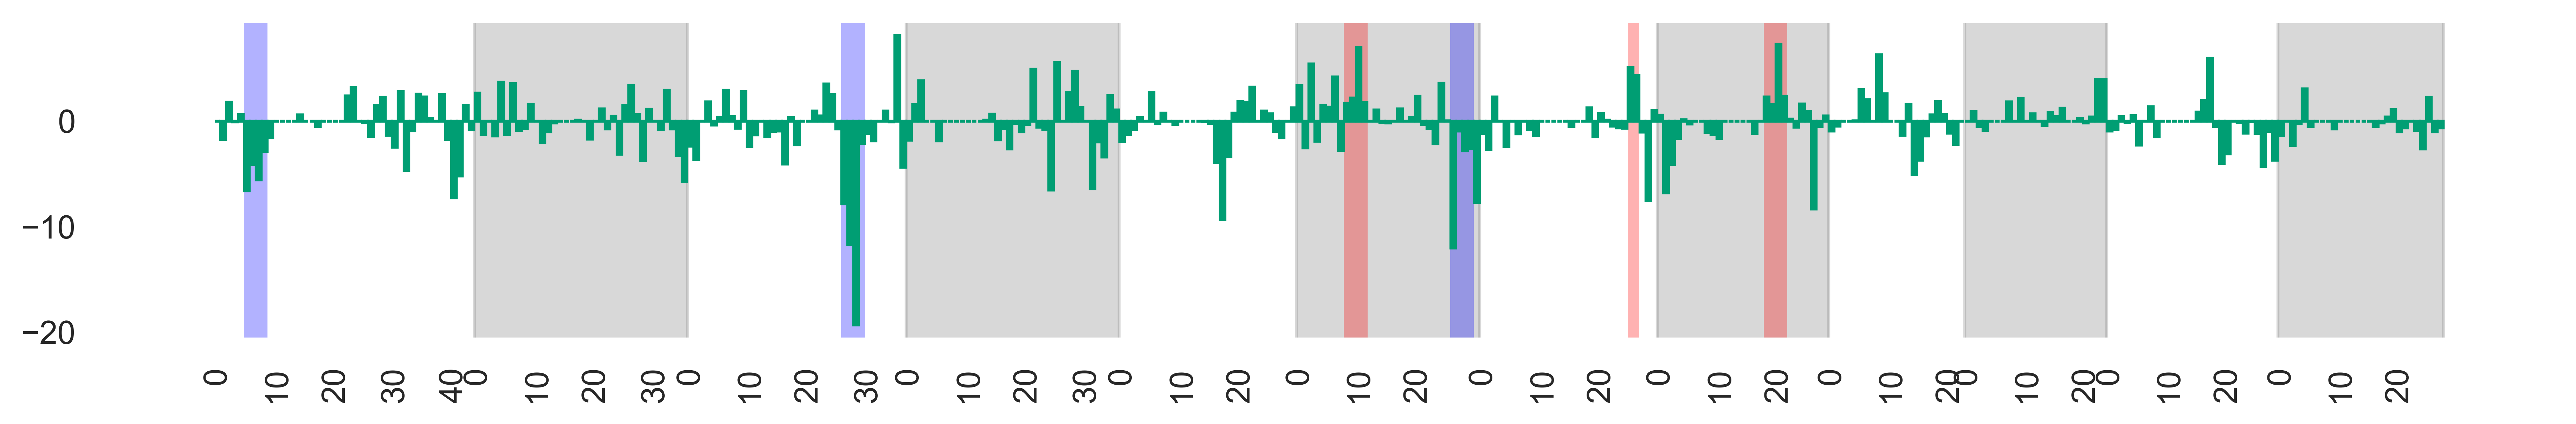

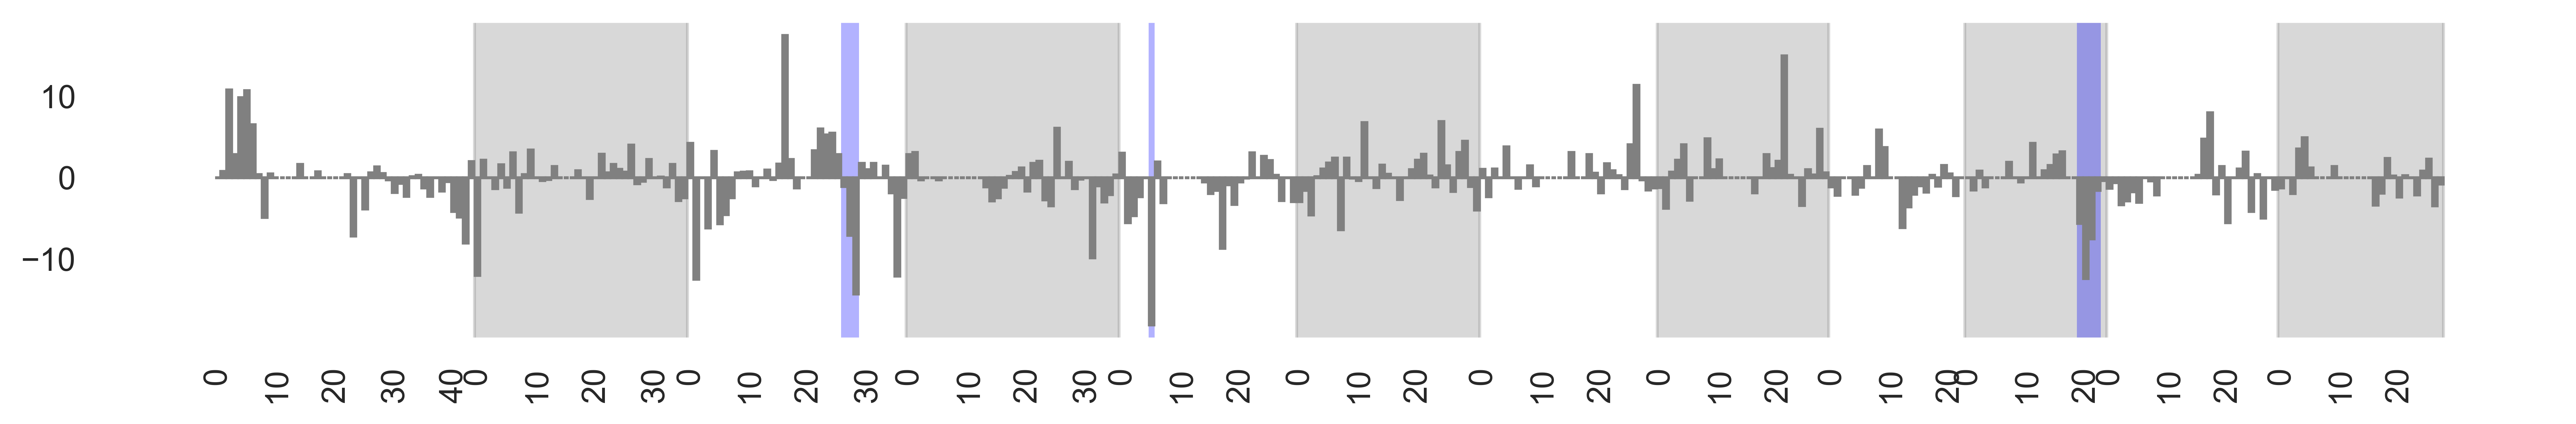

N12


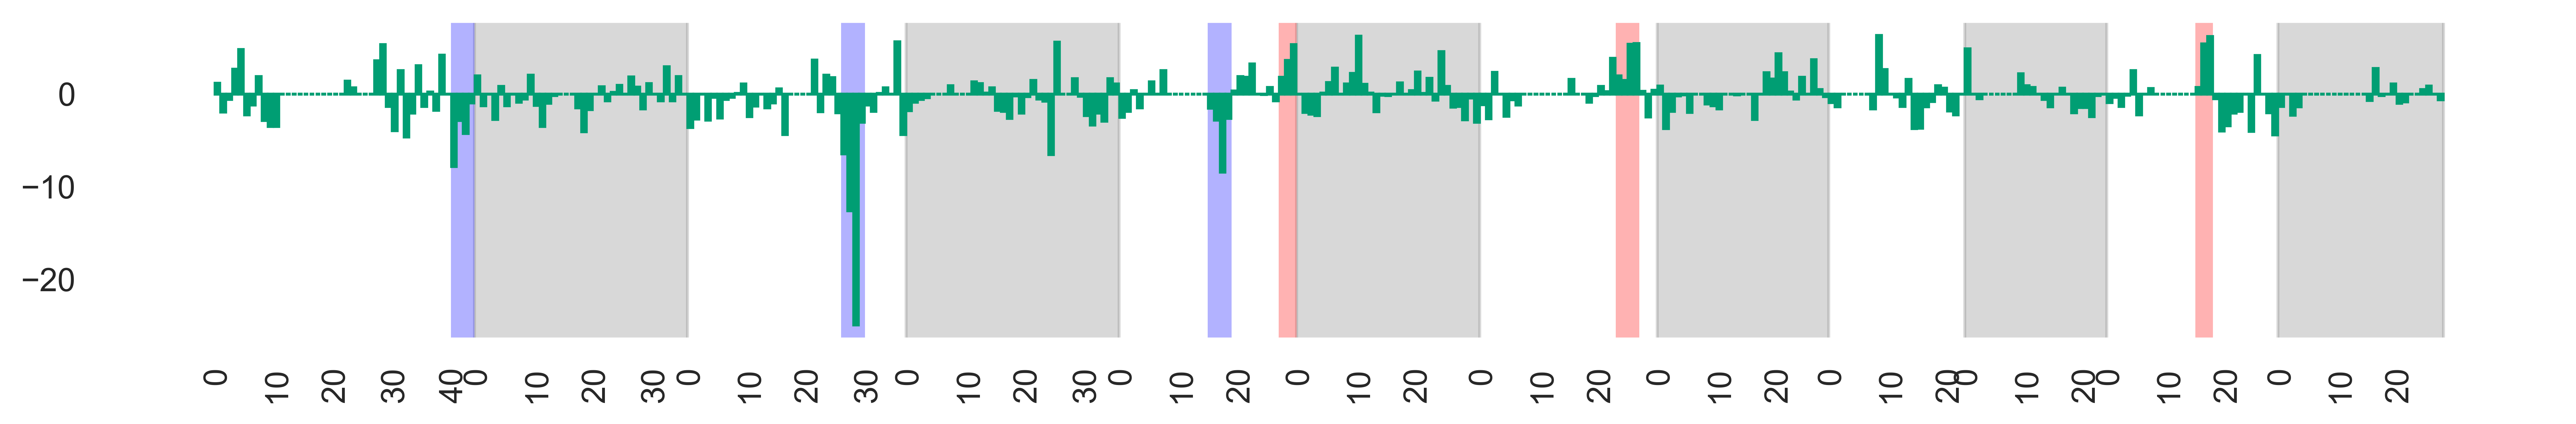

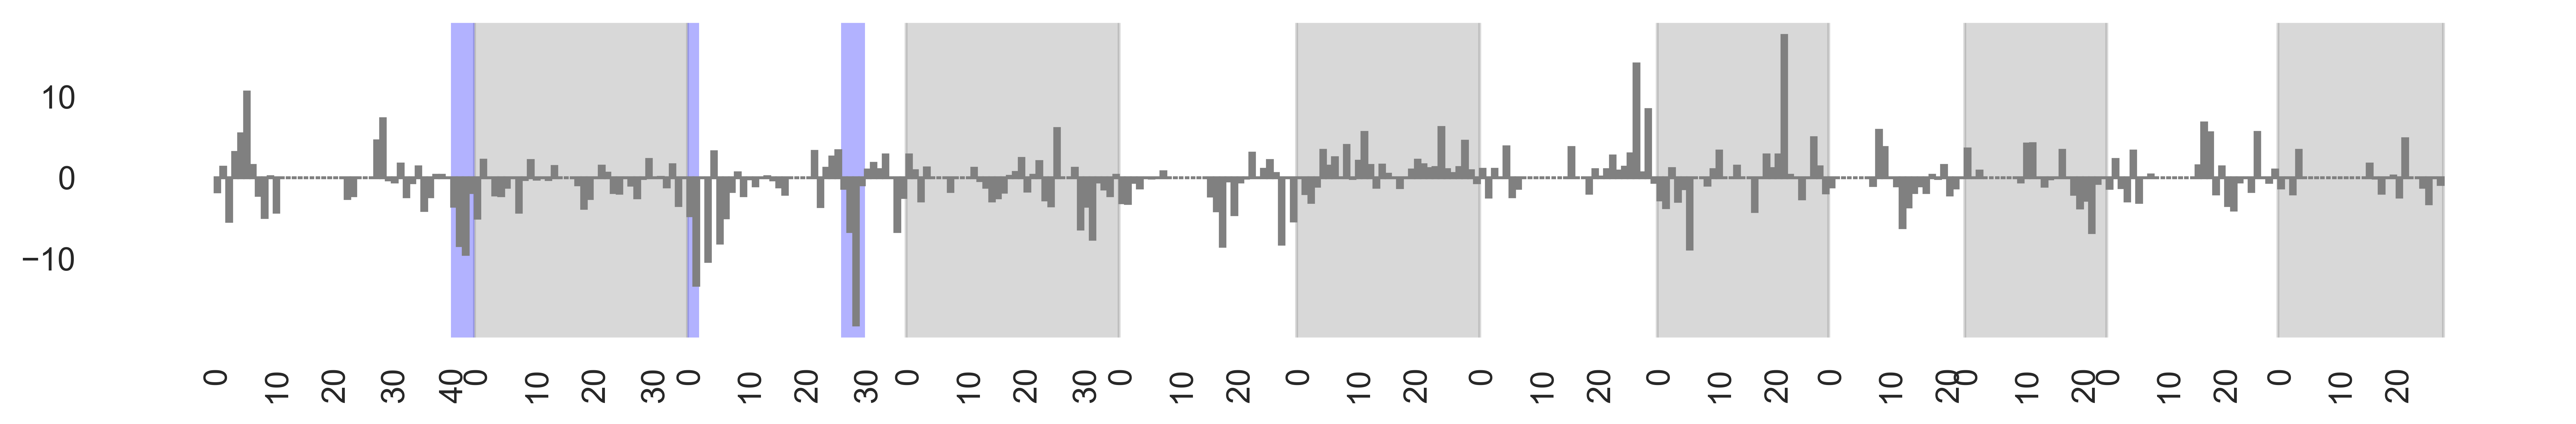

N13


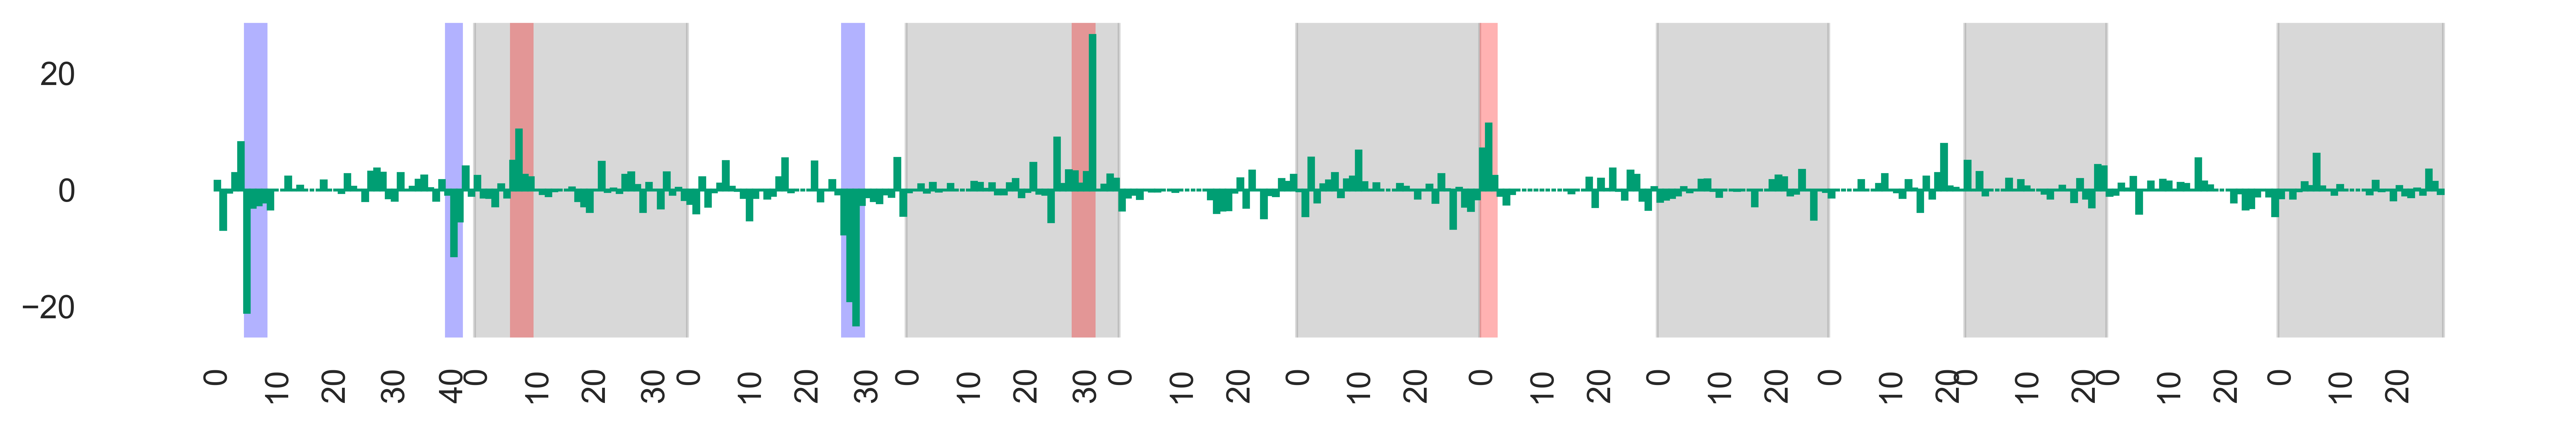

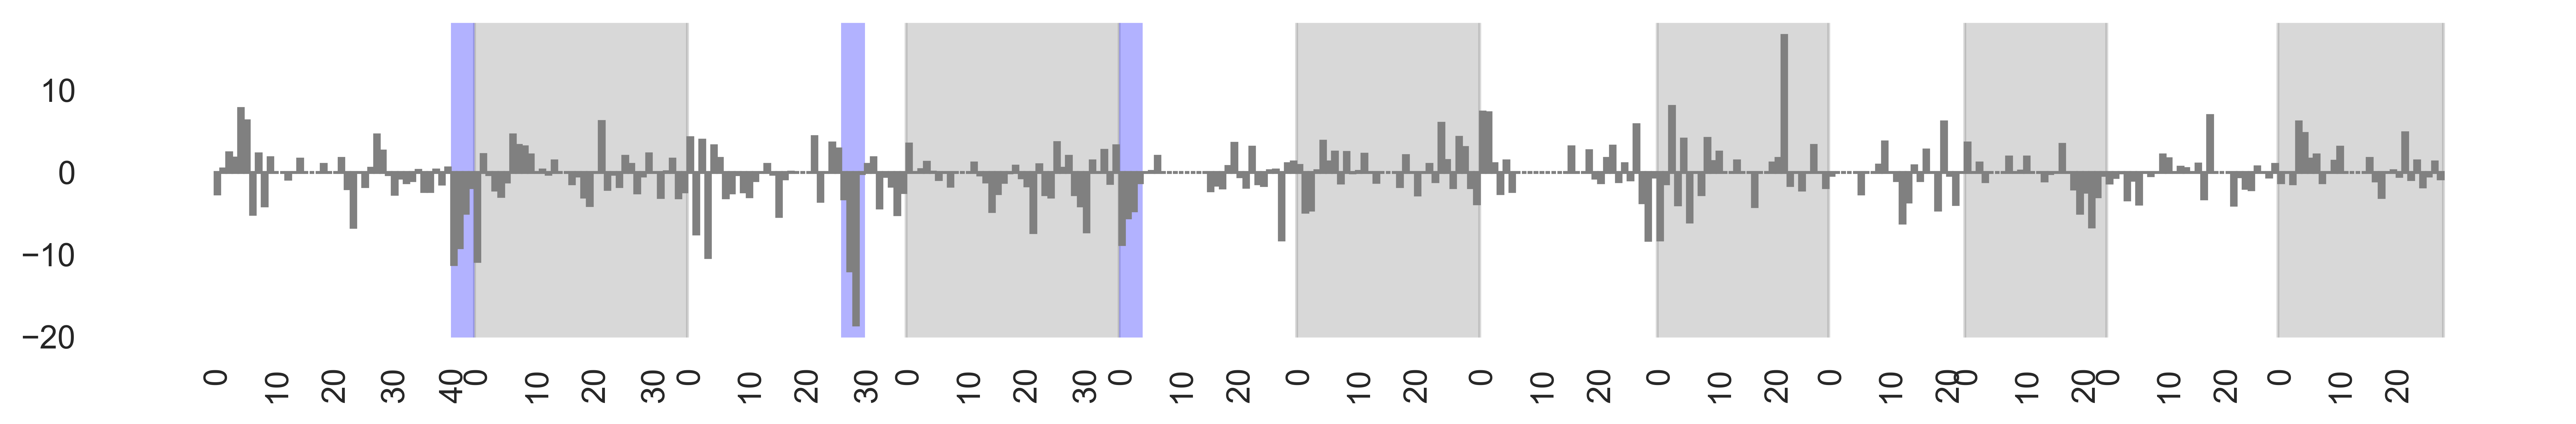

N14


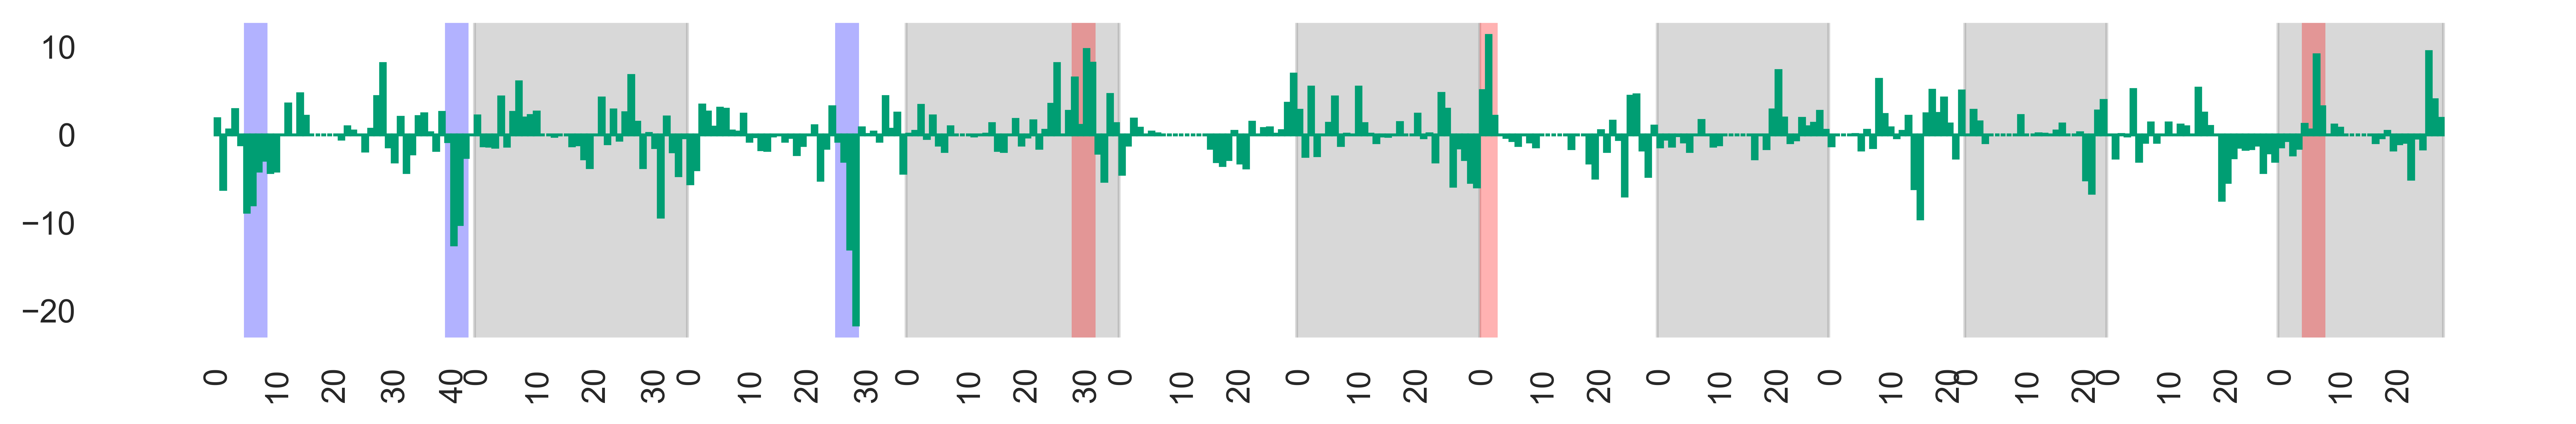

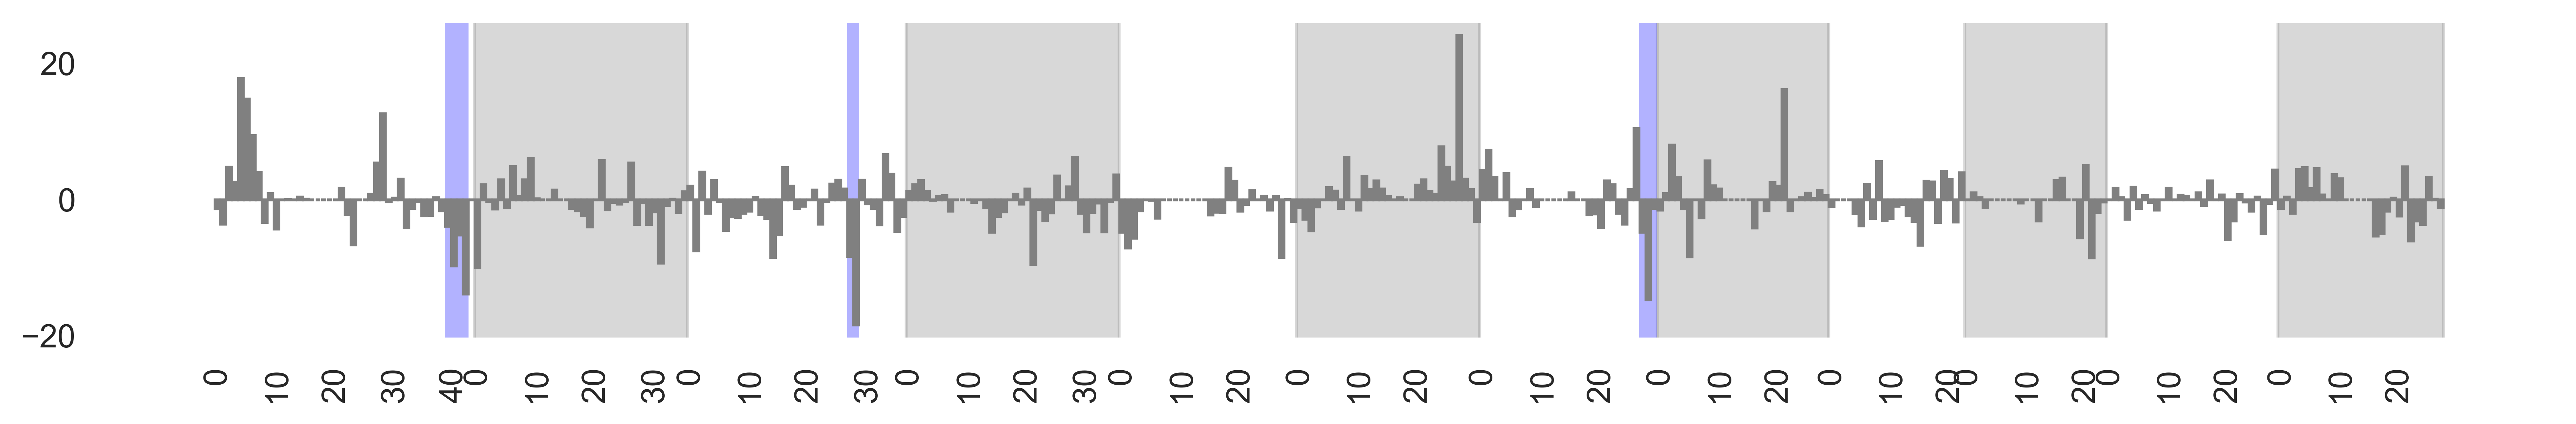

N16


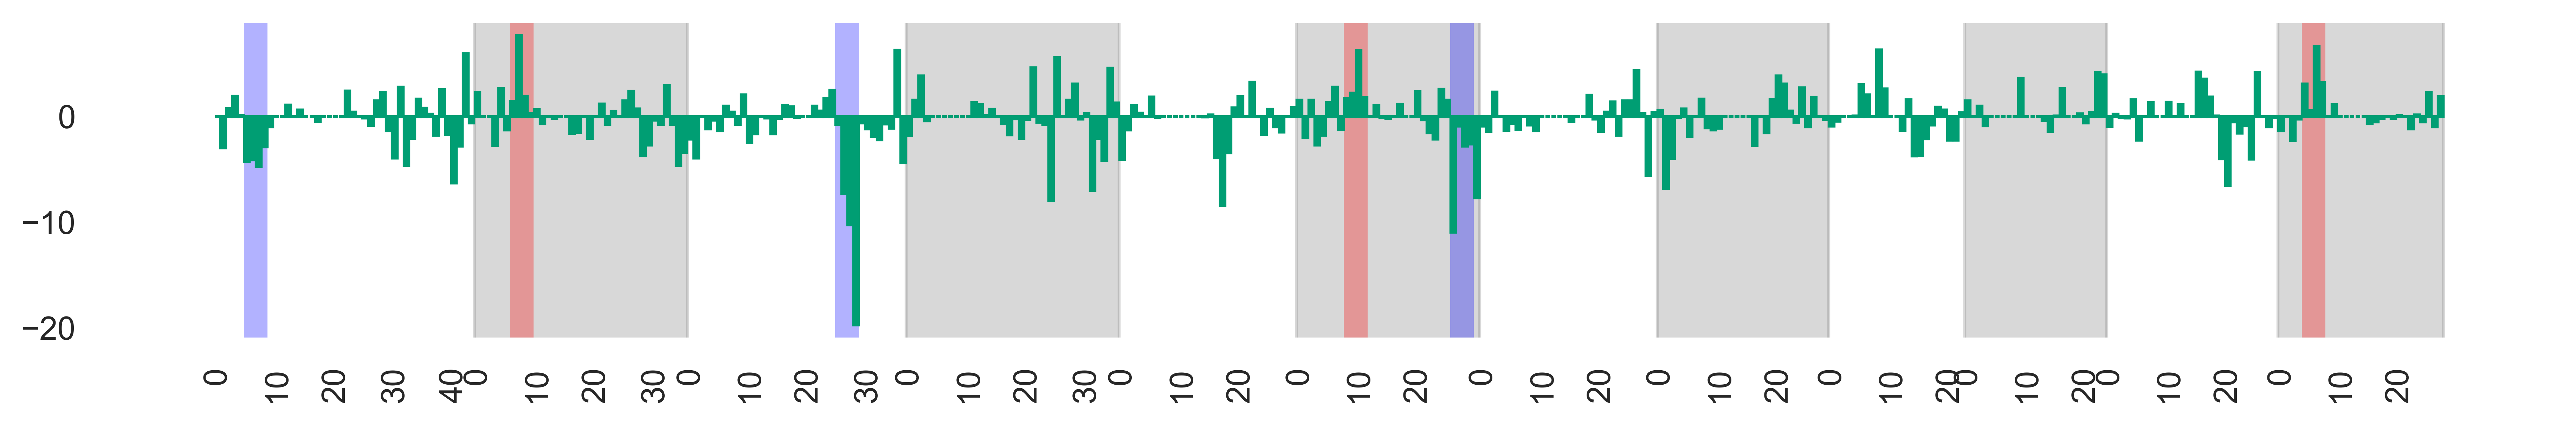

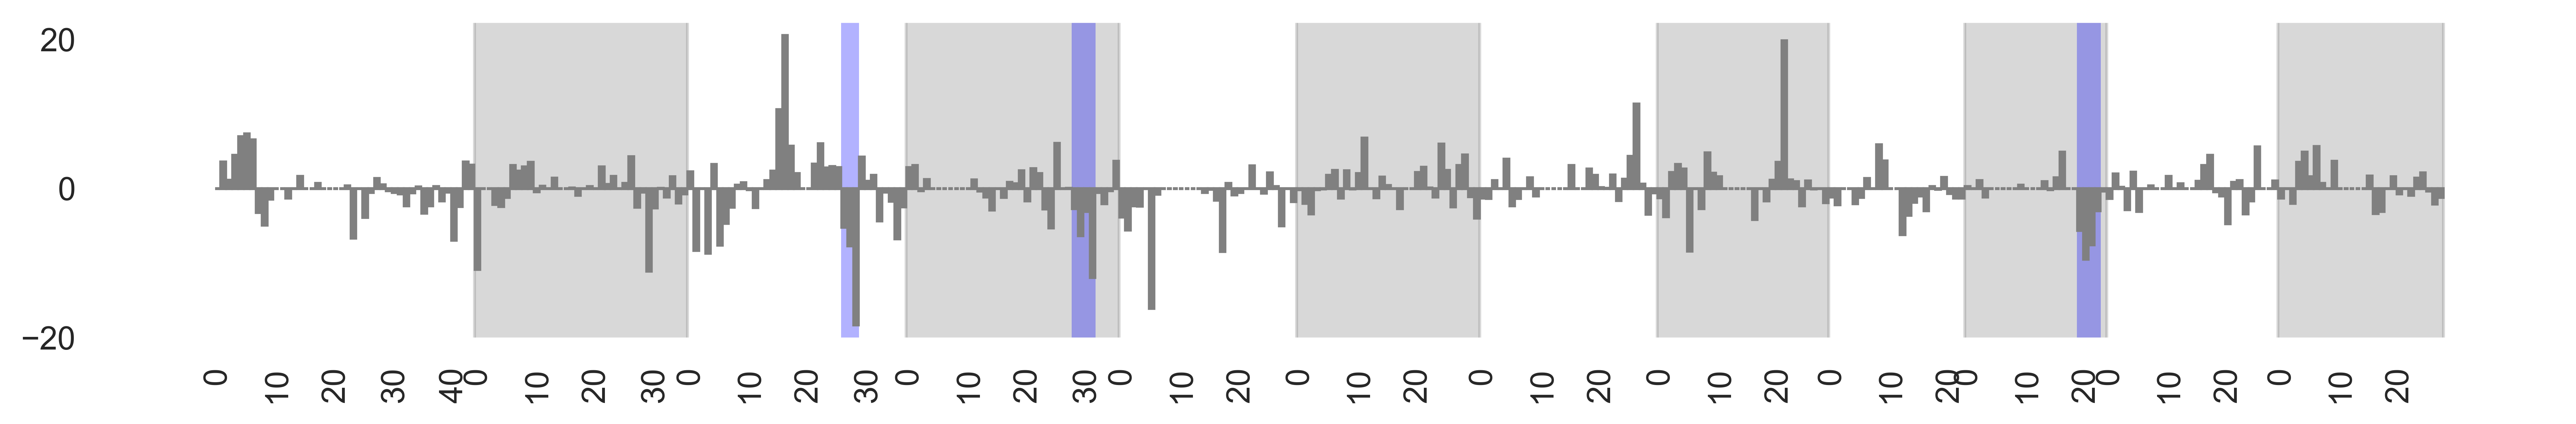

N17


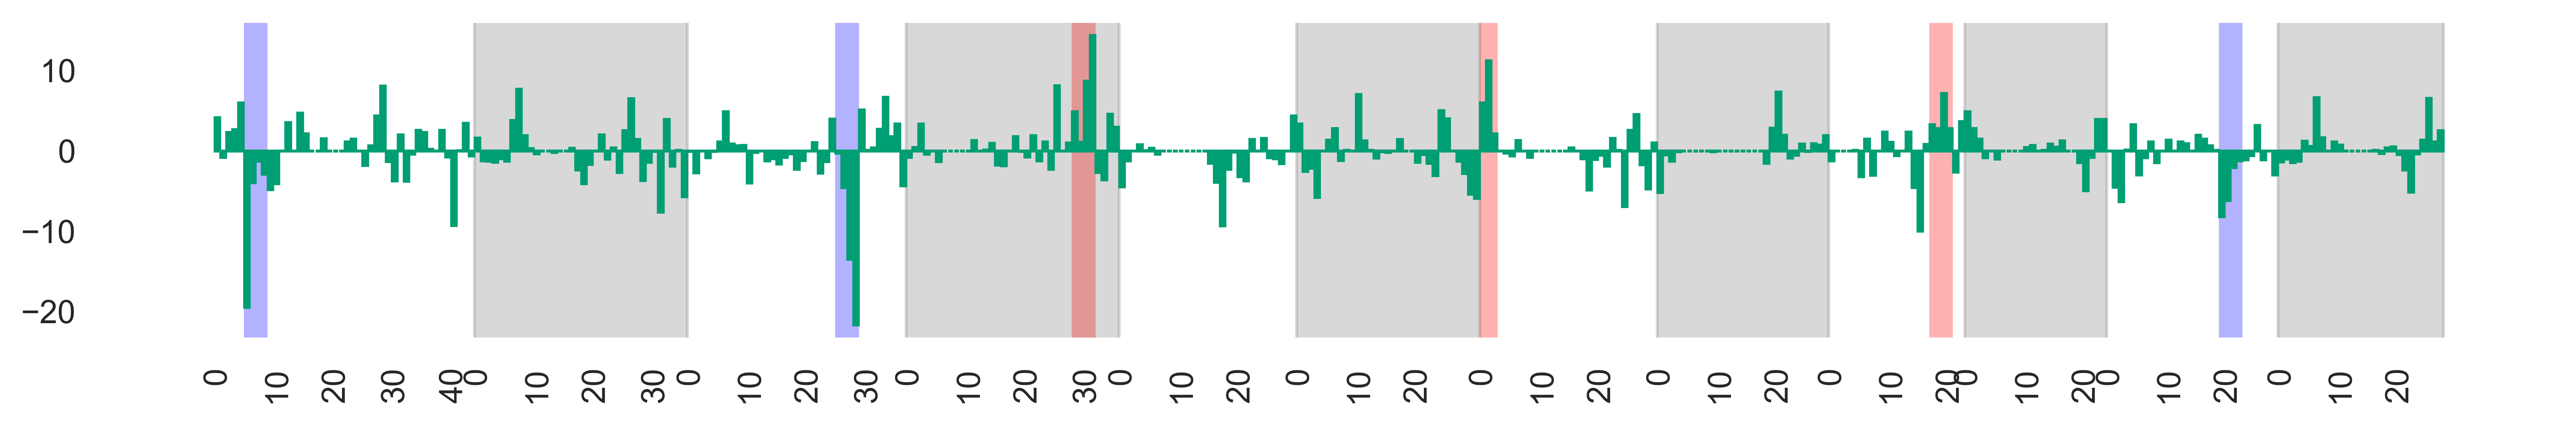

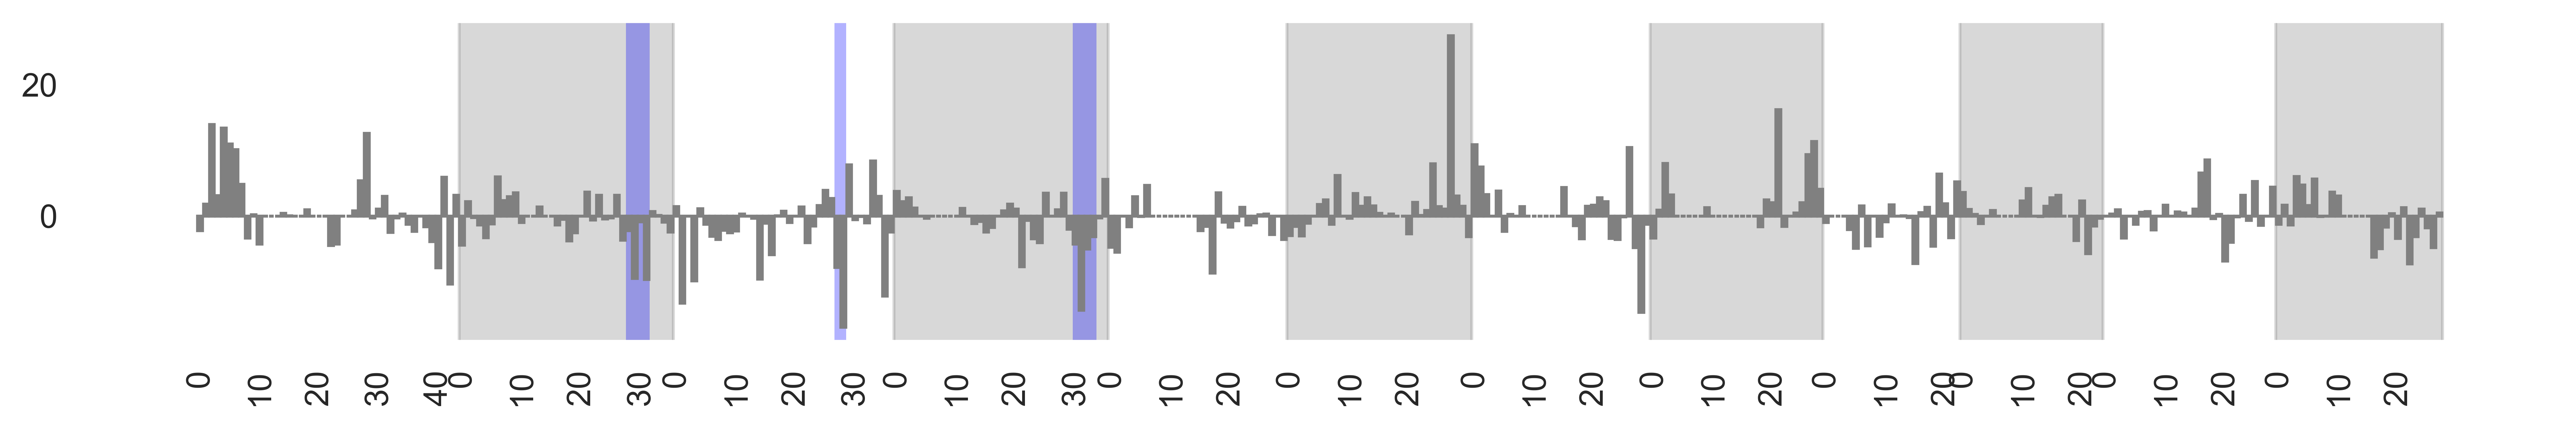

N18


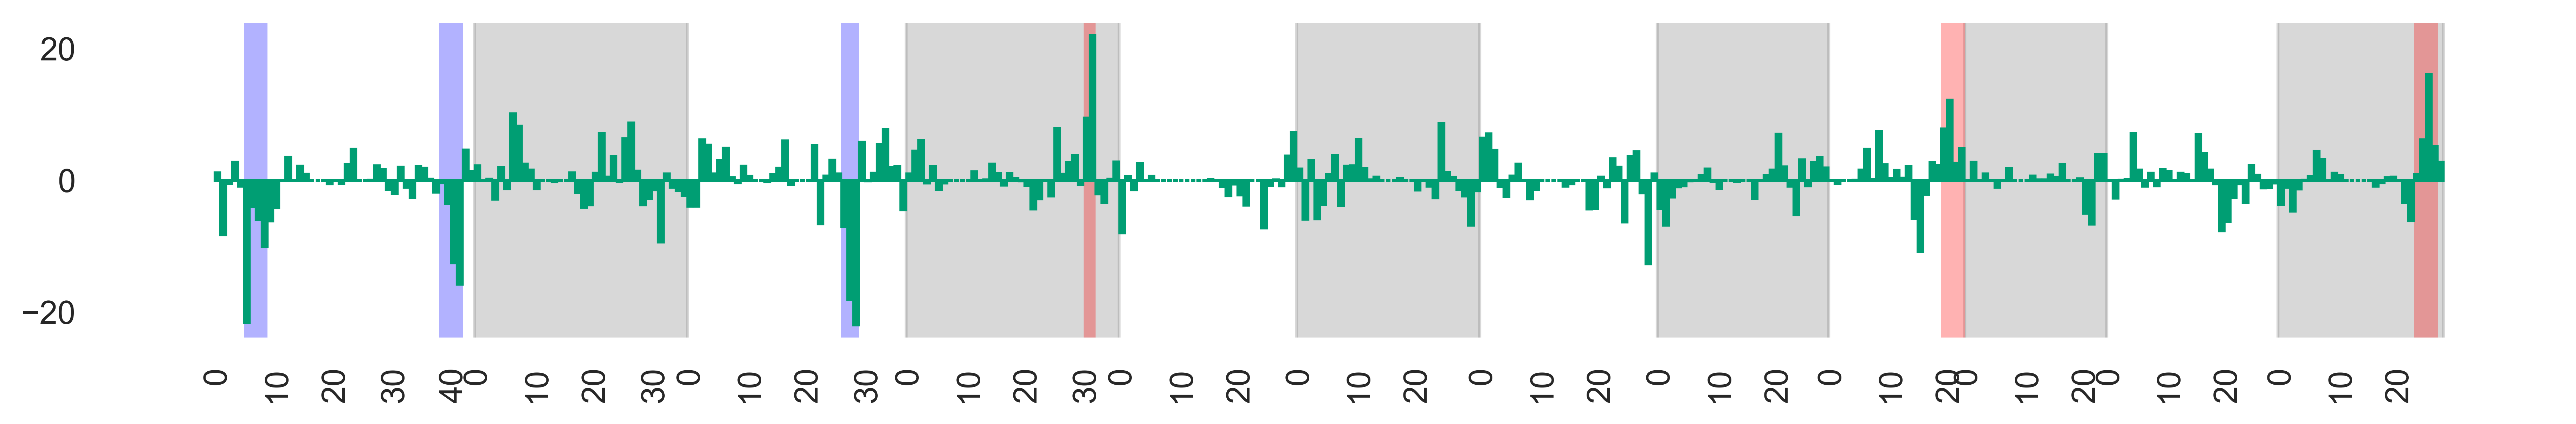

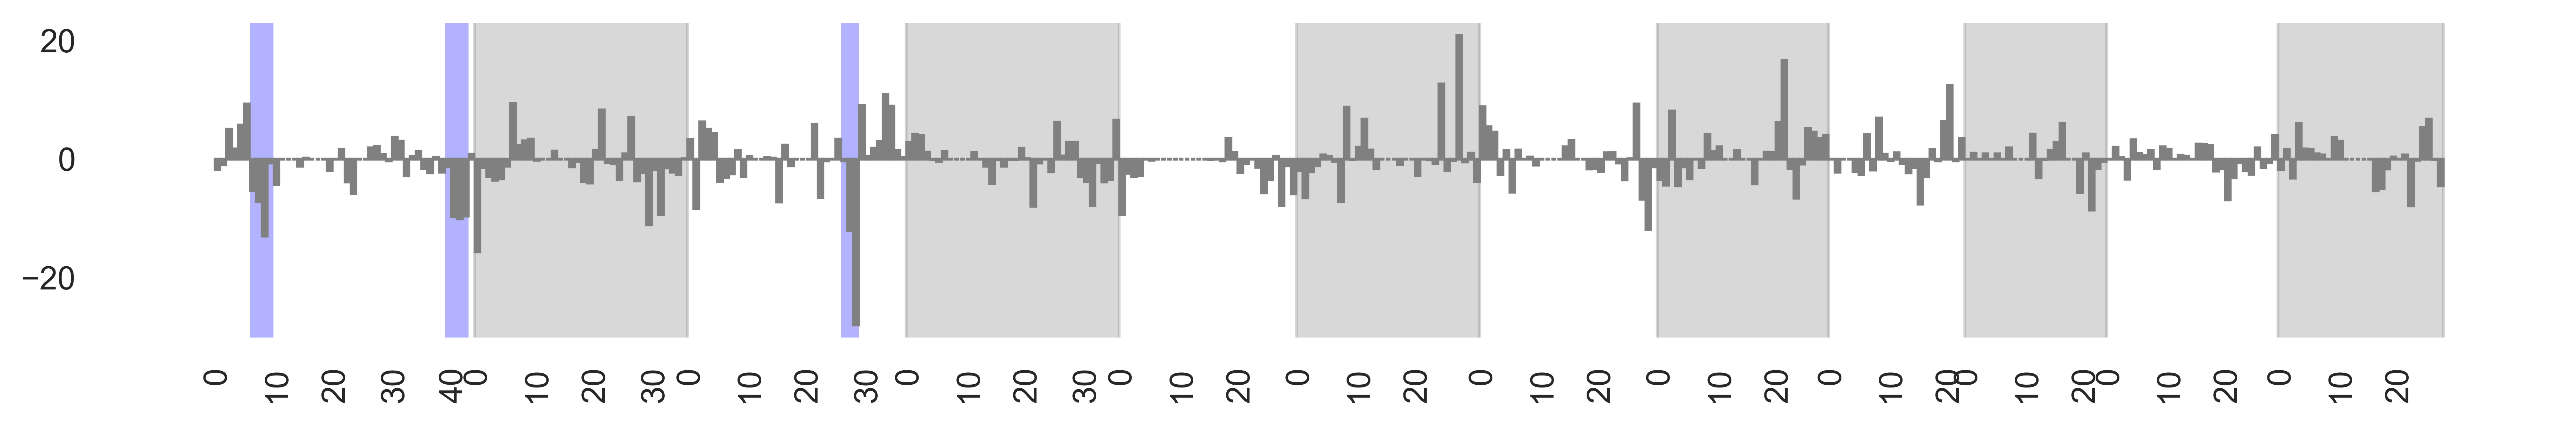

N19


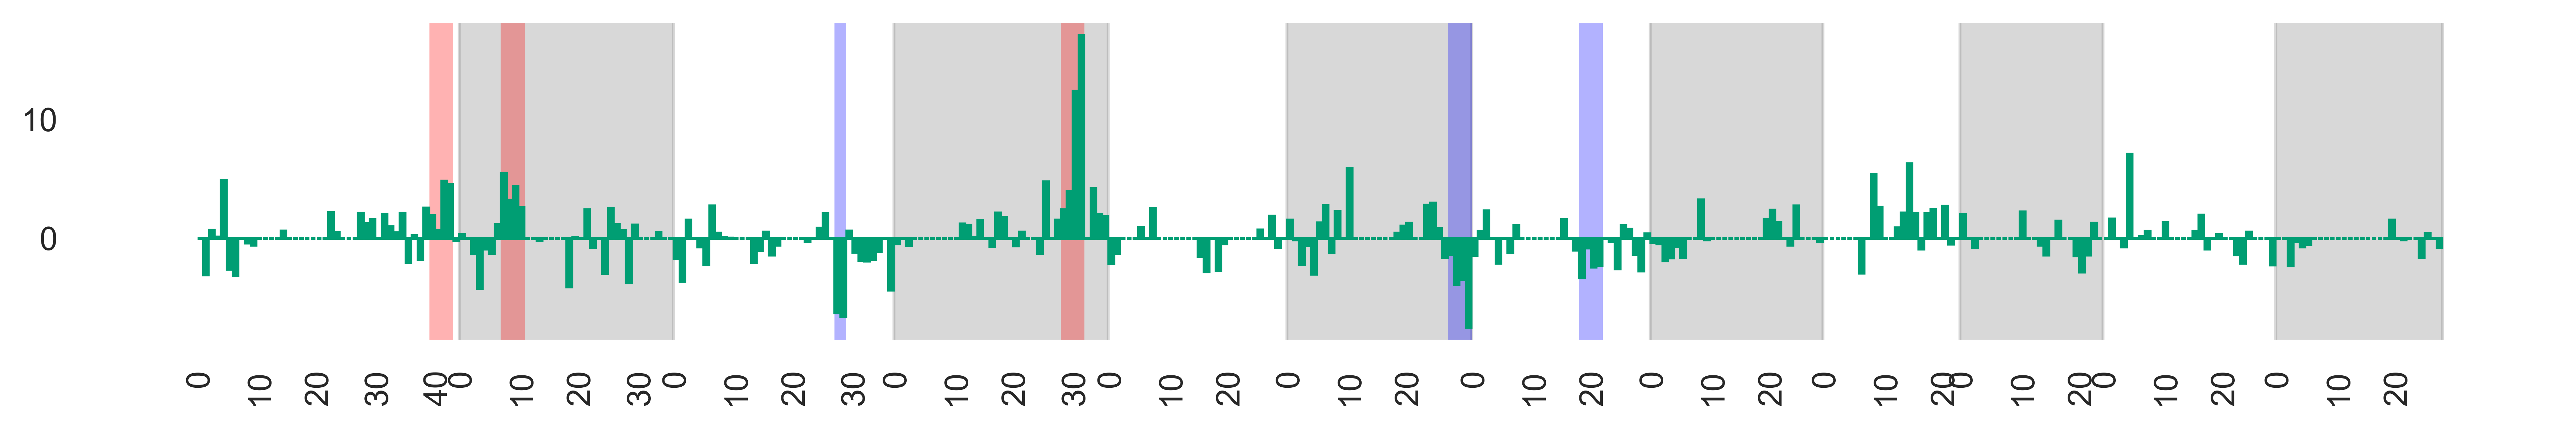

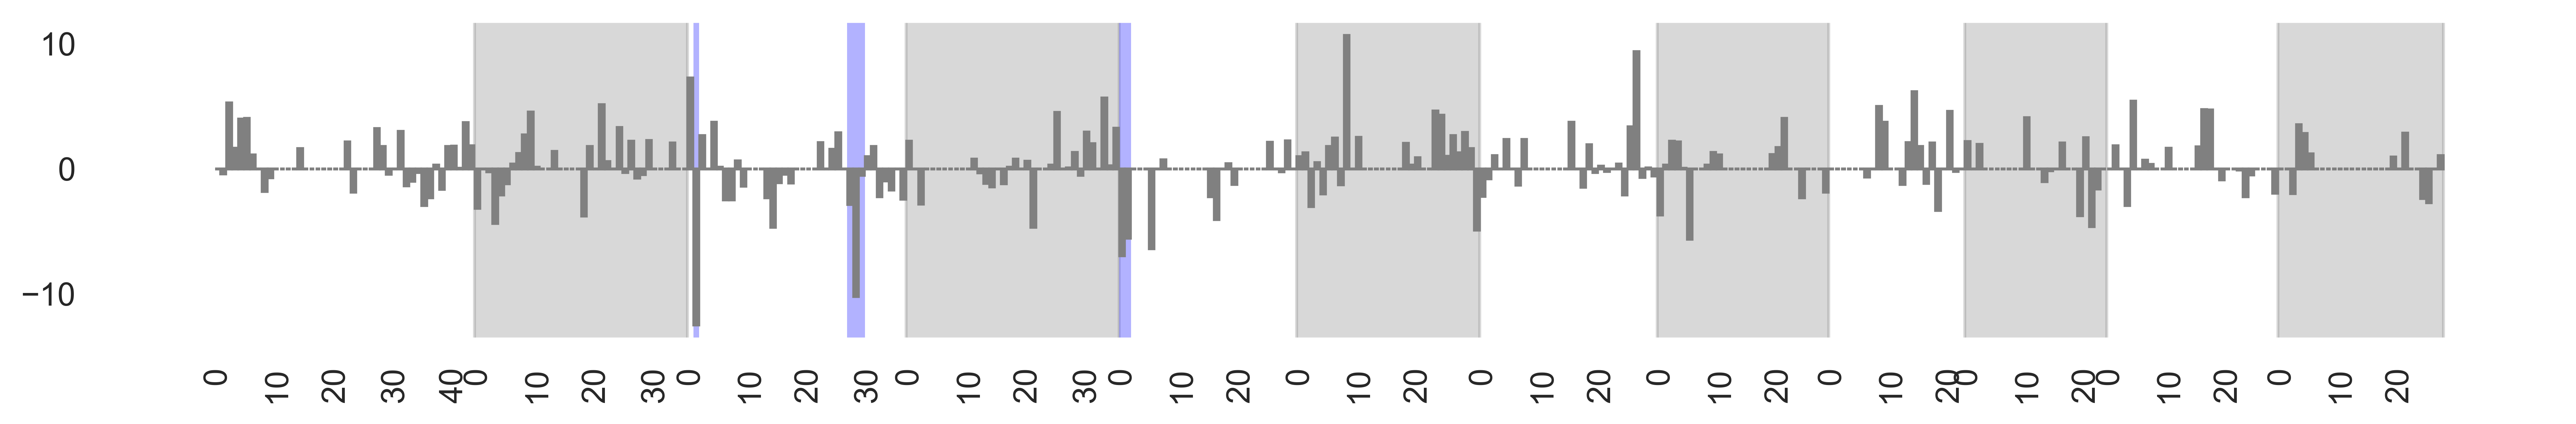

N20


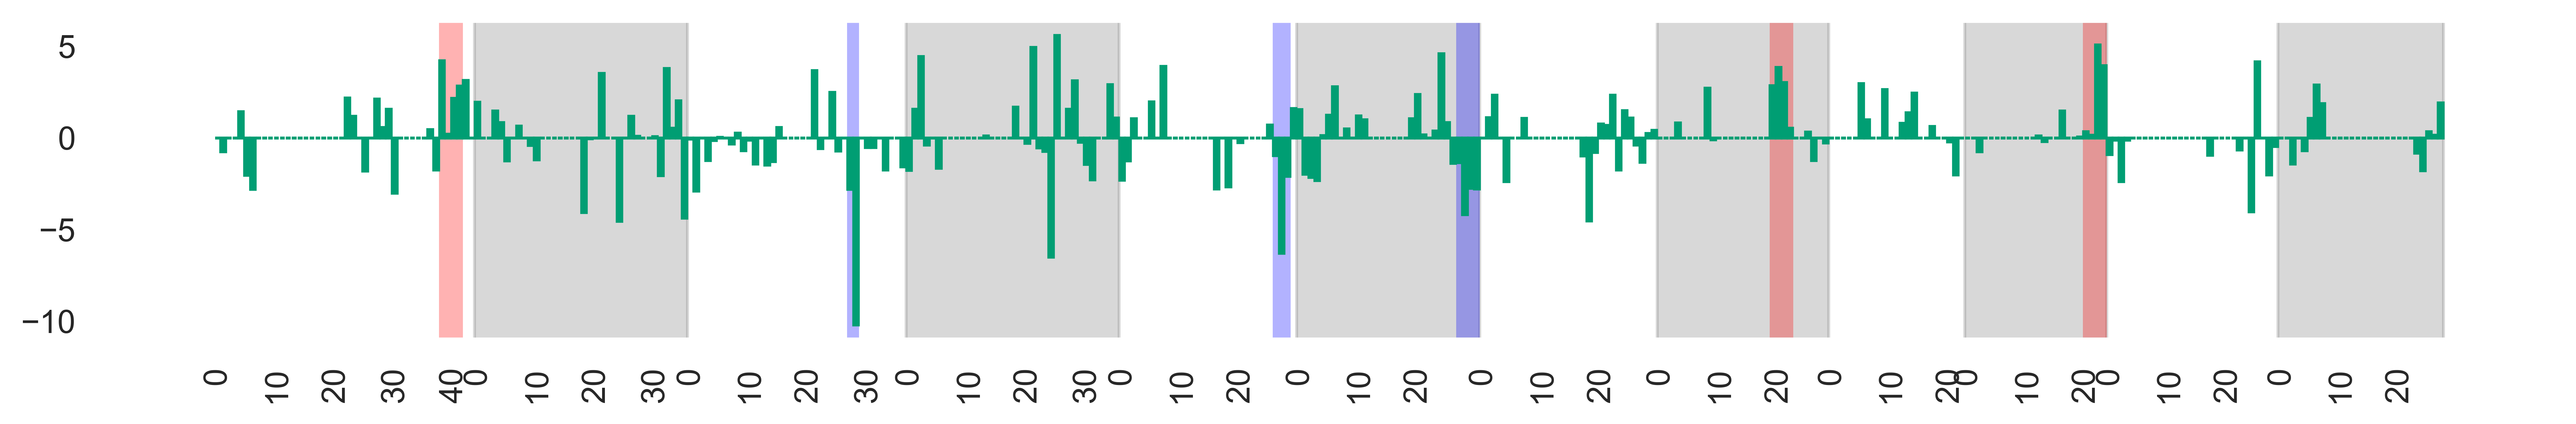

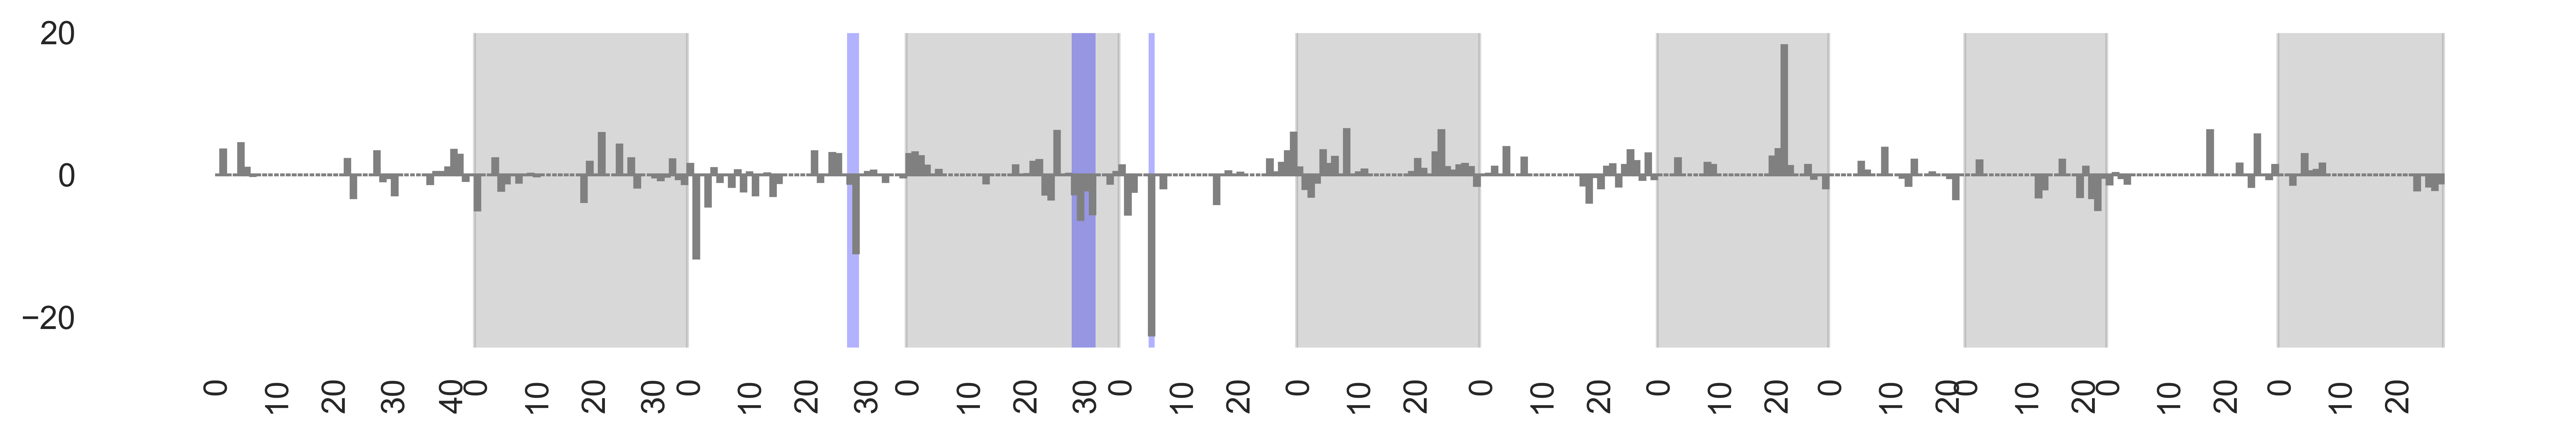

N21


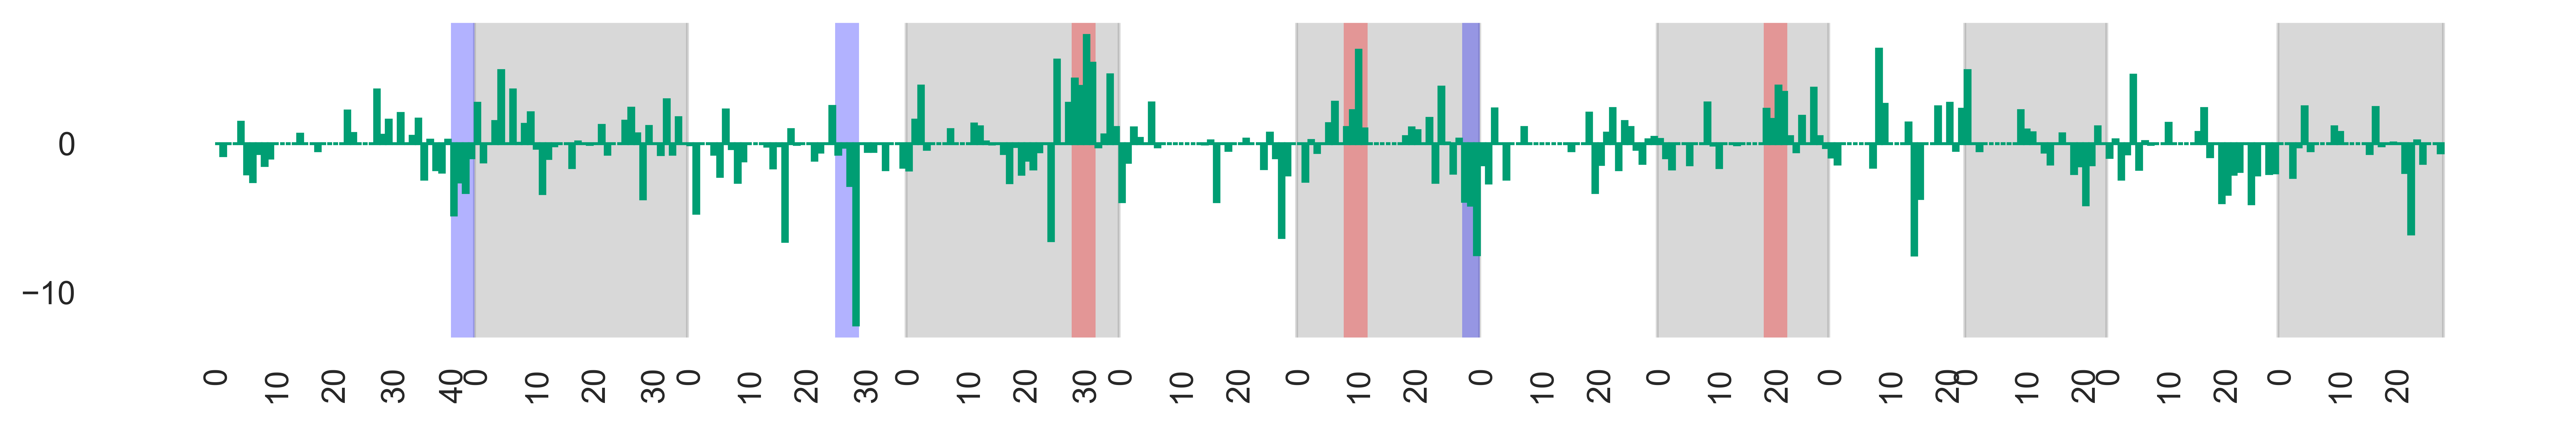

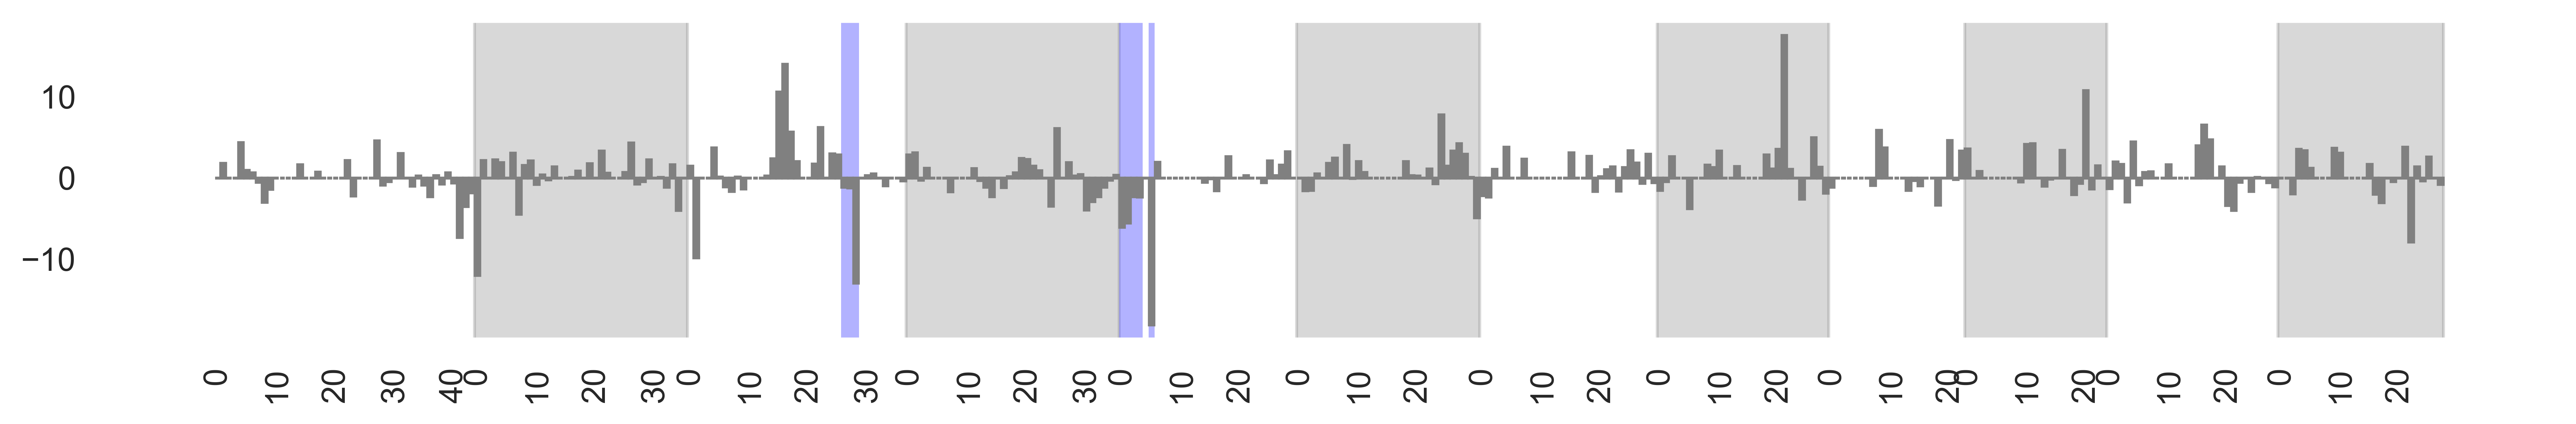

N22


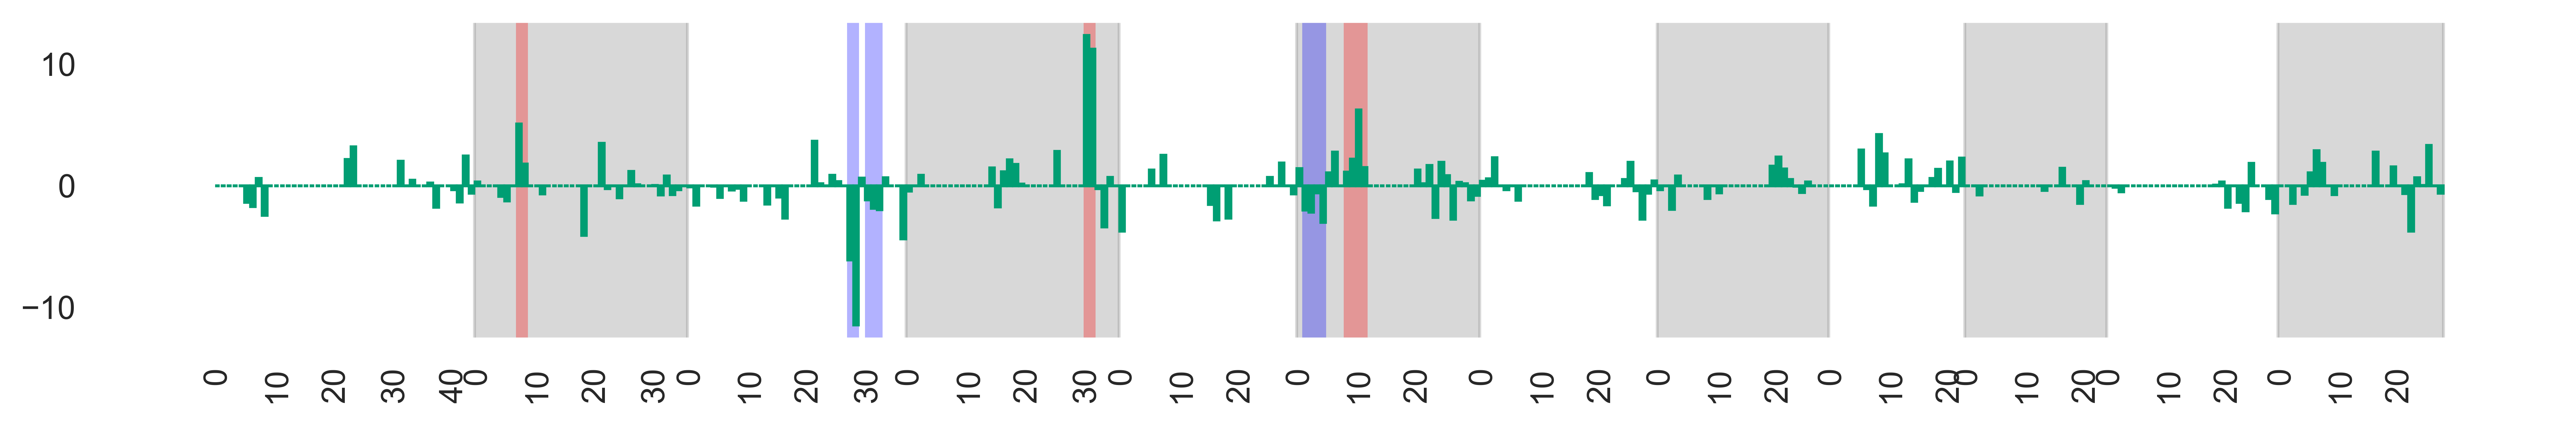

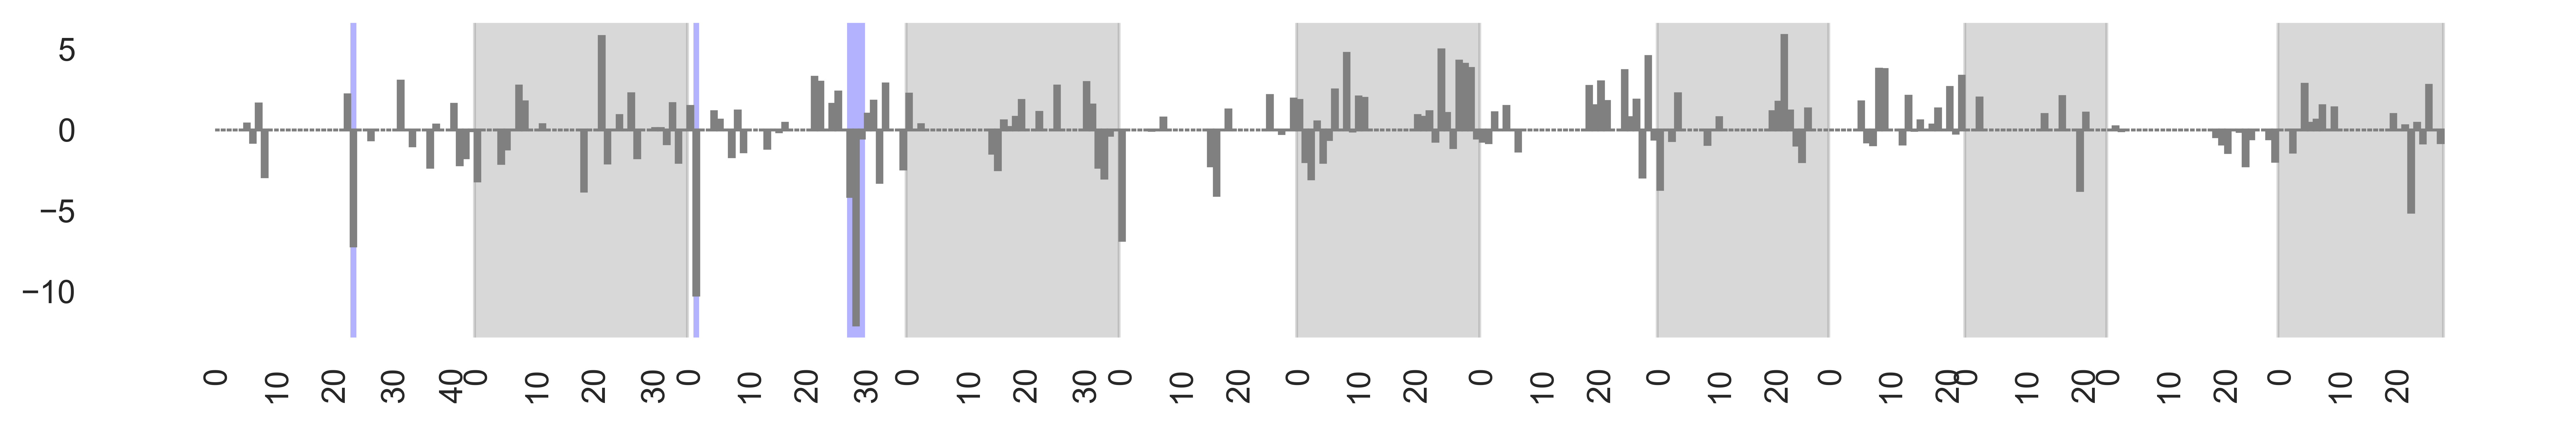

,RIL,PN_plus,PN_plus_regions,PN_plus_region_ratios,PN_minus,PN_minus_region_ratios,PN_merge,zscore_minus,zscore_minus_ratios,Hitome_per,PN_top_regions,PN_worst_regions,Total_worst_regions
157,N01_160,132.278193,3,"0.234, 1.0, 1.0",0.000000,"0, 0, 0",132.278193,-43.757086,"0, 0.667, 0",0.665381,"chr04_28-32Mbp,chr02_6-10Mbp,chr12_23-27Mbp","chr03_26-29Mbp,chr01_5-9Mbp,chr01_39-42Mbp","chr03_26-29Mbp,chr10_19-23Mbp,chr01_6-10Mbp"
10,N08_011,131.923584,2,"1.0, 1.0, 0",0.000000,"0, 0, 0",131.923584,0.000000,"0, 0, 0",0.685533,"chr04_28-32Mbp,chr12_23-27Mbp,chr02_6-10Mbp","chr03_26-29Mbp,chr01_5-9Mbp,chr01_39-42Mbp","chr03_26-29Mbp,chr01_39-43Mbp,chr05_5-8Mbp"
13,N05_014,103.661636,2,"0.697, 1.0, 0",0.000000,"0, 0, 0",103.661636,-11.310759,"0, 0, 0.346",0.665376,"chr12_23-27Mbp,chr02_6-10Mbp,chr07_0-3Mbp","chr03_26-29Mbp,chr01_39-43Mbp,chr01_5-9Mbp","chr03_26-29Mbp,chr05_5-8Mbp,chr10_19-23Mbp"
226,N18_227,103.453794,3,"0.5, 1.0, 0.25",-1.199692,"0.06, 0, 0",102.254102,3.101775,"0.06, 0, 0",0.669818,"chr04_30-32Mbp,chr12_23-27Mbp,chr09_19-23Mbp","chr03_26-29Mbp,chr01_5-9Mbp,chr01_38-42Mbp","chr03_26-29Mbp,chr01_39-43Mbp,chr01_6-10Mbp"
75,N04_076,101.194386,3,"0.256, 0.7, 0.556",0.000000,"0, 0, 0",101.194386,0.000000,"0, 0, 0",0.714318,"chr04_28-32Mbp,chr12_23-27Mbp,chr02_6-10Mbp","chr03_26-29Mbp,chr01_38-42Mbp,chr01_5-9Mbp","chr03_26-29Mbp,chr05_5-7Mbp,chr01_38-42Mbp"


In [4]:
genotype_path = "../data/PART7_Select_useful_RILs/Haplotype_high_imp_HBs_for_3traits.csv"
Hitome_per_path = "../data/PART0_NAM_stats/Percentage_Hitomebore_genotype.csv"

PN_top_regions_effect_summary = pd.DataFrame()
for pop in [i[:3] for i in family]:
    print(pop)
    
    # merge genetic effect within 1Mbp region
    regional_info_all = make_regional_info(imp_data, 1000000, "../data/PART7_Select_useful_RILs/Haplotype_high_imp_HBs_for_3traits.csv", pop)
    
    # get top3 beneficial regions, detrimental regions
    PN_top_regions = get_top_regions(regional_info_all, "PN_imps", "top", 3)
    PN_worst_regions = get_top_regions(regional_info_all, "PN_imps", "worst", 3)
    Total_worst_regions = get_top_regions(regional_info_all, "sum_zscore", "worst", 3)
    
    # visualize genetic effect
    plot_regional_info_with_target(regional_info_all, "PN_imps", "#009E73", PN_top_regions, PN_worst_regions)
    plot_regional_info_with_target(regional_info_all, "sum_zscore", "gray", [], Total_worst_regions)
    
    # get stats
    each_effect_summary = target_effect_summary(imp_data, genotype_path, Hitome_per_path, pop, "PN", PN_top_regions, PN_worst_regions, Total_worst_regions)
    each_effect_summary["PN_top_regions"] = ",".join([f"{i[0]}_{i[1]//1000000}-{i[2]//1000000}Mbp" for i in PN_top_regions])
    each_effect_summary["PN_worst_regions"] = ",".join([f"{i[0]}_{i[1]//1000000}-{i[2]//1000000}Mbp" for i in PN_worst_regions])
    each_effect_summary["Total_worst_regions"] = ",".join([f"{i[0]}_{i[1]//1000000}-{i[2]//1000000}Mbp" for i in Total_worst_regions])
    PN_top_regions_effect_summary = pd.concat([PN_top_regions_effect_summary, each_effect_summary])

PN_top_regions_effect_summary.to_csv("../data/PART7_Select_useful_RILs/Select_RILs_for_PN_stats.csv")
# show the candidate RILs for breeding material
display(PN_top_regions_effect_summary[PN_top_regions_effect_summary.Hitome_per > 0.65].sort_values(by="PN_merge", ascending=False).iloc[:5, :])